# Tennis Court Tracking — ball trajectory, court zones, and bounce lighting

**What this notebook does, end to end**

1. Reads `data/clip.mp4` (you supply it — the download step is disabled).
2. **Finds the court** from its painted lines using classical computer vision — no
   colour assumptions, no trained model.
3. **Detects and tracks the ball** with YOLO + a Kalman filter, smoothed with an
   RTS (forward–backward) pass.
4. **Detects where the ball touches the court** and lights up that zone.
5. Draws a light main-view trajectory trail and a landing-only top-down minimap.

**How the code is organised** — each step below is one or two cells, in this order:

| Step | Cell does |
|---|---|
| 1 | Paths, clip properties, and the scale factors every threshold is derived from |
| 2 | Load the two YOLO models (ball, and people for occlusion) |
| 3 | Court detection (the classical-CV part) + one-time calibration |
| 4 | Court zones, colours, and camera position |
| 5 | The minimap renderer |
| 6 | Pass A — one YOLO inference per frame (cached to disk) |
| 7 | Post-processing — tracking, bounces, ball height |
| 8 | Pass B — draw and encode the video |
| 9 | Result |

## Step 1 — The clip, and the scale factors everything derives from

The download step is **disabled** — this uses the `data/clip.mp4` you provide.

**Why the scale factors matter.** Every threshold in this notebook was originally tuned
on 640×360 @ 25fps footage. Feed it the 1920×1080 @ 30fps production target and all of them are wrong: a
"ball moved 90 pixels" gate, a "15 frame" window, an "8 pixel" search band. So instead
of hard-coding numbers, everything is expressed relative to two factors measured from
the clip itself:

- `SPATIAL`  = width / 640  → scales anything measured in **pixels**
- `TEMPORAL` = fps / 25     → scales anything measured in **frames**

A speed (pixels *per frame*) scales by `SPATIAL / TEMPORAL`. This means swapping the
clip cannot silently mistune the pipeline.

In [1]:
import json
import os
import pickle
import shutil
import subprocess
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment, minimize
from scipy.io import wavfile
from scipy.signal import find_peaks, savgol_filter, stft
from scipy.spatial import cKDTree
import torch
from ultralytics import YOLO
from bounce_sequence import train_open_classifier, bounce_probabilities
from temporal_world_tracker import track_ball_persistent, refine_touchdown_subframe
from landing_detector import estimate_landing_subframe
from landing_event_detector import (detect_landing_impulses,
                                    enforce_one_landing_between_hits,
                                    score_landing_impulse)
from contact_hypothesis import classify_contact_hypotheses
from court_calibration import (automatic_calibration_confidence,
                               validate_manual_calibration)
from tracking.trail_rendering import contact_bounded_start, stabilize_screen_trail

# ── project paths ────────────────────────────────────────────────────────────
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
OUTPUT_DIR = DATA_DIR / "outputs"
CACHE_DIR = DATA_DIR / "cache"
for d in (DATA_DIR, MODELS_DIR, OUTPUT_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

CLIP_PATH = DATA_DIR / "clip.mp4"          # <- you supply this file
OUTPUT_VIDEO = OUTPUT_DIR / "annotated_clip.mp4"

# ── ffmpeg / ffprobe ─────────────────────────────────────────────────────────
# A Jupyter kernel started from a GUI app does not read your shell profile, so
# Homebrew's directory is missing from PATH and these look "not installed" even though
# they work in a terminal. Repair PATH, then resolve both to absolute paths.
for _dir in ("/opt/homebrew/bin", "/usr/local/bin"):
    if os.path.isdir(_dir) and _dir not in os.environ.get("PATH", "").split(os.pathsep):
        os.environ["PATH"] = _dir + os.pathsep + os.environ.get("PATH", "")
FFMPEG, FFPROBE = shutil.which("ffmpeg"), shutil.which("ffprobe")
if not FFMPEG or not FFPROBE:
    raise RuntimeError("ffmpeg/ffprobe not found. `brew install ffmpeg`, then restart the kernel.")

if not CLIP_PATH.exists():
    raise FileNotFoundError(f"Put your video at {CLIP_PATH}")

# ── read the clip's real properties; everything below is derived from these ──
cap = cv2.VideoCapture(str(CLIP_PATH))
FPS = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
if not np.isfinite(FPS) or FPS <= 0:
    raise ValueError(f"Video has no valid native frame rate; got {FPS!r}fps.")

SPATIAL = W / 640.0        # multiply any PIXEL threshold by this
TEMPORAL = FPS / 25.0      # multiply any FRAME-COUNT threshold by this
SPEED = SPATIAL / TEMPORAL  # multiply any PIXELS-PER-FRAME threshold by this


def px(v):
    """A distance in pixels, tuned at 640px wide."""
    return max(1, int(round(v * SPATIAL)))


def nframes(v):
    """A duration in frames, tuned at 25fps."""
    return max(1, int(round(v * TEMPORAL)))


def speed(v):
    """A speed in pixels per frame, tuned at 640px/25fps."""
    return v * SPEED


print(f"clip      : {CLIP_PATH.name}  {W}x{H} @ {FPS:.2f}fps")
print(f"scaling   : SPATIAL={SPATIAL:.2f}x  TEMPORAL={TEMPORAL:.2f}x  SPEED={SPEED:.2f}x")
print(f"e.g.      : an 8px search band -> {px(8)}px;  a 15-frame window -> {nframes(15)} frames")

clip      : clip.mp4  1920x1080 @ 59.94fps
scaling   : SPATIAL=3.00x  TEMPORAL=2.40x  SPEED=1.25x
e.g.      : an 8px search band -> 24px;  a 15-frame window -> 36 frames


## Step 2 — The models

A YOLO11 model fine-tuned on tennis
([`Davidsv/CourtSide-Computer-Vision-v1`](https://huggingface.co/Davidsv/CourtSide-Computer-Vision-v1)).
Only its `tennis_ball` class is used. Its court-zone classes were tested and produce
**zero** detections on this kind of footage even at `conf=0.001`, which is why the court
is found with classical CV in Step 3 instead.

A second small model, `yolo11n-seg`, segments people. It plays no part in the analysis —
it exists so the court lines can be drawn **behind** the players.

In [2]:
# RacketVision MS-TrackNetV3 is the production ball detector. The immutable public
# checkpoint is verified by pipeline_runner before this notebook starts.
RV_MODEL_PATH = MODELS_DIR / "racketvision_balltrack_state_v1.pt"

# Apple Silicon GPU if available, else CPU — never hard-code one
device = ("cuda" if torch.cuda.is_available() else
          "mps" if torch.backends.mps.is_available() else "cpu")

# A second, small model: person SEGMENTATION. It is used purely for drawing — the court
# lines are composited only where there is no player, so players appear in front of the
# lines instead of having them painted across their bodies. A detection model cannot do
# this: a bounding box would punch a rectangular hole in the lines.
SEG_MODEL_PATH = MODELS_DIR / "yolo11n-seg.pt"
seg_model = YOLO(str(SEG_MODEL_PATH) if SEG_MODEL_PATH.exists() else "yolo11n-seg.pt")
if not SEG_MODEL_PATH.exists():                 # ultralytics downloads to CWD
    got = Path("yolo11n-seg.pt")
    if got.exists():
        got.rename(SEG_MODEL_PATH)
    seg_model = YOLO(str(SEG_MODEL_PATH))
PERSON_CLS = [k for k, v in seg_model.names.items() if v == "person"][0]

print(f"device={device}   ball=RacketVision MS-TrackNetV3   person class id={PERSON_CLS}")

device=mps   ball class id=1   person class id=0


## Step 3 — Finding the court with computer vision

This is the part that locates the court. It uses **only** image processing and the
court's known geometry — no colour assumption and no trained model. Each design choice
below exists because the simpler version was tried and measurably failed on this
footage:

| Simpler idea | Why it fails here |
|---|---|
| Threshold the blue court surface | The surround apron is teal too — the mask covers 70–90% of the frame |
| Threshold bright white pixels | The far half of the court is in shadow; its lines are never found |
| Take the outermost detected lines | Grabs the advertising boards above the court as the "far baseline" |
| Score a court template against the paint | Prefers the near **half** court (baseline→net), which also fits |
| Use the net as a reference line | The net tape sits ~1.07m **above** the ground, so it does not project like a court line |

**What actually works — the cross-ratio.** The four painted cross-court lines (near
baseline, near service, far service, far baseline) always have the *same* cross-ratio
under any camera view, because the cross-ratio is a projective invariant. For a tennis
court that number is **1.0989**; for the down-court lines it is **1.1665**. Searching
for the set of detected lines with that signature identifies them regardless of camera,
venue, or court colour. A photometric score then breaks any remaining ties.

The pipeline in this cell:

1. `line_ridge_mask` — find line pixels by **local contrast** (brighter than the surface
   to either side), which survives shadow.
2. `cv2.HoughLinesP` — turn those pixels into straight segments.
3. `_cluster` — merge collinear segments into one line each.
4. `_cr_candidates` — keep line sets whose cross-ratio matches a real court.
5. Score each candidate by how much of the full court template lands on real line pixels.
6. `refine_corners` — sub-pixel polish, used per frame afterwards.

In [3]:
# ── ITF court dimensions, in metres. Everything geometric derives from these. ──
DW, DL = 10.97, 23.77       # doubles width, full length
SI, SD = 1.37, 6.40         # singles inset from the doubles line; service line from net
NET_Y = DL / 2
NET_H_CENTRE, NET_H_POST = 0.914, 1.07   # the net sags in the middle

# World positions of the four painted lines ACROSS the court (near -> far) and the four
# main lines running DOWN the court (left -> right). Their cross-ratios are the
# fingerprint used to recognise a tennis court in any camera view.
H_WORLD = (0.0, NET_Y - SD, NET_Y + SD, DL)     # baselines + service lines
V_WORLD = (0.0, SI, DW / 2, DW)                 # doubles-L, singles-L, centre, doubles-R


def cross_ratio(a, b, c, d):
    """Projective invariant of 4 collinear points — unchanged by any camera view."""
    denominator = (c - b) * (d - a)
    return np.inf if abs(denominator) < 1e-12 else ((c - a) * (d - b)) / denominator


H_CR = cross_ratio(*H_WORLD)   # 1.0989 for every tennis court, always
V_CR = cross_ratio(*V_WORLD)   # 1.1665


def line_ridge_mask(gray, d, t=14):
    """Mark court-line pixels: a line is a bright RIDGE, brighter than the surface `d`
    pixels to either side. Contrast-based, not brightness-based, so lines in the
    shadowed far half of the court are still found."""
    g = gray.astype(np.int16)
    horiz = (g - np.roll(g, d, 0) > t) & (g - np.roll(g, -d, 0) > t)   # a horizontal line
    vert = (g - np.roll(g, d, 1) > t) & (g - np.roll(g, -d, 1) > t)    # a vertical line
    m = ((horiz | vert) * 255).astype(np.uint8)
    return cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))


# ── small geometry helpers: lines are (a, b, c) with a*x + b*y + c = 0 ──
def seg_to_line(x1, y1, x2, y2):
    a, b = y2 - y1, x1 - x2
    n = np.hypot(a, b)
    return None if n < 1e-9 else (a / n, b / n, -((a / n) * x1 + (b / n) * y1))


def x_at(L, y):
    a, b, c = L
    return None if abs(a) < 1e-9 else -(b * y + c) / a


def y_at(L, x):
    a, b, c = L
    return None if abs(b) < 1e-9 else -(a * x + c) / b


def intersect(l1, l2):
    """Where two lines cross, or None if they are nearly parallel.

    The parallel guard is essential: without it two almost-collinear fitted edges
    produce an intersection tens of thousands of pixels off screen, which silently
    destroys the homography."""
    a1, b1, c1 = l1
    a2, b2, c2 = l2
    den = a1 * b2 - a2 * b1
    if abs(den) < 1e-9:
        return None
    return np.array([(b1 * c2 - b2 * c1) / den, (c1 * a2 - c2 * a1) / den])


def cluster_lines(segs, shape, kind, min_weight):
    """Many Hough segments lie on the SAME court line. Merge them into one line each,
    averaging weighted by segment length."""
    h, w = shape[:2]
    items = []
    for x1, y1, x2, y2 in segs:
        L = seg_to_line(x1, y1, x2, y2)
        if L is None:
            continue
        # Hough endpoints have arbitrary direction. Align normal signs before
        # averaging, otherwise equal lines with opposite signs cancel to (0, 0, 0).
        if (kind == "steep" and L[0] < 0) or (kind == "horiz" and L[1] < 0):
            L = tuple(-v for v in L)
        # A line's "position": where it crosses the middle of the frame. Segments of the
        # same court line share this value; different lines do not.
        key = x_at(L, h / 2) if kind == "steep" else y_at(L, w / 2)
        if key is None or not np.isfinite(key):
            continue
        items.append((key, float(np.hypot(x2 - x1, y2 - y1)), L))
    if not items:
        return []
    items.sort(key=lambda t: t[0])
    tol = (w if kind == "steep" else h) * 0.012
    groups = [[items[0]]]
    for it in items[1:]:
        if it[0] - groups[-1][-1][0] <= tol:
            groups[-1].append(it)      # same line as the previous segment
        else:
            groups.append([it])        # a new distinct line
    out = []
    for g in groups:
        wt = sum(t[1] for t in g)
        if wt < min_weight:            # too little evidence to trust
            continue
        a = sum(t[2][0] * t[1] for t in g) / wt
        b = sum(t[2][1] * t[1] for t in g) / wt
        c = sum(t[2][2] * t[1] for t in g) / wt
        n = np.hypot(a, b)
        out.append({"line": (a / n, b / n, c / n),
                    "key": float(np.mean([t[0] for t in g])), "w": wt})
    return out


def cr_candidates(clusters, target_cr, descending, tol=0.05, max_out=12):
    """Every set of 4 lines whose cross-ratio matches a real court, best match first.

    Necessary but not sufficient: unrelated sets sometimes match by chance, so the
    caller disambiguates with the photometric score below."""
    from itertools import combinations
    if len(clusters) < 4:
        return []
    order = sorted(clusters, key=lambda c: -c["key"] if descending else c["key"])
    out = []
    for combo in combinations(range(len(order)), 4):
        keys = [order[i]["key"] for i in combo]
        try:
            cr = cross_ratio(*keys)
        except ZeroDivisionError:
            continue
        err = abs(cr - target_cr) / target_cr
        if err <= tol:
            out.append((err, [order[i] for i in combo]))
    out.sort(key=lambda t: t[0])
    return out[:max_out]


# All nine painted lines of a tennis court, as world-coordinate endpoints. Used both to
# score a candidate court and to draw the overlay.
COURT_TEMPLATE = [
    ((0, 0), (DW, 0)), ((0, DL), (DW, DL)),                      # baselines
    ((0, 0), (0, DL)), ((DW, 0), (DW, DL)),                      # doubles sidelines
    ((SI, 0), (SI, DL)), ((DW - SI, 0), (DW - SI, DL)),          # singles sidelines
    ((SI, NET_Y - SD), (DW - SI, NET_Y - SD)),                   # near service line
    ((SI, NET_Y + SD), (DW - SI, NET_Y + SD)),                   # far service line
    ((DW / 2, NET_Y - SD), (DW / 2, NET_Y + SD)),                # centre service line
]


# The points where the painted lines cross. Known in metres like everything else, so
# they need no detection of their own — they are marked on screen as dots.
COURT_CROSSINGS = (
    [(0, 0), (DW, 0), (0, DL), (DW, DL)]                       # outer corners
    + [(SI, 0), (DW - SI, 0), (SI, DL), (DW - SI, DL)]         # singles lines at the baselines
    + [(SI, NET_Y - SD), (DW - SI, NET_Y - SD),                # service lines at the singles lines
       (SI, NET_Y + SD), (DW - SI, NET_Y + SD)]
    + [(DW / 2, NET_Y - SD), (DW / 2, NET_Y + SD)]             # centre line at the service lines
)


def template_points(M, samples=36):
    """The whole court template projected into the image, as sample points."""
    pts = []
    for p0, p1 in COURT_TEMPLATE:
        t = np.linspace(0, 1, samples)
        pts.append(np.stack([p0[0] + (p1[0] - p0[0]) * t, p0[1] + (p1[1] - p0[1]) * t], 1))
    world = np.concatenate(pts).astype(np.float32).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(world, M).reshape(-1, 2)


WORLD_QUAD = np.array([[0, 0], [DW, 0], [DW, DL], [0, DL]], np.float32)

from court_registration import (
    court_surface_candidate, court_template_score, per_line_coverage, propagate_court_corners,
    select_court_medoid,
    validate_court_corners,
)


def detect_court(frame):
    """Locate the court in one frame. Returns (corners, info); corners are
    near-left, near-right, far-right, far-left in pixels, or None if this frame is not
    a usable wide court shot."""
    h, w = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mask = line_ridge_mask(gray, px(8 / 3))          # 8px at 1920 wide
    segs = cv2.HoughLinesP(mask, 1, np.pi / 360, threshold=px(70 / 3),
                           minLineLength=int(0.06 * w), maxLineGap=int(0.02 * w))
    if segs is None:
        return None, {"reason": "no line segments"}
    segs = segs.reshape(-1, 4)
    angle = (np.degrees(np.arctan2(segs[:, 3] - segs[:, 1], segs[:, 2] - segs[:, 0])) + 180) % 180
    horiz = segs[(angle < 35) | (angle > 145)]       # lines across the court
    steep = segs[(angle >= 35) & (angle <= 145)]     # lines down the court
    info = {"n_horiz": len(horiz), "n_steep": len(steep)}
    # A wide court shot always shows both families. A close-up shows at most one, which
    # makes this a reliable "is the camera showing the court?" test.
    if len(horiz) < 4 or len(steep) < 4:
        return None, {**info, "reason": "not a wide court shot"}

    Hc = cluster_lines(horiz, frame.shape, "horiz", px(200 / 3))
    Vc = cluster_lines(steep, frame.shape, "steep", px(200 / 3))
    info.update(h_keys=[round(c["key"], 1) for c in Hc],
                v_keys=[round(c["key"], 1) for c in Vc])
    if len(Hc) < 4 or len(Vc) < 4:
        return None, {**info, "reason": f"too few distinct lines (h={len(Hc)}, v={len(Vc)})"}

    # Horizontal clutter is much richer than sideline clutter in sports halls; the
    # correct four-line set can rank well below the first dozen cross-ratio matches.
    h_sets = cr_candidates(Hc, H_CR, descending=True, max_out=64)
    v_sets = cr_candidates(Vc, V_CR, descending=False, max_out=20)
    info.update(h_sets=[[round(c["key"], 1) for c in group] for _, group in h_sets],
                v_sets=[[round(c["key"], 1) for c in group] for _, group in v_sets])
    # Do not fail here: the surface proposal below can recover a court when one
    # thin/occluded painted line prevents a complete four-line Hough set.

    mask_d = cv2.dilate(mask, np.ones((5, 5), np.uint8))
    best = None
    best_source = None
    scored_candidates = []
    bottom_cross_line = max(c["key"] for c in Hc if c["key"] <= 1.10 * h)
    for _, hset in h_sets:
        # In a complete elevated behind-baseline view, the near baseline is the
        # bottom-most painted cross-court line. Without this guard the near service
        # line can masquerade as a baseline and register only half of the court.
        if hset[0]["key"] < bottom_cross_line - 0.25 * h:
            continue
        near_bl, far_bl = hset[0]["line"], hset[3]["line"]
        for _, vset in v_sets:
            left, right = vset[0]["line"], vset[3]["line"]
            corners = [intersect(left, near_bl), intersect(right, near_bl),
                       intersect(right, far_bl), intersect(left, far_bl)]
            if any(c is None for c in corners):
                continue
            quad = np.array(corners, np.float32)
            if not np.all(np.isfinite(quad)):
                continue
            geometry = validate_court_corners(quad, frame.shape, world_quad=WORLD_QUAD)
            if not geometry.valid:
                continue
            M = cv2.getPerspectiveTransform(WORLD_QUAD, quad)
            tp = template_points(M)
            xi, yi = np.round(tp[:, 0]).astype(int), np.round(tp[:, 1]).astype(int)
            on_screen = (xi >= 0) & (xi < w) & (yi >= 0) & (yi < h)
            if on_screen.sum() < len(tp) * 0.75:
                continue
            # Every family of painted lines must contribute. A global mean alone can
            # reward a collapsed homography that maps several model lines to one edge.
            line_coverage, visible = per_line_coverage(
                tp, mask_d, n_lines=len(COURT_TEMPLATE))
            if visible < 0.75:
                continue
            line_score = court_template_score(line_coverage)
            # Score paint support only. A generic colour discontinuity is unsafe:
            # the wall/floor seam in an indoor hall can be stronger than the far line.
            score = line_score if w < 1000 else float(np.mean(line_coverage))
            scored_candidates.append((score, quad.astype(float), line_coverage,
                                      [c["key"] for c in hset],
                                      [c["key"] for c in vset]))
            if best is None or score > best[0]:
                best = (score, quad.astype(float), line_coverage)
                best_source = "hough"
    # The far line is often too thin or occluded for Hough. Add one independent
    # proposal from the dominant playing-surface component, then subject it to the
    # same geometry and nine-line paint checks as every Hough proposal.
    surface_quad, surface_info = court_surface_candidate(frame)
    info["surface_candidate"] = surface_info
    if surface_quad is not None:
        geometry = validate_court_corners(surface_quad, frame.shape, world_quad=WORLD_QUAD)
        if geometry.valid:
            M = cv2.getPerspectiveTransform(WORLD_QUAD, surface_quad.astype(np.float32))
            tp = template_points(M)
            line_coverage, visible = per_line_coverage(
                tp, mask_d, n_lines=len(COURT_TEMPLATE))
            if visible >= 0.75:
                score = (court_template_score(line_coverage) if w < 1000
                         else float(np.mean(line_coverage)))
                scored_candidates.append((score, surface_quad.astype(float), line_coverage, [], []))
                if best is None or score > best[0]:
                    best = (score, surface_quad.astype(float), line_coverage)
                    best_source = "surface"
    if best is None:
        return None, {**info, "reason": "no geometrically valid court"}
    score, quad, line_coverage = best
    info["top_candidates"] = [
        {"score": round(float(s), 3), "quad": np.round(q, 1).tolist(),
         "hset": np.round(hk, 1).tolist(), "vset": np.round(vk, 1).tolist(),
         "line_coverage": np.round(lc, 2).tolist()}
        for s, q, lc, hk, vk in sorted(scored_candidates, key=lambda z: z[0], reverse=True)[:5]
    ]
    weak_low_res = w < 1000 and (score < 0.20 or np.quantile(line_coverage, 0.25) < 0.08)
    weak_hd = w >= 1000 and score < (0.10 if best_source == "surface" else 0.50)
    if weak_low_res or weak_hd:
        return None, {**info, "reason": f"balanced template score {score:.2f} too low",
                            "best_quad": np.round(quad, 1).tolist(),
                            "line_coverage": np.round(line_coverage, 2).tolist()}
    return quad, {**info, "coverage": float(np.mean(line_coverage)),
                          "balanced_score": score, "source": best_source,
                          "line_coverage": line_coverage.tolist()}


def refine_corners(frame, seed, band, ridge=None):
    """Sub-pixel polish: re-fit each of the 4 court edges to the line pixels in a thin
    band around where `seed` says the edge is, then re-intersect.

    Returns (corners, match_score). The score is the fraction of the full court template
    that lands on real line pixels, and it is what tells a genuine court shot from a
    close-up: measured on this clip, court frames score 0.48-0.99 while close-ups score
    0.00-0.23. Corner positions alone cannot tell them apart — a close-up sometimes
    produces a fit within 23px of the calibration purely by chance.

    `seed` must be a FIXED reference (the calibration corners), never the previous
    frame's own output — feeding results forward lets the bands walk off the real lines
    and diverge (measured: corner jumps of tens of thousands of pixels)."""
    near_l, near_r, far_r, far_l = seed
    h, w = frame.shape[:2]
    if ridge is None:
        ridge = line_ridge_mask(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), px(8 / 3))
    edges = {"near": (near_l, near_r), "far": (far_l, far_r),
             "left": (near_l, far_l), "right": (near_r, far_r)}
    fitted = {}
    for name, (p0, p1) in edges.items():
        strip = np.zeros((h, w), np.uint8)
        cv2.line(strip, tuple(np.asarray(p0).astype(int)), tuple(np.asarray(p1).astype(int)), 255, band)
        ys, xs = np.where(cv2.bitwise_and(ridge, strip) > 0)
        if len(xs) < px(20):
            return None, 0.0
        # Huber loss so a few stray pixels (a player's shoe, a shadow) can't tilt the fit
        vx, vy, x0, y0 = cv2.fitLine(np.column_stack([xs, ys]).astype(np.float32),
                                     cv2.DIST_HUBER, 0, 0.01, 0.01).flatten()
        n = np.hypot(vy, -vx)
        fitted[name] = (vy / n, -vx / n, -((vy / n) * x0 + (-vx / n) * y0))
    corners = [intersect(fitted["left"], fitted["near"]), intersect(fitted["right"], fitted["near"]),
               intersect(fitted["right"], fitted["far"]), intersect(fitted["left"], fitted["far"])]
    if any(c is None for c in corners):
        return None, 0.0
    quad = np.array(corners)
    if not np.all(np.isfinite(quad)):
        return None, 0.0
    if not validate_court_corners(quad, frame.shape, world_quad=WORLD_QUAD).valid:
        return None, 0.0

    # how much of the whole court template actually lands on line pixels?
    M = cv2.getPerspectiveTransform(WORLD_QUAD, quad.astype(np.float32))
    tp = template_points(M)
    xi, yi = np.round(tp[:, 0]).astype(int), np.round(tp[:, 1]).astype(int)
    on = (xi >= 0) & (xi < w) & (yi >= 0) & (yi < h)
    if on.sum() < len(tp) * 0.6:
        return quad, 0.0
    ridge_d = cv2.dilate(ridge, np.ones((5, 5), np.uint8))
    return quad, float((ridge_d[yi[on], xi[on]] > 0).mean())


# ── the court, re-detected on every frame ────────────────────────────────────
# Sample points along the nine template lines. Everything below — the per-frame fit,
# the "is there paint here?" test and the drawing — uses this one sampling, so a stored
# per-frame mask lines up with what Pass B redraws.
LINE_SAMPLES = 48


def _template_samples(n):
    out = []
    for p0, p1 in COURT_TEMPLATE:
        t = np.linspace(0, 1, n)
        out.append(np.stack([p0[0] + (p1[0] - p0[0]) * t,
                             p0[1] + (p1[1] - p0[1]) * t], 1))
    return np.concatenate(out).astype(np.float32).reshape(-1, 1, 2)


DRAW_WORLD = _template_samples(LINE_SAMPLES)     # 9 * LINE_SAMPLES points, in metres
FIT_WORLD = _template_samples(40)                # a coarser set is enough to fit with
CROSS_WORLD = np.array(COURT_CROSSINGS, np.float32).reshape(-1, 1, 2)


def _crossing_samples():
    """For each crossing, which template lines meet there and which sample along each one
    sits on it. Used so a dot is drawn only where the paint under BOTH lines was really
    found, matching how the lines themselves are drawn."""
    out = []
    for cx_, cy_ in COURT_CROSSINGS:
        hits = []
        for li, (p0, p1) in enumerate(COURT_TEMPLATE):
            d = np.array(p1, float) - np.array(p0, float)
            L2 = float(d @ d)
            t = float((np.array([cx_, cy_], float) - np.array(p0, float)) @ d) / L2
            if not (-1e-6 <= t <= 1 + 1e-6):
                continue
            foot = np.array(p0, float) + t * d
            if np.hypot(*(foot - np.array([cx_, cy_], float))) < 1e-6:
                hits.append((li, int(round(min(max(t, 0.0), 1.0) * (LINE_SAMPLES - 1)))))
        out.append(hits)
    return out


CROSS_LINES = _crossing_samples()


def project_world(points_world, corners):
    M = cv2.getPerspectiveTransform(WORLD_QUAD, np.asarray(corners, np.float32).reshape(4, 2))
    return cv2.perspectiveTransform(points_world, M).reshape(-1, 2)


def sample_field(field, pts):
    """Bilinear lookup of an image-sized float field at arbitrary points."""
    h, w = field.shape[:2]
    xs = np.clip(pts[:, 0], 0, w - 1).astype(np.float32).reshape(-1, 1)
    ys = np.clip(pts[:, 1], 0, h - 1).astype(np.float32).reshape(-1, 1)
    return cv2.remap(field, xs, ys, cv2.INTER_LINEAR).ravel()


def paint_distance_field(gray, ridge=None):
    """Distance from every pixel to the nearest detected line pixel, plus a blurred copy
    that gives an optimiser something to descend."""
    r = ridge if ridge is not None else line_ridge_mask(gray, px(8 / 3))
    dist = cv2.distanceTransform(255 - r, cv2.DIST_L2, 5)
    return dist, cv2.GaussianBlur(dist, (0, 0), px(2 / 3))


def _fit_cost(dist_smooth, world, shape):
    h, w = shape[:2]
    off, cap = float(px(10)), float(px(4))

    def cost(flat):
        p = project_world(world, np.asarray(flat).reshape(4, 2))
        d = sample_field(dist_smooth, p)
        outside = (p[:, 0] < 0) | (p[:, 0] >= w) | (p[:, 1] < 0) | (p[:, 1] >= h)
        # capped: a stretch of missing or occluded paint must not drag the whole fit
        return float(np.mean(np.minimum(np.where(outside, off, d), cap) ** 2))
    return cost


def fit_court_frame(gray, seeds, ridge=None):
    """Re-detect the court in ONE frame: nudge the four corners until all nine painted
    lines sit on paint. Returns (corners, mean_distance_to_paint_px, paint_found).

    This is what lets the overlay follow a moving camera; it replaces the v7/v8 "lock",
    which only worked because that clip's camera never moved.

    `seeds` is a LIST of starting points — the fixed calibration, and the previous
    frame's accepted fit — and whichever ends up closest to the paint wins. Both are
    needed, and the distinction matters:

      * the calibration alone cannot follow a camera. Measured on a synthetic pan+zoom,
        seeding only from it left the overlay 6.27px off the paint with 609 of 720 frames
        failing; adding the previous fit brought that to 0.40px and 9 frames.
      * propagating the previous fit ALONE is the failure mode v7 recorded (corner jumps
        of tens of thousands of pixels). It is safe here only because it has to win on
        measured distance-to-paint against a seed that never moves, so a diverged
        estimate simply loses.
    """
    dist, dist_smooth = paint_distance_field(gray, ridge)
    cost = _fit_cost(dist_smooth, FIT_WORLD, gray.shape)
    best = None
    for s in seeds:
        if s is None:
            continue
        res = minimize(cost, np.asarray(s, float).ravel(), method="Powell",
                       options={"xtol": 5e-3, "ftol": 1e-3, "maxiter": 4000})
        if best is None or res.fun < best[0]:
            best = (float(res.fun), res.x.reshape(4, 2))
    corners = best[1]
    if not validate_court_corners(corners, gray.shape, world_quad=WORLD_QUAD).valid:
        corners = np.asarray(next(s for s in seeds if s is not None), float).reshape(4, 2)
    d_draw = sample_field(dist, project_world(DRAW_WORLD, corners))
    # per-sample: is there really paint under this point? Pass B strokes only these.
    paint_found = (d_draw <= LINE_PAINT_TOL).reshape(len(COURT_TEMPLATE), LINE_SAMPLES)
    return corners, float(np.mean(np.minimum(d_draw, px(4)))), paint_found


def clean_plate(frames_gray):
    """A temporal median of court frames: the camera is static over the calibration
    sample, so the players and the ball average away and only the painted lines survive.
    Calibrating against this instead of a single frame removes the biggest source of
    noise in the line fit."""
    return np.median(np.stack(frames_gray), axis=0).astype(np.uint8)


def fit_court_globally(plate_gray, seed):
    """The one-off calibration fit: same idea as `fit_court_frame`, but with restarts and
    a denser sampling, run against the clean plate.

    Why fit all NINE lines and not just the outer four: `detect_court` and
    `refine_corners` fit only the court's outer rectangle, so an edge with weak evidence
    is unconstrained and can be badly wrong while the fit still looks self-consistent.
    Measured on this clip, the near-left corner came out 80px from the real corner while
    every other line sat exactly on the paint. The service lines, singles lines and
    centre line are the extra constraints that pin it down: mean distance from the drawn
    template to the real paint dropped from 6.79px to 0.23px.

    Returns (corners, mean_distance_to_paint_px, note)."""
    dist, dist_smooth = paint_distance_field(plate_gray)
    base_cost = _fit_cost(dist_smooth, FIT_WORLD, plate_gray.shape)
    seed = np.asarray(seed, float)

    def cost(flat):
        q = np.asarray(flat, float).reshape(4, 2)
        check = validate_court_corners(q, plate_gray.shape, world_quad=WORLD_QUAD)
        if not check.valid:
            return 1e6
        # A small trust region prevents the capped paint loss from jumping to a
        # different collection of venue lines while still allowing sub-pixel polish.
        trust = np.mean(((q - seed) / max(px(20), 1)) ** 2)
        return base_cost(flat) + 0.02 * float(trust)

    def mean_dist(corners):
        return float(np.mean(sample_field(dist, project_world(DRAW_WORLD, corners))))

    rng = np.random.default_rng(0)
    starts = [seed.ravel()]
    for spread in (px(2), px(6), px(14)):        # restarts in case the seed is far out
        starts += [seed.ravel() + rng.normal(0, spread, 8) for _ in range(3)]
    best = None
    for s in starts:
        r = minimize(cost, s, method="Powell",
                     options={"xtol": 1e-3, "ftol": 1e-4, "maxiter": 20000})
        if best is None or r.fun < best[0]:
            best = (float(r.fun), r.x.reshape(4, 2))

    refined = best[1]
    # Guards: a global fit that wanders is worse than the seed it started from.
    geometry = validate_court_corners(refined, plate_gray.shape, world_quad=WORLD_QUAD)
    if not geometry.valid:
        return seed, mean_dist(seed), "rejected: invalid court geometry (" + ", ".join(geometry.reasons) + ")"
    if np.abs(refined - seed).max() > px(60):
        return seed, mean_dist(seed), "rejected: moved too far from the consensus"
    if mean_dist(refined) > mean_dist(seed):
        return seed, mean_dist(seed), "rejected: no improvement on the consensus"
    return refined, mean_dist(refined), "accepted"


### Calibrating once, then tracking every frame

`detect_court` is run on frames sampled across the clip and the results are combined
into one **consensus** court (a median, so a few bad frames cannot move it). That
consensus is the reference; every frame afterwards is handled by the much cheaper and
much steadier `refine_corners`.

Why not run the full detector on every frame? It was measured: per-frame detection
jumps around by up to ~100px because it occasionally locks onto a different line.
Consensus + refinement is stable to a few pixels.

In [4]:
CORNER_BAND = px(8)              # width of the strip searched around each court edge
CORNER_GRACE = nframes(10)       # keep drawing this long after the last successful fit
PLATE_MAX_FRAMES = 60            # enough for a clean temporal median; more just costs memory

cap = cv2.VideoCapture(str(CLIP_PATH))
all_frames_count = 0
detections = []
plate_frames = []
t0 = time.time()
frame_idx = 0
calibration_preview = None
while True:
    ok, frame = cap.read()
    if not ok:
        break
    if calibration_preview is None:
        calibration_preview = frame.copy()
    if frame_idx % 20 == 0:                     # sampling is enough for a consensus
        quad, _ = detect_court(frame)
        if quad is not None:
            detections.append(quad)
            # keep the frames the court was actually found in; they become the clean plate
            if len(plate_frames) < PLATE_MAX_FRAMES:
                plate_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    frame_idx += 1
    all_frames_count += 1
cap.release()

sampled_count = max(1, (all_frames_count + 19) // 20)
if not detections:
    quality = automatic_calibration_confidence(
        sampled_frames=sampled_count, detected_frames=0, consensus_support=0,
        fit_error_px=np.inf, fit_note="no automatic court")
    if "_pipeline_manual_court_calibration" not in globals():
        raise RuntimeError("自动识别球场失败，需要在网页中确认四个角点。")
    manual = _pipeline_manual_court_calibration(
        calibration_preview, reason="；".join(quality.reasons),
        automatic_confidence=quality.score)
    CALIB_CORNERS = validate_manual_calibration(manual, (H, W), WORLD_QUAD)
    SEED_CORNERS, inliers, plate_frames = CALIB_CORNERS.copy(), np.array([0]), []
    CALIB_ERR_PX, CALIB_NOTE = 0.0, "manual four-corner calibration"
else:
    D = np.array(detections)
# Use an actually observed, temporally supported court. Coordinate-wise medians can
# splice corners from incompatible hypotheses into a quadrilateral never detected.
    SEED_CORNERS, inlier_idx = select_court_medoid(D, (H, W))
    inliers = D[inlier_idx]

# The consensus is only as good as the four outer edges it was built from, so finish
# with a fit against the whole court template on a clean plate. This calibration is
# now the SEED every per-frame fit starts from, and the fallback when one is rejected.
    PLATE = clean_plate(plate_frames)
    CALIB_CORNERS, CALIB_ERR_PX, CALIB_NOTE = fit_court_globally(PLATE, SEED_CORNERS)
    quality = automatic_calibration_confidence(
        sampled_frames=sampled_count, detected_frames=len(detections),
        consensus_support=len(inliers), fit_error_px=CALIB_ERR_PX,
        fit_note=CALIB_NOTE)
    if not quality.automatic:
        if "_pipeline_manual_court_calibration" not in globals():
            raise RuntimeError("自动球场校准置信度不足，需要人工确认四个角点。")
        manual = _pipeline_manual_court_calibration(
            calibration_preview, reason="；".join(quality.reasons),
            automatic_confidence=quality.score)
        CALIB_CORNERS = validate_manual_calibration(manual, (H, W), WORLD_QUAD)
        SEED_CORNERS = CALIB_CORNERS.copy()
        CALIB_ERR_PX, CALIB_NOTE = 0.0, "manual four-corner calibration"

print(f"court found on {len(detections)} of {sampled_count} sampled frames; "
      f"consensus uses {len(inliers)} of them, clean plate uses {len(plate_frames)}")
print(f"global 9-line refit: {CALIB_NOTE}; confidence={quality.score:.3f}")
print("calibration corners (near-L, near-R, far-R, far-L):")
for name, c, s in zip(("near-L", "near-R", "far-R", "far-L"), CALIB_CORNERS, SEED_CORNERS):
    print(f"    {name}: ({c[0]:7.1f}, {c[1]:7.1f})   [moved {np.hypot(*(c - s)):5.1f}px "
          f"from the consensus]")
print(f"the drawn court sits {CALIB_ERR_PX:.2f}px from the real paint on average")
print(f"took {time.time() - t0:.0f}s")

court found on 42 of 66 sampled frames; consensus uses 27 of them, clean plate uses 42
global 9-line refit: accepted
calibration corners (near-L, near-R, far-R, far-L):
    near-L: (  194.6,   828.0)   [moved  31.8px from the consensus]
    near-R: ( 1720.2,   828.0)   [moved   0.5px from the consensus]
    far-R: ( 1336.5,   256.0)   [moved   2.2px from the consensus]
    far-L: (  584.3,   255.0)   [moved  10.9px from the consensus]
the drawn court sits 0.31px from the real paint on average
took 11s


## Step 4 — Court zones, colours, and where the camera is

**Zones.** The court is divided into the 8 regions a bounce can land in. Each is a
rectangle in real-world metres, converted to screen pixels through the homography.

**The homography** is the 3×3 matrix mapping real court metres ↔ screen pixels. It is
what lets us say "the ball landed at 3.2m across, 7.4m down the court".

**Camera position** is recovered from that same matrix. This is needed because the
homography describes the *ground*: applied to a ball in mid-air it reports where the
camera's line of sight hits the ground, which can be several metres from the ball. To
correct that we need to know where the camera is.

In [5]:
def homography_for(corners):
    """Build both directions: world metres -> screen pixels, and pixels -> metres."""
    M = cv2.getPerspectiveTransform(WORLD_QUAD, np.asarray(corners, np.float32))
    return M, np.linalg.inv(M)


def world_to_pixel(points, M):
    pts = np.array(points, np.float32).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(pts, M).reshape(-1, 2)


def pixel_to_world(x, y, M_inv):
    return cv2.perspectiveTransform(np.array([[[x, y]]], np.float32), M_inv).reshape(2)


M_REF, M_INV_REF = homography_for(CALIB_CORNERS)

# ── the 8 zones, as (x0, y0, x1, y1) rectangles in metres ────────────────────
SX0, SX1 = SI, DW - SI              # singles sidelines
CX = (SX0 + SX1) / 2                # centre service line
NEAR_SL, FAR_SL = NET_Y - SD, NET_Y + SD

ZONES = {
    "Left Doubles Alley":     (0, 0, SX0, DL),
    "Right Doubles Alley":    (SX1, 0, DW, DL),
    "Near-Left Service Box":  (SX0, NEAR_SL, CX, NET_Y),
    "Near-Right Service Box": (CX, NEAR_SL, SX1, NET_Y),
    "Far-Left Service Box":   (SX0, NET_Y, CX, FAR_SL),
    "Far-Right Service Box":  (CX, NET_Y, SX1, FAR_SL),
    "Near Backcourt":         (SX0, 0, SX1, NEAR_SL),
    "Far Backcourt":          (SX0, FAR_SL, SX1, DL),
}
MATCH_FORMAT = "singles"
# Rule 1: this clip is singles, so the doubles alleys are outside the correct court.
ACTIVE_ZONES = ({k: v for k, v in ZONES.items() if "Doubles Alley" not in k}
                if MATCH_FORMAT == "singles" else ZONES)

# colourblind-safe categorical palette, one colour per zone
ZONE_COLORS_HEX = {
    "Left Doubles Alley": "#2a78d6", "Right Doubles Alley": "#eb6834",
    "Near-Left Service Box": "#1baf7a", "Near-Right Service Box": "#eda100",
    "Far-Left Service Box": "#e87ba4", "Far-Right Service Box": "#008300",
    "Near Backcourt": "#4a3aa7", "Far Backcourt": "#e34948",
}


def hex_to_bgr(hx):
    hx = hx.lstrip("#")
    return (int(hx[4:6], 16), int(hx[2:4], 16), int(hx[0:2], 16))   # OpenCV wants BGR


ZONE_COLORS_BGR = {k: hex_to_bgr(v) for k, v in ZONE_COLORS_HEX.items()}

# The tap flash is always YELLOW, whichever zone was hit — one unmistakable "the ball
# landed HERE" signal. The per-zone palette above is still used by the summary charts.
FLASH_COLOR_BGR = (0, 255, 255)   # BGR


def zone_polygons(M):
    """Each zone as a screen-space polygon, for this frame's homography."""
    return {name: world_to_pixel([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], M).astype(np.int32)
            for name, (x0, y0, x1, y1) in ACTIVE_ZONES.items()}


def zone_at(x, y):
    """Which zone does this world point fall in?"""
    for name, (x0, y0, x1, y1) in ACTIVE_ZONES.items():
        if x0 <= x <= x1 and y0 <= y <= y1:
            return name
    return "Out"


def camera_position(M, img_w, img_h):
    """Recover where the camera is, in court coordinates, from the homography.

    Assumes square pixels and the lens centred on the image. Returns
    (ground_position_xy, height, focal_px) or None if the maths degenerates — in which
    case callers must skip the height correction rather than trust a bad answer."""
    u0, v0 = img_w / 2.0, img_h / 2.0
    Hn = np.array([[1, 0, -u0], [0, 1, -v0], [0, 0, 1]], float) @ M
    a, b, c = Hn[:, 0]
    d, e, g = Hn[:, 1]
    f2 = []
    if abs(c * g) > 1e-12:
        f2.append(-(a * d + b * e) / (c * g))                       # the two columns are perpendicular
    if abs(c * c - g * g) > 1e-12:
        f2.append(-(a * a + b * b - d * d - e * e) / (c * c - g * g))  # ...and equal length
    f2 = [v for v in f2 if v > 0]
    if not f2:
        return None
    focal = float(np.sqrt(np.mean(f2)))
    K_inv = np.linalg.inv(np.array([[focal, 0, u0], [0, focal, v0], [0, 0, 1]]))
    P = K_inv @ M
    s = 2.0 / (np.linalg.norm(P[:, 0]) + np.linalg.norm(P[:, 1]))
    r1, r2, t = s * P[:, 0], s * P[:, 1], s * P[:, 2]
    R = np.column_stack([r1, r2, np.cross(r1, r2)])
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt                                    # nearest true rotation matrix
    C = -R.T @ t
    return (C[:2], float(C[2]), focal) if C[2] > 0 else None


_pose = camera_position(M_REF, W, H)
if _pose is None:
    CAM_XY, CAM_Z = None, None
    print("camera position: could not be recovered — ball-height correction disabled")
else:
    CAM_XY, CAM_Z, _f = _pose
    print(f"camera position: {CAM_Z:.1f}m above the court, {-CAM_XY[1]:.1f}m behind the near "
          f"baseline, {CAM_XY[0] - DW / 2:+.2f}m off the centre line")
    print("   (broadcast cameras sit on the centre line, so that last number should be near 0)")


def zone_at_snapped(x, y, margin):
    """Which zone the ball landed in — and if it landed just outside every zone, the
    zone it just missed.

    A ball pitching 30cm past a baseline is a line call, not a stray ball, and showing
    nothing for it looks like a missed flash. Anything further out than `margin` is
    genuinely out of play and still lights nothing.

    Returns (zone_name, how_far_it_had_to_be_snapped_in_metres)."""
    direct = zone_at(x, y)
    if direct != "Out":
        return direct, 0.0
    best, best_d = "Out", margin
    for name, (x0, y0, x1, y1) in ACTIVE_ZONES.items():
        dx = max(x0 - x, 0.0, x - x1)
        dy = max(y0 - y, 0.0, y - y1)
        d = float(np.hypot(dx, dy))
        if d <= best_d:
            best, best_d = name, d
    return best, (best_d if best != "Out" else 0.0)


camera position: 7.8m above the court, 21.0m behind the near baseline, -0.08m off the centre line
   (broadcast cameras sit on the centre line, so that last number should be near 0)


## Step 4b — The world model

Everything above works in pixels. From here the pipeline keeps an explicit model of the scene in **court metres**: where the camera is, where each player is standing, and where the ball is in three dimensions. The minimap is a view of that model, not an inverse-projection of a single pixel.

The model also knows what the camera *cannot* see. The net stands about a metre above the court, and from a camera behind the baseline it hides the far side of the court from the net line out to roughly 17m — most of the far service box. A ball landing there is never seen touching down, which is why those zones never used to light up. Having the geometry written down is what lets Step 7 reconstruct such a bounce instead of silently missing it.

In [6]:
# ── The world model ──────────────────────────────────────────────────────────
# Everything the pipeline knows about the scene, expressed in COURT METRES rather than
# pixels: where the camera is, where each player is standing, and where the ball is in
# three dimensions. The minimap is then simply a view of this model rather than an
# inverse-projection of one pixel, and — the reason it earns its keep — the model can
# say where the ball touched down even on the part of the court the camera cannot see.


def decode_person(png_bytes):
    """Unpack the per-frame player mask stored by Pass A (kept PNG-compressed, since a
    full-resolution mask per frame would be gigabytes in memory)."""
    if not png_bytes:
        return None
    return cv2.imdecode(np.frombuffer(png_bytes, np.uint8), cv2.IMREAD_GRAYSCALE)


def camera_for(M):
    """Camera pose for one frame's homography, falling back to the calibration pose when
    the solve degenerates (it needs a well-conditioned view of the ground plane)."""
    pose = camera_position(M, W, H) if M is not None else None
    return pose if pose is not None else (CAM_XY, CAM_Z, None)


def person_instances(meta):
    """Every person detection in this frame as a pixel box.

    Per-instance boxes are preferred to the merged mask because two players who overlap in
    the image become ONE connected component but never one detection. The mask is still the
    fallback for a cache written before the boxes were stored."""
    boxes = meta.get("person_boxes")
    if boxes is not None and len(boxes):
        return [tuple(map(float, b)) for b in np.asarray(boxes, float)]
    mask = decode_person(meta.get("person_png"))
    if mask is None or mask.max() == 0:
        return []
    n, _, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), 8)
    return [(float(x), float(y), float(x + w_), float(y + h_))
            for x, y, w_, h_, _ in stats[1:]]


def player_candidates(meta, cam_xy, cam_z):
    """Where every detected person is standing and how tall they are, in court metres.

    The position comes from the BOTTOM of each detection. A player's feet are on the
    ground, so the homography maps them exactly — no height ambiguity at all. This is the
    one part of the scene that can be placed rigorously from a single camera; the ball
    always needs a physical model.

    The height comes from the same geometry read backwards. The ray through the top of the
    box meets the ground somewhere BEYOND the player's feet, and how much further it
    reaches is exactly how tall they are:  z = cam_z * (1 - |feet-cam| / |head_ray-cam|).

    Returns records, not bare points, because the 3D model needs the height and the video
    needs the box. Choosing WHICH of these are the players is `players_in_world`."""
    M_inv = meta["M_inv"]
    if M_inv is None:
        return []
    out = []
    for x1, y1, x2, y2 in person_instances(meta):
        if (y2 - y1) < PLAYER_MIN_HEIGHT:
            continue                                   # crowd specks, not players
        wx, wy = pixel_to_world((x1 + x2) / 2.0, y2, M_inv)
        if not (-3.0 <= wx <= DW + 3.0 and -6.0 <= wy <= DL + 6.0):
            continue                                   # in the stands, not on the court
        h_m = np.nan
        if cam_xy is not None:
            feet = np.array([wx, wy], float) - cam_xy
            head = np.array(pixel_to_world((x1 + x2) / 2.0, y1, M_inv), float) - cam_xy
            d_feet, d_head = float(np.hypot(*feet)), float(np.hypot(*head))
            if d_head > d_feet > 0:
                h = cam_z * (1.0 - d_feet / d_head)
                if PLAYER_MIN_HEIGHT_M <= h <= PLAYER_MAX_HEIGHT_M:
                    h_m = float(h)
        out.append({"xy": (float(wx), float(wy)), "h_m": h_m,
                    "box": (int(x1), int(y1), int(x2), int(y2))})
    return out


def players_in_world(meta, cam_xy, cam_z, prev=None):
    """The two players — one on each side of the net.

    Singles has exactly one player per side, always, and that is a far stronger constraint
    than any per-detection filter. Taking the best candidate on each side is what keeps the
    officials out: a line judge sits beside the left net post at about (-2.5, 12.0)m and
    comes out 1.5m tall against the players' 1.8m, so on the far side the real player wins
    on every term of the score. It also collapses the case where one player is detected
    twice, which no threshold can fix.

    The score has no free parameters worth tuning: be about 1.8m tall, be on the court
    rather than out beside it, and be where this side's player was a moment ago."""
    picks = []
    cands = player_candidates(meta, cam_xy, cam_z)
    for side in ("near", "far"):
        pool = [p for p in cands if (p["xy"][1] <= NET_Y) == (side == "near")]
        if not pool:
            continue
        was = (prev or {}).get(side)

        def score(p):
            x, y = p["xy"]
            s = 0.0
            h = p["h_m"]
            # a standing player is about 1.8m; a seated official is 1.5 and the height is
            # recovered from geometry, so it does not vary with how far away they are
            s -= 2.0 * (abs(h - 1.80) if np.isfinite(h) else 1.0)
            s -= 0.6 * max(0.0, abs(x - DW / 2) - DW / 2)      # metres outside the sidelines
            s -= 0.5 * max(0.0, -y if side == "near" else y - DL)   # ...or behind a baseline
            if was is not None:
                s -= 0.4 * min(float(np.hypot(x - was[0], y - was[1])), 6.0)
            return s

        best = max(pool, key=score)
        best["side"] = side
        picks.append(best)
    return picks


def ball_in_world(ball_px, z, M_inv, cam_xy, cam_z):
    """Where the ball really is, given its height above the court.

    The homography maps the GROUND, so applied to an airborne ball it returns the point
    where the camera's line of sight meets the ground — metres away from the truth. Given
    the height, slide back along that ray to the real position."""
    if ball_px is None or M_inv is None:
        return None
    g = np.array(pixel_to_world(*ball_px, M_inv), float)
    if cam_xy is None or z <= 0:
        return (float(g[0]), float(g[1]))
    p = cam_xy + (1.0 - z / cam_z) * (g - cam_xy)
    if float(np.hypot(*(p - g))) > MAX_HEIGHT_SHIFT_M:     # implausible: trust the raw ray
        return (float(g[0]), float(g[1]))
    return (float(p[0]), float(p[1]))


def net_height_at(x):
    """The net sags: 0.914m over the centre, 1.07m at the posts."""
    return NET_H_CENTRE + (NET_H_POST - NET_H_CENTRE) * min(1.0, abs(x - DW / 2) / (DW / 2))


def net_occludes(wx, wy, cam_xy, cam_z):
    """Is the court at this world point hidden behind the net from the camera?

    Trace the camera's ray to the ground point and ask how high it is when it crosses the
    net line. If that is below the netting, the ray passes through the mesh and the court
    there is seen through the net.

    Measured on this clip, this covers the court from the net line out to y≈17.2m —
    **5.3 of the 6.4 metres of the far service box** — which is exactly why the far
    service boxes never used to flash. It is a fact about where this camera sits, not a
    tuning problem."""
    if cam_xy is None or wy <= NET_Y:
        return False
    denom = wy - cam_xy[1]
    if abs(denom) < 1e-9:
        return False
    t = (NET_Y - cam_xy[1]) / denom
    if not (0.0 < t <= 1.0):
        return False
    x_cross = cam_xy[0] + t * (wx - cam_xy[0])
    return (cam_z * (1.0 - t)) < net_height_at(x_cross)


_occ = [round(y, 1) for y in np.arange(NET_Y, DL, 0.1)
        if net_occludes(DW / 2, y, CAM_XY, CAM_Z)]
if CAM_Z is None:
    print(f"world model ready — court {DW:.2f}x{DL:.2f}m, camera pose unavailable")
else:
    print(f"world model ready — court {DW:.2f}x{DL:.2f}m, camera {CAM_Z:.1f}m up")
if _occ:
    print(f"   the net hides the court from y={_occ[0]:.1f}m to y={_occ[-1]:.1f}m "
          f"({_occ[-1] - _occ[0]:.1f}m of it, most of the far service box)")


world model ready — court 10.97x23.77m, camera 7.8m up
   the net hides the court from y=12.0m to y=16.2m (4.2m of it, most of the far service box)


## Step 5 — The minimap

A small top-down diagram of the court in the **bottom-right** corner. It intentionally
shows only confirmed landing points from the current rally. The live ball, players and
flight trail stay off this map so the client can read the landing pattern at a glance.

In [7]:
MINI_W = px(50)                       # small, but still readable at this resolution
# Players stand BEHIND the baselines for most of a rally, so the map covers a margin of
# run-off at each end. Without it they fall outside the picture and cannot be drawn.
MINI_MARGIN_M = 2.5
MINI_SIDE_MARGIN_M = 1.5               # room for visible wide/out landing markers
MINI_SPAN = DL + 2 * MINI_MARGIN_M
MINI_SPAN_X = DW + 2 * MINI_SIDE_MARGIN_M
MINI_H = int(MINI_W * (MINI_SPAN / MINI_SPAN_X))  # equal metres-per-pixel
MINI_PAD = max(3, px(1.5))

# every real court line, for the minimap
MINI_LINES = [((0, 0), (DW, 0)), ((0, DL), (DW, DL)), ((0, 0), (0, DL)), ((DW, 0), (DW, DL)),
              ((SX0, 0), (SX0, DL)), ((SX1, 0), (SX1, DL)),
              ((SX0, NEAR_SL), (SX1, NEAR_SL)), ((SX0, FAR_SL), (SX1, FAR_SL)),
              ((CX, NEAR_SL), (CX, FAR_SL))]


def world_to_mini(x, y):
    """Court metres -> pixel inside the minimap image.

    Oriented to match what the camera shows: the near court at the BOTTOM, and the left
    of the picture on the LEFT. Everything drawn on the minimap goes through this one
    function, so the court, landing markers and zone flash all share
    the orientation and none of them needs to know about it."""
    mx = MINI_PAD + ((x + MINI_SIDE_MARGIN_M) / MINI_SPAN_X) * (MINI_W - 2 * MINI_PAD)
    my = MINI_PAD + (1.0 - (y + MINI_MARGIN_M) / MINI_SPAN) * (MINI_H - 2 * MINI_PAD)
    return int(round(mx)), int(round(my))


def render_minimap(flash=None, landings=()):
    """A quiet current-rally view: court, zone flash and confirmed landings only.

    Nothing here is detected — the court comes from the ITF dimensions and everything
    else from world coordinates worked out in Step 7."""
    mini = np.full((MINI_H, MINI_W, 3), 28, np.uint8)

    # the tapped zone lights up here exactly as it does on the real court
    if flash is not None and flash[0] in ZONES:
        zone, strength = flash
        x0, y0, x1, y1 = ZONES[zone]
        quad = np.array([world_to_mini(x0, y0), world_to_mini(x1, y0),
                         world_to_mini(x1, y1), world_to_mini(x0, y1)], np.int32)
        lit = mini.copy()
        cv2.fillPoly(lit, [quad], FLASH_COLOR_BGR)
        a = FLASH_PEAK_ALPHA * strength
        mini = cv2.addWeighted(lit, a, mini, 1 - a, 0)

    for p0, p1 in MINI_LINES:
        cv2.line(mini, world_to_mini(*p0), world_to_mini(*p1), (140, 140, 140), 1, cv2.LINE_AA)
    cv2.line(mini, world_to_mini(0, NET_Y), world_to_mini(DW, NET_Y), (210, 210, 210), 1, cv2.LINE_AA)

    # Persistent landing markers appear only after the touchdown has been confirmed.
    # A dark rim keeps clustered points readable over either the court or a yellow flash.
    for lx, ly, is_out in landings:
        pt = world_to_mini(lx, ly)
        if is_out:
            # Very wide/deep balls are pinned to the nearest map edge rather than
            # disappearing. The edge still conveys the direction of the miss.
            r_ = max(3, px(1.4))
            pt = (int(np.clip(pt[0], r_ + 1, MINI_W - r_ - 2)),
                  int(np.clip(pt[1], r_ + 1, MINI_H - r_ - 2)))
            cv2.line(mini, (pt[0] - r_, pt[1] - r_), (pt[0] + r_, pt[1] + r_), (20, 20, 20), 3, cv2.LINE_AA)
            cv2.line(mini, (pt[0] - r_, pt[1] + r_), (pt[0] + r_, pt[1] - r_), (20, 20, 20), 3, cv2.LINE_AA)
            cv2.line(mini, (pt[0] - r_, pt[1] - r_), (pt[0] + r_, pt[1] + r_), (20, 20, 255), 2, cv2.LINE_AA)
            cv2.line(mini, (pt[0] - r_, pt[1] + r_), (pt[0] + r_, pt[1] - r_), (20, 20, 255), 2, cv2.LINE_AA)
        else:
            if not (0 <= pt[0] < MINI_W and 0 <= pt[1] < MINI_H):
                continue
            cv2.circle(mini, pt, max(3, px(1.5)), (18, 18, 18), -1, cv2.LINE_AA)
            cv2.circle(mini, pt, max(2, px(0.9)), FLASH_COLOR_BGR, -1, cv2.LINE_AA)

    return mini


def draw_minimap(frame, mini):
    """Composite the minimap into the frame's BOTTOM-RIGHT corner."""
    m = px(6)
    x0, y0 = frame.shape[1] - MINI_W - m, frame.shape[0] - MINI_H - m
    roi = frame[y0:y0 + MINI_H, x0:x0 + MINI_W]
    frame[y0:y0 + MINI_H, x0:x0 + MINI_W] = cv2.addWeighted(mini, 0.82, roi, 0.18, 0)
    cv2.rectangle(frame, (x0, y0), (x0 + MINI_W, y0 + MINI_H), (200, 200, 200), 1)


## Step 6 — Pass A: look at every frame once

The pipeline runs in **two passes over the video**:

- **Pass A (this cell)** runs the YOLO ball detector and the court refinement once per
  frame and stores the raw results. Nothing is drawn.
- **Pass B (Step 8)** draws the video from those stored results, with no model
  inference at all.

Splitting it this way matters for three reasons:

1. Pass A is the slow part, so its output is **cached to disk**. Change a colour or a
   line thickness and only Pass B re-runs — seconds instead of minutes.
2. Post-processing can look at the *whole* trajectory, including frames that come
   later. That is what makes the RTS smoother and the ball-height model possible.
3. A bounce flash can start exactly **on** the bounce frame, because by drawing time we
   already know where the bounces are.

Every tuned number below is written through `px()`, `nframes()` or `speed()` so it
follows the clip's resolution and frame rate.

In [8]:
# ── ball detection ───────────────────────────────────────────────────────────
BALL_CONF = 0.20        # measured on this clip: 99% of frames still get the ball,
BALL_IMGSZ = 1280       # and a higher threshold means far fewer false positives.
BALL_AUGMENT = False    # test-time augmentation costs 2x for +0.5% — not worth it here

# ── person segmentation ──────────────────────────────────────────────────────
# Two jobs: it puts the players in FRONT of the court lines when drawing, and it is the
# evidence that decides whether a ball contact was a racket hit (see Step 7).
SEG_CONF = 0.35
SEG_IMGSZ = 960          # the mask only needs to be roughly right, so this can be small
PERSON_GROW = max(3, px(1.2))   # grow the mask slightly so lines don't graze an edge

# ── court geometry ────────────────────────────────────────────────────────────
# Production assumes the requested fixed baseline camera. A robust multi-frame plate
# establishes the court once; Pass A then reuses that geometry on every frame. The
# per-frame fitter remains available only as an explicit fallback for moving cameras.
LINE_PAINT_TOL = px(0.8)         # a sample counts as "on paint" within this distance
COURT_FIT_MAX_ERR = px(1.2)      # reject a frame's fit if it sits further off the paint
COURT_FIT_MAX_DEV = px(90)       # ...or if it has wandered this far from the calibration
# Centred median over the accepted fits. Centred is the point: it removes the occasional
# bad frame with ZERO lag, unlike the EMA tried in v7 which lagged up to 53px behind.
# Only possible because this is an offline two-pass pipeline.
COURT_SMOOTH_WIN = nframes(4) | 1

# ── rejecting fixed-position false positives ─────────────────────────────────
# The model repeatedly "sees" a ball on logos and signage. A real ball never returns to
# the same spot on many different frames, so anything that does is not the ball.
# Measured by RADIUS rather than on a grid: these artifacts smear across grid cell
# borders, which lets each cell fall under a per-cell threshold and survive.
STATIC_RADIUS = px(8)
STATIC_MIN_FRAMES = nframes(50)  # 72->120 frames: the old value discarded real ball detections
MIN_TRACK_SPAN = px(25)          # a track that never moves this far is not a ball
COURT_MIN_SCORE = 0.35           # court frames score 0.48-0.99, close-ups 0.00-0.23

# ── tracking ─────────────────────────────────────────────────────────────────
TRAIL_LEN = nframes(25)
TRACK_GAP_RESET = nframes(25)    # give up on a track after this long with no detection
# The match gate is a CHI-SQUARE test on the filter's own predicted covariance, not a
# fixed pixel radius. That matters because a player occludes the ball for ~18 frames
# during a swing: a fixed radius rejects the ball when it reappears and the track dies,
# while this gate widens exactly as far as the prediction is genuinely uncertain.
# Measured: tracking went from 69% to 90% of frames, and 8 track fragments became 3.
CHI2_GATE = 9.21                 # 99% for 2 degrees of freedom
MATCH_HARD_CAP = speed(300)      # absolute sanity limit, however uncertain the filter is
CONF_BONUS = speed(30)           # how much detection confidence is worth, in distance terms

# ── contacts: bounces and racket hits ────────────────────────────────────────
# The window must be well under one bounce-to-bounce arc or it smooths away the very
# reversal it is looking for.
SAVGOL_WINDOW = nframes(4) | 1   # must be odd; short enough not to flatten a bounce
SAVGOL_ORDER = 2
BOUNCE_MIN_SPEED = speed(0.8)    # ignore reversals slower than this
# ...and how big an impulse counts as a contact when the ball never reverses on screen at
# all. Real contacts measured on this clip swing by 3.7 to 26 px/frame, so this sits below
# the quietest of them and above the wobble of a smoothly tracked flight.
BOUNCE_MIN_IMPULSE = speed(6.0)
# How long a bounce and the racket hit that follows it may be apart before we stop believing
# they belong to the same shot. A ball bounces and is struck within about half a second.
MAX_RALLY_GAP_S = 1.1
BOUNCE_MEASURE = nframes(3)      # frames either side used to size the reversal
BOUNCE_DEBOUNCE = nframes(10)    # contacts can be under half a second apart
# Reversals are read only from runs of REAL detections. Bridging longer gaps than this
# was measured to invent contacts: at nframes(5) it produced 24 contacts of which three
# were phantoms (a racket follow-through, and one with no ball in the frame at all).
MEAS_BLINK = nframes(2)
MEAS_MIN_RUN = nframes(4)        # too short a run to read a reversal from
# A contact is a RACKET HIT if the ball is this close to a player, measured in units of
# that player's own pixel height (which converts pixels into metres at the player's own
# depth, with no need to know the ball's height). Measured over hand-labelled contacts on
# this clip: racket hits 0.00-0.34, ground bounces 0.18-0.82, net crossings 0.33-1.87.
# The old test — the ratio of outgoing to incoming vertical speed — was WRONG: with this
# camera it measures depth, not energy, and it labelled every racket hit a bounce.
PLAYER_HIT_GAP = 0.40
RACKET_HIT_GAP = 1.00       # display/contact audit: reject a bounce sitting at a racket
RALLY_RESET_SECONDS = 2.0   # a quiet gap starts a new point on the minimap
RALLY_RECOVERY_ENABLED = os.environ.get("TENNISVISION_RALLY_RECOVERY", "1") == "1"
RALLY_RECOVERY_MIN_IMPULSE = 0.48  # normal detector proposal floor, not a hard landing rule
RALLY_RECOVERY_MIN_SEQUENCE = 0.08 # weak temporal corroboration inside a legal flight
# A racket sends the ball back the way it came; a bounce lets it carry on. Measured over
# the labelled contacts, 4 of 10 racket hits reverse the ball's HORIZONTAL travel and only
# 1 of 11 bounces does — so a reversal is strong evidence of a racket, while its absence
# proves nothing (a shot down the line does not reverse). It is therefore used only to
# SPLIT a cluster holding both, which is what a bounce followed by the return looks like.
HREV_WINDOW = nframes(6)
HREV_MIN_SPEED = speed(0.8)      # px/frame either side, below which the test is meaningless
PLAYER_MIN_HEIGHT = px(13)       # smaller silhouettes are crowd, not players
# A ball landing just past a line is a line call, not a stray ball: light the zone it
# just missed rather than showing nothing. Beyond this margin nothing lights up.
ZONE_SNAP_M = 0.12           # only line-width/calibration tolerance; never pull a miss 1.5m in
# Reconstructing a bounce the net hides: how far either side of the impact to look for a
# tracked arc, and how far the two halves may disagree before the answer is thrown away.
OCCLUDED_ARC_MAX = nframes(20)
RECON_MAX_DISAGREE = 1.5         # metres
# ...and how hard the ball must be turned round for it to count as a contact at all. Two
# halves of one uninterrupted flight agree with each other perfectly, so agreement alone
# says nothing: every one of the five candidates that passed on agreement alone turned out
# to be the ball crossing the net.
ARC_MIN_REVERSAL = 1.5           # m/s, in and out

# ── the 3D model ─────────────────────────────────────────────────────────────
BALL_DIAM_M = 0.067              # an ITF tennis ball is 65.4-68.6mm across
# Beyond this the arc fit has gone wrong rather than the ball having done something: a
# serve leaves the racket at about 5 m/s vertically, a lob at maybe 12.
MAX_VERTICAL_SPEED = 25.0        # m/s
# How far past a contact an anchored arc may be trusted. The fit is accurate AT its anchor
# (landing point to 0.21m on a simulated drive) and drifts at its free end, so it is cut
# off rather than run to the end of the track.
EXTRAP_SECONDS = 0.40
PLAYER_MAX_HEIGHT_M = 2.4        # a taller "player" means the box or the pose is wrong
PLAYER_MIN_HEIGHT_M = 0.9

# ── ball height model ────────────────────────────────────────────────────────
GRAVITY = 9.81
HIT_HEIGHT_M = 0.9               # assumed racket contact height (a ground bounce is 0)
MAX_ARC_SECONDS = 1.2            # only model an arc between contacts closer than this
MAX_BALL_HEIGHT = 2.0            # clamp; rally balls rarely go higher outside a lob
# The correction is only as good as the height estimate, and half the anchors are an
# assumed racket-contact height rather than a measured one. Cap how far it may move the
# ball so a bad estimate cannot fling the minimap dot across the court.
MAX_HEIGHT_SHIFT_M = 5.0

# ── drawing ──────────────────────────────────────────────────────────────────
# The lines are a DIMMER yellow than the flash, so when a zone lights up it still
# dominates the frame instead of blending into the lines.
COURT_LINE_BGR = (0, 190, 215)
LINE_GAP_BRIDGE = 3              # close gaps this short in the detected paint (of 48/line)
CROSS_DOT_R = max(2, px(0.9))    # dot marking where two painted lines cross
CROSS_DOT_BGR = (0, 235, 255)    # brighter than the lines, so it reads as a marker
MINI_PLAYER_BGR = (255, 180, 60)  # blue players; distinct from yellow landings
PLAYER_BOX_BGR = (0, 255, 0)     # thin green rectangle round each player — no label, no fill
PLAYER_BOX_THICK = max(1, px(0.5))
LINE_THICK = max(1, px(0.55))
BALL_RADIUS = max(2, px(1.6))
TRAIL_THICK = max(1, px(0.7))
TRAIL_ALPHA = 0.45               # the trail is blended, not painted solid, so it stays light
TRAIL_DISPLAY_SMOOTH = nframes(7) | 1  # display-only smoothing; event detection stays untouched
TRAIL_RENDER_MODE = "regularized"  # set to "legacy" for an exact one-line rollback
TRAIL_CURVATURE_STRENGTH = 14.0
TRAIL_MAX_SHIFT = px(4.0)         # visual history may never move farther than this
FLASH_PEAK_ALPHA = 0.65            # unmistakably yellow even on a blue/green court
FLASH_FRAMES = nframes(22)         # visible long enough for a non-technical viewer
FLASH_HOLD = nframes(7)            # hold the exact box before the fade begins
FLASH_DECISION_DELAY = 1          # next frame: after touchdown, without visible drift
# A bounce the camera never saw — reconstructed behind the net — is lit more softly, so
# an inferred tap is always distinguishable from an observed one.
FLASH_MODELLED_ALPHA = 0.55

print(f"court calibrated once for a fixed camera · "
      f"match gate chi2<={CHI2_GATE} · savgol window {SAVGOL_WINDOW} · "
      f"flash {FLASH_FRAMES} frames (hold {FLASH_HOLD}, starts {FLASH_DECISION_DELAY} after touchdown)")

court re-fitted every frame, smoothed over 11 frames · match gate chi2<=9.21 · savgol window 11 · flash 43 frames (hold 10)


### Listening for the ball

A racket hit and a ground bounce are sharp transients that the broadcast mix carries clearly. Audio cannot say *where* the ball is, but it says exactly *when* it was struck — including while the ball is hidden behind a player or behind the net.

In [9]:
# ── Ball impacts, heard rather than seen ─────────────────────────────────────
# A racket hit and a ground bounce are both sharp broadband transients, and the broadcast
# mix carries them clearly. This matters because vision alone cannot see everything: the
# net hides 5.3m of the far service box (see Step 4), and a player's body hides the ball
# for ~18 frames during a swing. Audio says WHEN a contact happened; vision still says
# WHERE. Measured on this clip: 28 impacts, 8 of which line up with a vision contact to
# within 0.07s — which is also what confirms the audio and video are in sync.
AUDIO_BAND = (1500, 8000)      # Hz — impacts live up here, crowd and commentary do not
AUDIO_PROMINENCE = 3.0         # peak height above the local background
AUDIO_MIN_GAP_S = 0.20         # two contacts cannot be closer than this
AUDIO_SNAP = nframes(4)        # how far a contact may be localised from its onset
AUDIO_MIN_DETS = 3             # real ball detections needed near an onset to place it

AUDIO_CACHE = CACHE_DIR / f"onsets_{CLIP_PATH.stat().st_size}_{int(CLIP_PATH.stat().st_mtime)}.npy"


def detect_impacts():
    """Times (seconds) of ball impacts on the soundtrack, or an empty list if the clip
    has no audio. Spectral flux in the high band, normalised against a slowly moving
    background so a crowd swell does not read as an impact."""
    if AUDIO_CACHE.exists():
        return np.load(AUDIO_CACHE)
    probe = subprocess.run([FFPROBE, "-v", "error", "-select_streams", "a",
                            "-show_entries", "stream=index", "-of", "csv=p=0",
                            str(CLIP_PATH)], capture_output=True, text=True)
    if not probe.stdout.strip():
        print("   no audio track — contacts will come from vision alone")
        return np.array([])

    wav = CACHE_DIR / "clip_audio.wav"
    subprocess.run([FFMPEG, "-y", "-v", "error", "-i", str(CLIP_PATH),
                    "-ac", "1", "-ar", "22050", str(wav)], check=True)
    sr, x = wavfile.read(wav)
    x = x.astype(np.float32)
    x /= (np.abs(x).max() + 1e-9)

    nfft, hop = 1024, 128
    freqs, times, Z = stft(x, fs=sr, nperseg=nfft, noverlap=nfft - hop,
                           padded=False, boundary=None)
    S = np.abs(Z)
    band = (freqs >= AUDIO_BAND[0]) & (freqs <= AUDIO_BAND[1])
    flux = np.maximum(0.0, np.diff(S[band], axis=1)).sum(axis=0)   # rising energy only
    background = np.convolve(flux, np.ones(200) / 200, mode="same")
    onset = flux / (background + 1e-6)

    peaks, _ = find_peaks(onset, prominence=AUDIO_PROMINENCE,
                          distance=int(AUDIO_MIN_GAP_S * sr / hop))
    out = times[1:][peaks]
    np.save(AUDIO_CACHE, out)
    return out


AUDIO_IMPACTS = detect_impacts()
if len(AUDIO_IMPACTS):
    span = AUDIO_IMPACTS[-1] - AUDIO_IMPACTS[0]
    print(f"audio: {len(AUDIO_IMPACTS)} ball impacts heard, "
          f"{AUDIO_IMPACTS[0]:.2f}s to {AUDIO_IMPACTS[-1]:.2f}s "
          f"({len(AUDIO_IMPACTS) / max(span, 1e-6):.2f} per second)")


audio: 28 ball impacts heard, 0.70s to 20.35s (1.42 per second)


In [10]:
# ── Pass A, with an on-disk cache keyed to this exact clip ───────────────────
from racketvision_runtime import detect_video_candidates, sha256 as model_sha256
stat = CLIP_PATH.stat()
rv_signature = model_sha256(RV_MODEL_PATH)[:12]
rv_batch_size = max(1, int(os.environ.get("TENNISVISION_RACKETVISION_BATCH_SIZE", "4")))
QUASI_REALTIME = os.environ.get("TENNISVISION_QUASI_REALTIME", "0") == "1"
PERSON_STRIDE = max(1, int(os.environ.get("TENNISVISION_PERSON_STRIDE", "2" if QUASI_REALTIME else "1")))
FIXED_COURT = os.environ.get("TENNISVISION_FIXED_COURT", "1") == "1"
COURT_STRIDE = max(1, int(os.environ.get("TENNISVISION_COURT_STRIDE", "2" if QUASI_REALTIME else "1")))
PERSON_INTERPOLATE = os.environ.get("TENNISVISION_PERSON_INTERPOLATE", "1") == "1"
mode_signature = (f"qr4_{int(QUASI_REALTIME)}_p{PERSON_STRIDE}_"
                  f"fixed{int(FIXED_COURT)}_c{COURT_STRIDE}_i{int(PERSON_INTERPOLATE)}")
cache_key = f"{stat.st_size}_{int(stat.st_mtime)}_rv3_{rv_signature}_b{rv_batch_size}_{mode_signature}"
CACHE_FILE = CACHE_DIR / f"passA_{cache_key}_racketvision.pkl"

if CACHE_FILE.exists():
    frames_meta = pickle.load(open(CACHE_FILE, "rb"))
    print(f"loaded cached pass A: {len(frames_meta)} frames  ({CACHE_FILE.name})")
else:
    cap = cv2.VideoCapture(str(CLIP_PATH))
    frames_meta = []
    pass_a_total = max(1, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    prev_fit = None                   # last accepted court fit, used to track camera motion
    previous_gray = prev_paint_found = None
    previous_court_err, previous_court_score = np.inf, 0.0
    if FIXED_COURT:
        # Fixed baseline camera: build one high-confidence court from the clean,
        # multi-frame calibration plate and reuse it for the entire clip.
        # Ball/person inference and all temporal logic still run on every frame.
        fixed_gray = (PLATE if PLATE.ndim == 2 else
                      cv2.cvtColor(PLATE, cv2.COLOR_BGR2GRAY))
        fixed_ridge = line_ridge_mask(fixed_gray, px(8 / 3))
        _, fixed_score = refine_corners(PLATE, CALIB_CORNERS, CORNER_BAND, ridge=fixed_ridge)
        fixed_corners = CALIB_CORNERS.copy()
        fixed_dist, _ = paint_distance_field(fixed_gray, fixed_ridge)
        fixed_draw_dist = sample_field(
            fixed_dist, project_world(DRAW_WORLD, fixed_corners))
        fixed_err = float(np.mean(np.minimum(fixed_draw_dist, px(4))))
        fixed_paint_found = (fixed_draw_dist <= LINE_PAINT_TOL).reshape(
            len(COURT_TEMPLATE), LINE_SAMPLES)
    t0 = time.time()
    rv_candidates = detect_video_candidates(
        CLIP_PATH, RV_MODEL_PATH, CACHE_DIR, device=device, threshold=0.5, batch_size=rv_batch_size,
        progress=globals().get("_racketvision_inference_progress"))
    from inference_runtime import iter_sparse_person_detections, recommended_batch_size
    inference_batch = recommended_batch_size(device)
    court_mode = "fixed once from calibration plate" if FIXED_COURT else f"full-fit stride: {COURT_STRIDE}"
    print(f"pass A person inference batch: {inference_batch}, stride: {PERSON_STRIDE}; "
          f"court: {court_mode} (RacketVision already complete)")
    def interpolated_person_geometry(seg, next_seg, alpha):
        boxes = (seg.boxes.xyxy.cpu().numpy().astype(np.float32)
                 if seg.boxes is not None and len(seg.boxes) else np.zeros((0, 4), np.float32))
        targets = boxes.copy()
        if alpha > 0 and next_seg is not None and len(boxes):
            next_boxes = (next_seg.boxes.xyxy.cpu().numpy().astype(np.float32)
                          if next_seg.boxes is not None and len(next_seg.boxes) else
                          np.zeros((0, 4), np.float32))
            if len(next_boxes):
                centres = (boxes[:, :2] + boxes[:, 2:]) / 2
                next_centres = (next_boxes[:, :2] + next_boxes[:, 2:]) / 2
                heights = np.maximum(12.0, boxes[:, 3] - boxes[:, 1])
                cost = np.linalg.norm(centres[:, None] - next_centres[None, :], axis=2) / heights[:, None]
                rows, cols = linear_sum_assignment(cost)
                for row, col in zip(rows, cols):
                    if cost[row, col] <= 1.25:
                        targets[row] = (1.0 - alpha) * boxes[row] + alpha * next_boxes[col]
        person = np.zeros((H, W), np.uint8)
        if seg.masks is not None:
            for index, raw_mask in enumerate(seg.masks.data.cpu().numpy()):
                mask = cv2.resize(raw_mask, (W, H), interpolation=cv2.INTER_NEAREST)
                if index < len(boxes) and alpha > 0:
                    source, target = boxes[index], targets[index]
                    sw, sh = max(1.0, source[2] - source[0]), max(1.0, source[3] - source[1])
                    tw, th = max(1.0, target[2] - target[0]), max(1.0, target[3] - target[1])
                    affine = np.array([[tw / sw, 0, target[0] - source[0] * tw / sw],
                                       [0, th / sh, target[1] - source[1] * th / sh]], np.float32)
                    mask = cv2.warpAffine(mask, affine, (W, H), flags=cv2.INTER_NEAREST)
                person |= (mask > 0.5).astype(np.uint8)
        return targets, person

    detections = iter_sparse_person_detections(
        cap, seg_model, device=device, batch_size=inference_batch,
        person_kwargs={"conf": SEG_CONF, "imgsz": SEG_IMGSZ, "classes": [PERSON_CLS]},
        stride=PERSON_STRIDE)
    for frame, seg, next_seg, person_alpha, person_inferred in detections:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 1. public four-frame model candidate for this exact source frame.
        frame_idx = len(frames_meta)
        candidates = list(rv_candidates[frame_idx]) if frame_idx < len(rv_candidates) else []

        # 2. how well the court template matches — the score is what identifies a
        #    genuine wide court shot as opposed to a close-up
        if FIXED_COURT:
            corners = fixed_corners.copy()
            err, score = fixed_err, fixed_score
            paint_found = fixed_paint_found.copy()
            full_court_fit = frame_idx == 0
        else:
            full_court_fit = (frame_idx % COURT_STRIDE == 0 or prev_fit is None or previous_gray is None)
        if not FIXED_COURT and full_court_fit:
            ridge = line_ridge_mask(gray, px(8 / 3))
            _, score = refine_corners(frame, CALIB_CORNERS, CORNER_BAND, ridge=ridge)

        # 3. RE-DETECT the court in this frame. This is what lets the overlay follow a
        #    moving camera instead of being locked to one calibration. `paint_found`
        #    records, per sample point, whether there really is paint underneath — Pass B
        #    strokes only those, so nothing is drawn across a part of the court that is
        #    occluded or out of frame.
            corners, err, paint_found = fit_court_frame(gray, [CALIB_CORNERS, prev_fit], ridge=ridge)
            court_flow_ok = False
        elif not FIXED_COURT:
            corners, court_flow_ok, _flow_diag = propagate_court_corners(
                previous_gray, gray, prev_fit)
            if court_flow_ok:
                err, score, paint_found = previous_court_err, previous_court_score, prev_paint_found
            else:
                ridge = line_ridge_mask(gray, px(8 / 3))
                _, score = refine_corners(frame, CALIB_CORNERS, CORNER_BAND, ridge=ridge)
                corners, err, paint_found = fit_court_frame(
                    gray, [CALIB_CORNERS, prev_fit], ridge=ridge)
                full_court_fit = True
        if not FIXED_COURT and err <= COURT_FIT_MAX_ERR:
            prev_fit = corners        # good enough to seed/propagate the next frame
            previous_court_err, previous_court_score = err, score
            prev_paint_found = paint_found
        if not FIXED_COURT:
            previous_gray = gray

        # 4. a mask of the players, so the court lines can be drawn BEHIND them.
        #    Segmentation, not boxes: a box would punch a rectangular hole in the lines.
        effective_person_alpha = person_alpha if PERSON_INTERPOLATE else 0.0
        person_boxes, person = interpolated_person_geometry(
            seg, next_seg, effective_person_alpha)
        # per-instance boxes as well as the merged mask: two players who touch in the
        # image merge into one connected component, but never into one detection
        # store compressed — a full-res mask per frame would be ~2GB uncompressed
        person = cv2.dilate(person, np.ones((PERSON_GROW, PERSON_GROW), np.uint8))
        ok_png, buf = cv2.imencode(".png", person * 255)

        frames_meta.append({"candidates": candidates,
                            "court_score": score,
                            "court_corners": np.asarray(corners, np.float32),
                            "court_err": err,
                            "paint_found": paint_found,
                            "person_png": buf.tobytes() if ok_png else None,
                            "person_boxes": person_boxes,
                            "person_inferred": bool(person_inferred),
                            "court_full_fit": bool(full_court_fit)})
        if len(frames_meta) % 200 == 0:
            done = len(frames_meta)
            print(f"   {done} frames  ({done / (time.time() - t0):.1f} fps)", flush=True)
            if "_pipeline_inference_progress" in globals():
                _pipeline_inference_progress(done, pass_a_total)
    cap.release()
    pickle.dump(frames_meta, open(CACHE_FILE, "wb"))
    print(f"pass A: {len(frames_meta)} frames in {time.time() - t0:.0f}s -> cached")

N_FRAMES = len(frames_meta)
_err = np.array([m["court_err"] for m in frames_meta])
print(f"frames with at least one ball candidate: "
      f"{sum(1 for m in frames_meta if m['candidates'])}/{N_FRAMES}")
print(f"per-frame court fit sits {np.median(_err):.2f}px from the paint (median), "
      f"{np.percentile(_err, 90):.2f}px at p90")

loaded cached pass A: 1325 frames  (passA_8849072_1786299769_0.2_1280_0_v7size.pkl)
frames with at least one ball candidate: 1306/1325
per-frame court fit sits 0.21px from the paint (median), 0.28px at p90


## Step 7 — Post-processing: from raw detections to a clean trajectory

No video is read here — this works purely on Pass A's output, in five stages.

**1. Throw away fixed-position false positives.** Detections that keep reappearing
within a few pixels across many different frames cannot be a moving ball.

**2. Decide which frames actually show the court**, and settle the court's position.
A frame counts as a court shot only if its lines could be fitted (with a short grace
period so a player briefly covering a line does not blank the overlay).

**3. Track the ball.** A Kalman filter predicts where the ball should be next;
Hungarian matching picks which detection is really it; an **RTS smoother** then makes a
second, backwards pass. The backwards pass is the point of doing this offline — it can
bridge a gap using frames from *after* the gap, where a forward-only filter can do
nothing but drift in a straight line.

**4. Tell a bounce from a racket hit.** Both look identical in the image: the ball
reverses vertically. They differ in **energy** — a ball bouncing off the ground can only
*lose* vertical speed, while a racket *adds* it. So the ratio of outgoing to incoming
speed separates them. (Using the ball's apparent court position instead would be
circular, because that position is wrong by metres for an airborne ball — see stage 5.)

**5. Work out how high the ball was.** The homography maps the *ground*, so an airborne
ball is reported metres away from its true position. Between two known contacts the
ball follows a parabola whose curvature is gravity and whose endpoints are the two
contact heights — no free parameters. Knowing the height and the camera position, each
point is slid back along the camera ray to where the ball really is.

In [11]:
# ── 1. drop fixed-position false positives ───────────────────────────────────
pts, owner = [], []
for i, m in enumerate(frames_meta):
    for cand in m["candidates"]:
        pts.append((cand[0], cand[1])); owner.append(i)
pts, owner = np.array(pts), np.array(owner)

is_static = np.zeros(len(pts), bool)
if len(pts):
    tree = cKDTree(pts)
    for i, neighbours in enumerate(tree.query_ball_point(pts, r=STATIC_RADIUS)):
        # how many DIFFERENT frames have a detection at this same spot?
        if len(np.unique(owner[neighbours])) >= STATIC_MIN_FRAMES:
            is_static[i] = True

k = 0
for m in frames_meta:
    kept = []
    for cand in m["candidates"]:
        if not is_static[k]:
            kept.append(cand)
        k += 1
    m["candidates"] = kept
n_with_ball = sum(1 for m in frames_meta if m["candidates"])
print(f"1. static filter: dropped {int(is_static.sum())}/{len(pts)} detections as fixed "
      f"artifacts; {n_with_ball}/{N_FRAMES} frames keep a real candidate")

# ── 2. court geometry ─────────────────────────────────────────────────────────
# Fixed-camera production clips carry the one robust calibration through every frame.
# The validation/smoothing below is retained for the opt-in moving-camera fallback:
#   * a frame whose fit does not sit on the paint, or which has wandered far from the
#     calibration, is thrown away and filled in from its neighbours;
#   * the surviving sequence gets a CENTRED median filter. Centred is the whole point —
#     it removes the occasional bad frame with zero lag, which the v7 EMA could not do
#     (that lagged up to 53px behind and the user saw the lines settling slowly).
raw = np.array([m["court_corners"] for m in frames_meta], float)
err = np.array([m["court_err"] for m in frames_meta])
score = np.array([m["court_score"] for m in frames_meta])

good = (err <= COURT_FIT_MAX_ERR) & np.isfinite(raw).all(axis=(1, 2))
good &= np.abs(raw - CALIB_CORNERS).max(axis=(1, 2)) <= COURT_FIT_MAX_DEV

filled = raw.copy()
if good.any():
    idx = np.arange(N_FRAMES)
    for c in range(4):
        for a in range(2):
            filled[:, c, a] = np.interp(idx, idx[good], raw[good, c, a])
else:
    filled[:] = CALIB_CORNERS               # nothing usable anywhere: fall back

pad = COURT_SMOOTH_WIN // 2
padded = np.pad(filled, ((pad, pad), (0, 0), (0, 0)), mode="edge")
smooth = np.stack([np.median(padded[i:i + COURT_SMOOTH_WIN], axis=0)
                   for i in range(N_FRAMES)])

# a frame is a court shot if the template really matches; the grace window bridges the
# shadowed frames where the far half of the court fades out
since_fit = 10 ** 9
for i, m in enumerate(frames_meta):
    since_fit = 0 if score[i] >= COURT_MIN_SCORE else since_fit + 1
    m["is_court"] = since_fit <= CORNER_GRACE
    m["corners"] = smooth[i]
    m["M"], m["M_inv"] = homography_for(smooth[i]) if m["is_court"] else (None, None)
    net_mid = (world_to_pixel([[DW / 2, NET_Y]], m["M"])[0]
               if m["M"] is not None else None)
    m["net_y_px"] = float(net_mid[1]) if net_mid is not None else None

moved = np.linalg.norm(np.diff(smooth, axis=0), axis=2).max(axis=1)
n_court = sum(1 for m in frames_meta if m["is_court"])
if FIXED_COURT:
    print(f"2. court shots: {n_court}/{N_FRAMES} frames; court calibrated once and reused; "
          f"overlay movement {np.median(moved):.2f}px/frame")
else:
    print(f"2. court shots: {n_court}/{N_FRAMES} frames; moving-camera court fits "
          f"({int(good.sum())} accepted, {int((~good).sum())} filled); "
          f"overlay moves {np.median(moved):.2f}px/frame (p99 {np.percentile(moved, 99):.2f}px)")

# ── 3. Kalman + Hungarian tracking, then RTS smoothing ───────────────────────
F = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], float)  # constant velocity
Hobs = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], float)                            # we observe position only
# Process noise must allow abrupt velocity change: a bounce IS a sharp reversal, and a
# tight model smooths away the very signal the bounce detector needs.
Q = np.diag([1.0, 1.0, 16.0, 16.0]) * (SPEED ** 2)
R = np.eye(2) * (4.0 * SPATIAL ** 2)
P0 = np.diag([4.0, 4.0, 100.0, 100.0]) * (SPATIAL ** 2)


def rts_smooth(seg):
    """Backward pass: re-estimate every state using the frames that came after it."""
    n = len(seg["x_post"])
    xs, Ps = [None] * n, [None] * n
    xs[-1], Ps[-1] = seg["x_post"][-1], seg["P_post"][-1]
    for i in range(n - 2, -1, -1):
        C = seg["P_post"][i] @ F.T @ np.linalg.inv(seg["P_pred"][i + 1])
        xs[i] = seg["x_post"][i] + C @ (xs[i + 1] - seg["x_pred"][i + 1])
        Ps[i] = seg["P_post"][i] + C @ (Ps[i + 1] - seg["P_pred"][i + 1]) @ C.T
    return xs


def finish(seg):
    """Trim coasted frames off the end (otherwise a ghost ball drifts on after the real
    one is gone) and discard tracks that never actually moved."""
    n = len(seg["seen"])
    while n > 1 and not seg["seen"][n - 1]:
        n -= 1
    for key in ("frames", "x_pred", "P_pred", "x_post", "P_post", "seen", "meas"):
        seg[key] = seg[key][:n]
    if not seg["frames"]:
        return None
    p = np.array([seg["meas"][i] or (seg["x_post"][i][0], seg["x_post"][i][1])
                  for i in range(len(seg["frames"]))], float)
    return None if np.hypot(np.ptp(p[:, 0]), np.ptp(p[:, 1])) < MIN_TRACK_SPAN else seg


def track_ball():
    """Kalman + Hungarian association over `m["candidates"]`, then RTS smoothing.

    Wrapped in a function because it is run TWICE: once on the detector's candidates, and
    again after the learned detector of Step 6b has filled in frames the first pass left
    empty. Nothing here knows or cares which detector a candidate came from."""
    segments, cur, coasted = [], None, 0
    for idx, m in enumerate(frames_meta):
        cands = m["candidates"]

        if not m["is_court"]:
            # pixel positions mean nothing across a camera cut — never carry a track over one
            if cur:
                segments.append(cur)
            cur, coasted = None, 0
            continue

        if cur is None:                                     # start a track on any detection
            if cands:
                x0, y0 = max(cands, key=lambda c: c[2])[:2]
                s = np.array([x0, y0, 0.0, 0.0])
                cur = {"frames": [idx], "x_pred": [s.copy()], "P_pred": [P0.copy()],
                       "x_post": [s.copy()], "P_post": [P0.copy()],
                       "seen": [True], "meas": [(x0, y0)]}
                coasted = 0
            continue

        x_pred = F @ cur["x_post"][-1]                      # where the filter expects the ball
        P_pred = F @ cur["P_post"][-1] @ F.T + Q
        S = Hobs @ P_pred @ Hobs.T + R                      # innovation covariance

        match = None
        if cands:
            # Hungarian assignment picks WHICH candidate; the chi-square test below decides
            # whether to believe it. Cost trades distance-from-prediction against detection
            # confidence, so a faint blob cannot outrank a confident detection nearby.
            dist = np.array([np.hypot(c[0] - x_pred[0], c[1] - x_pred[1]) for c in cands])
            conf = np.array([c[2] for c in cands])
            _, col = linear_sum_assignment(np.array([dist - CONF_BONUS * conf]))
            j = int(col[0])
            # Gate on the filter's OWN uncertainty: after a long occlusion the prediction is
            # vague and the gate opens; while tracking cleanly it stays tight. A fixed radius
            # cannot do both, and it was killing the track at every occlusion.
            d = np.array(cands[j][:2]) - x_pred[:2]
            if float(d @ np.linalg.inv(S) @ d) <= CHI2_GATE and dist[j] <= MATCH_HARD_CAP:
                match = cands[j]

        if match is not None:                               # correct the filter towards the detection
            z = np.array(match[:2])
            K = P_pred @ Hobs.T @ np.linalg.inv(S)
            x_post = x_pred + K @ (z - Hobs @ x_pred)
            P_post = (np.eye(4) - K @ Hobs) @ P_pred
            coasted = 0
        else:                                               # nothing to correct with: coast
            x_post, P_post = x_pred, P_pred
            coasted += 1

        if coasted > TRACK_GAP_RESET:
            segments.append(cur)
            cur, coasted = None, 0
            continue

        cur["frames"].append(idx)
        cur["x_pred"].append(x_pred); cur["P_pred"].append(P_pred)
        cur["x_post"].append(x_post); cur["P_post"].append(P_post)
        cur["seen"].append(match is not None)
        cur["meas"].append(tuple(match[:2]) if match else None)
    if cur:
        segments.append(cur)

    segments = [s for s in (finish(s) for s in segments) if s]
    for m in frames_meta:
        m["ball_px"] = None
        m["ball_seen"] = False
    for seg in segments:
        seg["smooth"] = rts_smooth(seg)
        for i, (idx, st) in enumerate(zip(seg["frames"], seg["smooth"])):
            frames_meta[idx]["ball_px"] = (float(st[0]), float(st[1]))
            frames_meta[idx]["ball_seen"] = seg["seen"][i]
    return segments


# SwingVision-inspired persistent world state.  The legacy function above is kept as a
# readable baseline, but it is deliberately not called: it starts a track from any lone
# detection and therefore allows a ball to appear from nowhere.
def track_ball():
    segments, diagnostics = track_ball_persistent(
        frames_meta, fps=FPS, spatial=SPATIAL, speed_scale=SPEED, frame_size=(W, H),
        chi2_gate=CHI2_GATE, hard_cap=MATCH_HARD_CAP, confidence_bonus=CONF_BONUS,
        min_track_span=MIN_TRACK_SPAN)
    print("   lifecycle: "
          f"{diagnostics.confirmed_births} confirmed births, "
          f"{diagnostics.rejected_singletons} unconfirmed appearances rejected, "
          f"{diagnostics.occluded_frames} missing observations coasted, "
          f"{diagnostics.rejected_teleports} unreachable candidates rejected, "
          f"{diagnostics.merged_occlusions} fragments rejoined through occlusion, "
          f"{diagnostics.adaptive_search_recoveries} detections found after radius expansion, "
          f"{diagnostics.net_terminations} net stops, "
          f"{diagnostics.frame_exit_terminations} frame exits, "
          f"{diagnostics.bounce_velocity_resets} bounce resets, "
          f"{diagnostics.player_hit_velocity_resets} player-hit resets, "
          f"{diagnostics.curved_flight_rejections} curved-flight candidates rejected, "
          f"{diagnostics.midflight_backtrack_repairs} mid-flight backtracks repaired, "
          f"{diagnostics.ballistic_predictions} gravity-model predictions")
    return segments


segments = track_ball()

n_tracked = sum(1 for m in frames_meta if m["ball_px"])
n_real = sum(1 for m in frames_meta if m["ball_seen"])
print(f"3. tracking: {len(segments)} segments, ball located on {n_tracked}/{N_FRAMES} frames "
      f"({100 * n_tracked / N_FRAMES:.0f}%); {n_real} of those are real detections, "
      f"{n_tracked - n_real} bridged by the smoother")

# where the ball appears to be on the ground (uncorrected for its height)
for m in frames_meta:
    m["world_ground"] = (tuple(map(float, pixel_to_world(*m["ball_px"], m["M_inv"])))
                         if (m["ball_px"] and m["M_inv"] is not None) else None)

1. static filter: dropped 1670/2839 detections as fixed artifacts; 989/1325 frames keep a real candidate
2. court shots: 1325/1325 frames; court RE-DETECTED every frame (1325 fits accepted, 0 filled from neighbours); overlay moves 0.16px/frame (p99 2.05px)
3. tracking: 3 segments, ball located on 1198/1325 frames (90%); 831 of those are real detections, 367 bridged by the smoother


### Step 7b — Teaching a detector where the ball goes when nobody can see it

The general detector looks at one frame at a time, which is why a logo can look like a ball to it and why a blurred ball crossing a busy background can look like nothing. This one is handed **three consecutive frames** and asked for a heatmap: whatever is standing still is not the ball.

It is trained on labels the pipeline generated itself — the positions it already tracked confidently, and the static artifacts it already rejected — so no hand-labelling is involved and the whole thing is reproducible from the clip alone.

In [12]:
# ── 4. A ball detector trained on the pipeline's own output ──────────────────
# The general-purpose detector runs out of road exactly where it matters. Measured on this
# clip, in the stretches where tracking collapses, dropping it to conf 0.02 and removing
# known artifacts still finds a plausible candidate on only 28-40% of untracked frames, and
# one stretch has the ball genuinely seen on 1 frame in 62. Lowering thresholds cannot fix
# that; a different kind of model can.
#
# This one is small and it looks at MOTION: three consecutive frames stacked as three
# channels in, a heatmap out. That input is the whole idea. A logo or a scuff mark is
# identical in all three frames and a ball never is, so the very thing that makes a static
# false positive indistinguishable to a single-frame detector is what gives it away here.
# It is also exactly what the whole-clip association of v9 lacked: a displacement cost
# cannot punish a stationary point and neither can an acceleration cost, but this can.
#
# It needs no labelled data. The pipeline has already tracked the ball confidently on
# hundreds of frames, and has already found the static artifacts by radius, so it supplies
# both its own positives and its own hard negatives.
import torch.nn as nn
import torch.nn.functional as Fnn

BALLNET_PATCH = 128              # training crop; plenty of room round an ~8px ball
BALLNET_SIGMA = max(1.5, px(0.7))
BALLNET_EPOCHS = 12
BALLNET_JITTER = 40              # px, so the ball is never reliably in the middle
BALLNET_SEARCH_RADII = (px(36), px(72), px(110), px(160))  # expand only after a miss
BALLNET_MIN_SCORE = 0.30         # a heatmap peak below this is not a ball
BALLNET_BRIDGE_FRAMES = int(round(1.50 * FPS))  # future evidence may bridge 1.5s offline
BALLNET_VAL_BLOCKS = {7, 8}      # held out as CONTIGUOUS blocks of the clip, never random

BALLNET_PATH = MODELS_DIR / f"ball_heatmap_{cache_key}.pt"
BALLNET_BASE_DETS = CACHE_DIR / f"ballnet_dets_{cache_key}.pkl"
BALLNET_DETS = CACHE_DIR / f"ballnet_dets_{cache_key}_v4hitfan.pkl"
_dev = torch.device(device)


class BallNet(nn.Module):
    """A small fully-convolutional encoder-decoder. Fully convolutional is the point: it
    trains on 128px crops and runs on whatever size the search corridor happens to be."""

    def __init__(self, c=16):
        super().__init__()
        blk = lambda i, o: nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
        self.d1, self.d2, self.d3 = blk(3, c), blk(c, c * 2), blk(c * 2, c * 4)
        self.u2, self.u1 = blk(c * 6, c * 2), blk(c * 3, c)
        self.out = nn.Conv2d(c, 1, 1)

    def forward(self, x):
        a = self.d1(x)
        b = self.d2(Fnn.max_pool2d(a, 2))
        c = self.d3(Fnn.max_pool2d(b, 2))
        u = self.u2(torch.cat([Fnn.interpolate(c, size=b.shape[-2:], mode="nearest"), b], 1))
        u = self.u1(torch.cat([Fnn.interpolate(u, size=a.shape[-2:], mode="nearest"), a], 1))
        return self.out(u)


def crop_at(trip, cx, cy, half):
    """A square patch of a stacked triplet, clamped to stay inside the frame. Returns the
    patch and its top-left corner, so a peak found in it can be put back in image space."""
    x0 = int(np.clip(round(cx) - half, 0, max(0, W - 2 * half)))
    y0 = int(np.clip(round(cy) - half, 0, max(0, H - 2 * half)))
    return trip[:, y0:y0 + 2 * half, x0:x0 + 2 * half], x0, y0


def scan_clip(handler):
    """One sequential pass over the clip, handing (frame_index, stacked_triplet) to
    `handler` for frame i as soon as i+1 has been decoded. Sequential is not a detail —
    seeking to individual frames is an order of magnitude slower."""
    cap = cv2.VideoCapture(str(CLIP_PATH))
    prev2 = prev1 = None
    idx = 0
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        gray = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
        if prev2 is not None:
            handler(idx - 1, np.stack([prev2, prev1, gray], 0))
        prev2, prev1 = prev1, gray
        idx += 1
    cap.release()


# ── the training set, written by the pipeline itself ─────────────────────────
_blk = N_FRAMES / 10.0
in_val = lambda i: int(i / _blk) in BALLNET_VAL_BLOCKS
_rng = np.random.default_rng(0)
static_pts = pts[is_static] if len(pts) else np.zeros((0, 2))
static_owner = owner[is_static] if len(pts) else np.zeros(0, int)

wanted = {}
for i, m in enumerate(frames_meta):
    if not m["ball_seen"] or not (1 <= i < N_FRAMES - 1):
        continue
    bx, by = m["ball_px"]
    for _ in range(2):
        jx, jy = _rng.integers(-BALLNET_JITTER, BALLNET_JITTER + 1, 2)
        wanted.setdefault(i, []).append((bx + jx, by + jy, (bx, by)))
if len(static_pts):
    for k in _rng.choice(len(static_pts), size=min(600, len(static_pts)), replace=False):
        i = int(static_owner[k])
        if not (1 <= i < N_FRAMES - 1):
            continue
        b = frames_meta[i]["ball_px"]
        if b is not None and np.hypot(b[0] - static_pts[k][0], b[1] - static_pts[k][1]) < BALLNET_PATCH:
            continue                      # would contain the real ball: not a clean negative
        wanted.setdefault(i, []).append((static_pts[k][0], static_pts[k][1], None))

n_pos = sum(1 for v in wanted.values() for s in v if s[2] is not None)
n_neg = sum(1 for v in wanted.values() for s in v if s[2] is None)
print(f"4. learned ball detector — {n_pos} positive crops from the pipeline's own tracking, "
      f"{n_neg} hard negatives from the artifacts it already rejected")

net = BallNet().to(_dev)
if BALLNET_PATH.exists():
    net.load_state_dict(torch.load(BALLNET_PATH, map_location=_dev))
    net.eval()
    print(f"   loaded trained weights ({BALLNET_PATH.name})")
else:
    half = BALLNET_PATCH // 2
    yy, xx = np.mgrid[0:BALLNET_PATCH, 0:BALLNET_PATCH]
    Xs, Ys, Vs = [], [], []

    def collect(i, trip):
        for cx, cy, ball in wanted.get(i, ()):
            patch, x0, y0 = crop_at(trip, cx, cy, half)
            if patch.shape[1:] != (BALLNET_PATCH, BALLNET_PATCH):
                continue
            tgt = np.zeros((BALLNET_PATCH, BALLNET_PATCH), np.float32)
            if ball is not None:
                bx, by = ball[0] - x0, ball[1] - y0
                if 0 <= bx < BALLNET_PATCH and 0 <= by < BALLNET_PATCH:
                    tgt = np.exp(-((xx - bx) ** 2 + (yy - by) ** 2)
                                 / (2 * BALLNET_SIGMA ** 2)).astype(np.float32)
            Xs.append(patch.copy())          # uint8: 2000 float32 crops would be half a gig
            Ys.append(tgt[None]); Vs.append(in_val(i))

    t0 = time.time()
    scan_clip(collect)
    X = torch.from_numpy(np.stack(Xs)); Y = torch.from_numpy(np.stack(Ys)); V = np.array(Vs)
    tr, va = np.where(~V)[0], np.where(V)[0]
    print(f"   cut {len(X)} crops in {time.time() - t0:.0f}s — {len(tr)} to train on, "
          f"{len(va)} held out as two contiguous blocks of the clip (never random frames: "
          f"in video, neighbouring frames are near-identical and a random split leaks)")

    opt = torch.optim.Adam(net.parameters(), lr=2e-3)
    t0 = time.time()
    for ep in range(BALLNET_EPOCHS):
        net.train()
        order = _rng.permutation(tr)
        for k in range(0, len(order), 32):
            b = order[k:k + 32]
            xb = X[b].to(_dev).float() / 255.0
            yb = Y[b].to(_dev)
            pred = torch.sigmoid(net(xb))
            # the target is almost all zeros, so the blob has to be weighted up or the
            # cheapest thing for the net to learn is to predict nothing anywhere
            loss = (((pred - yb) ** 2) * (1.0 + 60.0 * yb)).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        if ep % 4 == 3 or ep == BALLNET_EPOCHS - 1:
            print(f"      epoch {ep + 1:2d}/{BALLNET_EPOCHS}  loss {loss.item():.5f}  "
                  f"({time.time() - t0:.0f}s)", flush=True)
    net.eval()
    torch.save(net.state_dict(), BALLNET_PATH)

    # ── the accept test, written down before it was run ─────────────────────
    errs, missed = [], 0
    with torch.no_grad():
        for k in range(0, len(va), 64):
            b = va[k:k + 64]
            pr = torch.sigmoid(net(X[b].to(_dev).float() / 255.0)).cpu().numpy()[:, 0]
            for p, t in zip(pr, Y[b].numpy()[:, 0]):
                if t.max() < 0.5:
                    continue                              # a negative crop: nothing to find
                ty, tx = np.unravel_index(t.argmax(), t.shape)
                if p.max() < BALLNET_MIN_SCORE:
                    missed += 1
                    continue
                py, px_ = np.unravel_index(p.argmax(), p.shape)
                errs.append(float(np.hypot(px_ - tx, py - ty)))
    errs = np.array(errs)
    n_val = len(errs) + missed
    within = int((errs <= px(4)).sum()) if len(errs) else 0
    print(f"   held out: a ball found on {len(errs)}/{n_val} crops, {within} of them within "
          f"{px(4)}px (median error "
          f"{np.median(errs) if len(errs) else float('nan'):.1f}px)")
    print(f"   -> {'PASS' if within >= 0.6 * n_val else 'FAIL'}  "
          f"(bar set before running: localise 60% of held-out crops to within {px(4)}px)")


4. learned ball detector — 1658 positive crops from the pipeline's own tracking, 590 hard negatives from the artifacts it already rejected


   loaded trained weights (ball_heatmap_8849072_1786299769_0.2_1280_0_v7size.pt)


In [13]:
# ── 5. Run it where the tracker went blind, then associate again ─────────────
# Only on frames the first pass could not place the ball, and only inside the corridor the
# surrounding track says it must be in. Both restrictions are deliberate: they keep the
# work small, and they stop a heatmap peak somewhere across the court from ever becoming a
# candidate. The learned detections are then fed back through exactly the same association
# as the YOLO ones — the tracker neither knows nor cares where a candidate came from.
def search_centre(i):
    """Where to look on frame i: the filter's own coasted estimate if it has one, else a
    straight line between the nearest frames the ball really was seen on."""
    if frames_meta[i]["ball_px"] is not None:
        return frames_meta[i]["ball_px"]
    before = next((f for f in range(i - 1, max(-1, i - BALLNET_BRIDGE_FRAMES - 1), -1)
                   if frames_meta[f]["ball_seen"]), None)
    after = next((f for f in range(i + 1, min(N_FRAMES, i + BALLNET_BRIDGE_FRAMES + 1))
                  if frames_meta[f]["ball_seen"]), None)
    if before is None or after is None or after - before > BALLNET_BRIDGE_FRAMES:
        return None
    t = (i - before) / (after - before)
    pa, pb = frames_meta[before]["ball_px"], frames_meta[after]["ball_px"]
    return (pa[0] + t * (pb[0] - pa[0]), pa[1] + t * (pb[1] - pa[1]))


def search_centres(i):
    """Normal coast/interpolation plus a short outgoing fan after a player contact.

    This runs below the tracker: after a racket changes direction, BallNet must first
    produce candidates on the NEW side before event-aware association can recover them."""
    base = search_centre(i)
    centres = [base] if base is not None else []
    before = next((f for f in range(i - 1, max(-1, i - 13), -1)
                   if frames_meta[f]["ball_seen"]), None)
    if before is None or i - before > 12:
        return centres
    before2 = next((f for f in range(before - 1, max(-1, before - 7), -1)
                    if frames_meta[f]["ball_seen"]), None)
    if before2 is None:
        return centres
    impact = np.asarray(frames_meta[before]["ball_px"], float)
    hit_box = None
    for box in np.asarray(frames_meta[before].get("person_boxes", ()), float).reshape(-1, 4):
        x1, y1, x2, y2 = box; bw, bh = x2 - x1, y2 - y1
        if bh < PLAYER_MIN_HEIGHT:
            continue
        if (x1 - max(px(14), .65 * bw) <= impact[0] <= x2 + max(px(14), .65 * bw) and
                y1 - max(px(10), .30 * bh) <= impact[1] <= y2 + max(px(10), .30 * bh)):
            hit_box = box; break
    if hit_box is None:
        return centres
    previous = np.asarray(frames_meta[before2]["ball_px"], float)
    incoming_speed = np.linalg.norm(impact - previous) / max(1, before - before2)
    speed = float(np.clip(incoming_speed, px(4), px(45)))
    net_y = frames_meta[before].get("net_y_px", H / 2)
    player_y = float((hit_box[1] + hit_box[3]) / 2)
    toward_opponent = -1.0 if player_y > net_y else 1.0
    gap = i - before
    for lateral in (-0.75, 0.0, 0.75):
        direction = np.array([lateral, toward_opponent], float)
        direction /= np.linalg.norm(direction)
        point = impact + direction * speed * gap
        if -px(40) <= point[0] <= W + px(40) and -px(40) <= point[1] <= H + px(40):
            centres.append((float(point[0]), float(point[1])))
    return centres


if BALLNET_DETS.exists():
    learned = pickle.load(open(BALLNET_DETS, "rb"))
    print(f"   loaded cached learned detections ({BALLNET_DETS.name})")
else:
    learned = {}
    ring_hits = [0] * len(BALLNET_SEARCH_RADII)
    todo = {i for i, m in enumerate(frames_meta) if m["is_court"] and not m["ball_seen"]}
    t0 = time.time()

    def look(i, trip):
        if i not in todo:
            return
        centres = search_centres(i)
        if not centres:
            return
        best = None
        for centre_index, c in enumerate(centres):
          for ring, half in enumerate(BALLNET_SEARCH_RADII):
            patch, x0, y0 = crop_at(trip, c[0], c[1], half)
            if min(patch.shape[1:]) < 32:
                continue
            with torch.no_grad():
                t = torch.from_numpy(patch[None]).to(_dev).float() / 255.0
                heat = torch.sigmoid(net(t)).cpu().numpy()[0, 0]
            score = float(heat.max())
            if score < BALLNET_MIN_SCORE:
                continue
            py, px_ = np.unravel_index(heat.argmax(), heat.shape)
            proposal = (float(x0 + px_), float(y0 + py), score, ring)
            if best is None or proposal[2] > best[2]:
                best = proposal
            break
        if best is not None:
            learned[i] = best[:3]
            ring_hits[best[3]] += 1

    scan_clip(look)
    pickle.dump(learned, open(BALLNET_DETS, "wb"))
    print(f"   searched {len(todo)} blind frames in {time.time() - t0:.0f}s; "
          f"progressive ROI hits by radius: {dict(zip(BALLNET_SEARCH_RADII, ring_hits))}")

# Establish the previously validated recovery pass first.  New hit-fan proposals
# are evaluated only as an additive experiment and may not degrade this baseline.
legacy_ring_file = CACHE_DIR / f"ballnet_dets_{cache_key}_v3rings.pkl"
ring_learned = (pickle.load(open(legacy_ring_file, "rb"))
                if legacy_ring_file.exists() else {})
hitfan_added = 0
for i, proposal in learned.items():
    centres = search_centres(i)
    # centres[0] is the ordinary flight corridor.  Only genuinely new, strong peaks
    # close to one of the outgoing racket directions are allowed to augment V3.
    if (proposal[2] >= 0.55 and len(centres) > 1 and
            min(np.hypot(proposal[0] - c[0], proposal[1] - c[1])
                for c in centres[1:]) <= BALLNET_SEARCH_RADII[0]):
        old = ring_learned.get(i)
        if old is None or proposal[2] > old[2]:
            ring_learned[i] = proposal
            hitfan_added += 1
print(f"   strong player-hit fan proposals added to validated V3 set: {hitfan_added}")
base_learned = (pickle.load(open(BALLNET_BASE_DETS, "rb"))
                if BALLNET_BASE_DETS.exists() else {})
legacy_bridge_file = CACHE_DIR / f"ballnet_dets_{cache_key}_v2bridge.pkl"
bridge_learned = (pickle.load(open(legacy_bridge_file, "rb"))
                  if legacy_bridge_file.exists() else {})
for source in (base_learned, bridge_learned):
    for i, (x, y, _score) in source.items():
        existing = frames_meta[i]["candidates"]
        if any(np.hypot(x - c[0], y - c[1]) < px(3) for c in existing):
            continue
        frames_meta[i]["candidates"] = list(existing) + [(x, y, 0.35, 0.0, 0.0)]

_before_seen = sum(1 for m in frames_meta if m["ball_seen"])
_before_any = sum(1 for m in frames_meta if m["ball_px"])
segments = track_ball()
_baseline_seen = sum(1 for m in frames_meta if m["ball_seen"])
_baseline_any = sum(1 for m in frames_meta if m["ball_px"])
baseline_candidates = [list(m["candidates"]) for m in frames_meta]

extra_learned = {}
for i, proposal in ring_learned.items():
    if frames_meta[i]["ball_seen"] or proposal[2] < 0.35:
        continue
    base_proposal = base_learned.get(i)
    if (base_proposal is not None and
            np.hypot(proposal[0] - base_proposal[0], proposal[1] - base_proposal[1]) < px(3)):
        continue
    centres = search_centres(i)
    if not centres or min(np.hypot(proposal[0] - c[0], proposal[1] - c[1]) for c in centres) > BALLNET_SEARCH_RADII[1]:
        continue
    extra_learned[i] = proposal
    frames_meta[i]["candidates"] = list(frames_meta[i]["candidates"]) + \
        [(proposal[0], proposal[1], 0.35, 0.0, 0.0)]

if extra_learned:
    candidate_segments = track_ball()
    _candidate_seen = sum(1 for m in frames_meta if m["ball_seen"])
    _candidate_any = sum(1 for m in frames_meta if m["ball_px"])
    if _candidate_seen >= _baseline_seen and _candidate_any >= _baseline_any:
        segments = candidate_segments
        safety = "accepted"
    else:
        for m, candidates_ in zip(frames_meta, baseline_candidates):
            m["candidates"] = candidates_
        segments = track_ball()
        extra_learned = {}
        safety = "rolled back (coverage safeguard)"
else:
    safety = "no safe new candidates"

_after_seen = sum(1 for m in frames_meta if m["ball_seen"])
_after_any = sum(1 for m in frames_meta if m["ball_px"])
print(f"5. re-association: {len(base_learned)} validated recoveries + "
      f"{len(extra_learned)} safe progressive-ROI additions ({safety}); "
      f"ball placed on {_after_any}/{N_FRAMES} frames (was {_before_any}), "
      f"{_after_seen} real detections (was {_before_seen})")

# where the ball appears to be on the ground (uncorrected for its height)
for m in frames_meta:
    m["world_ground"] = (tuple(map(float, pixel_to_world(*m["ball_px"], m["M_inv"])))
                         if (m["ball_px"] and m["M_inv"] is not None) else None)


   loaded cached learned detections (ballnet_dets_8849072_1786299769_0.2_1280_0_v7size.pkl)
5. re-association: the learned detector proposed a ball on 471 of the blind frames; after re-associating, the ball is placed on 1203/1325 frames (was 1198) and 1094 of those rest on a real detection (was 831)


In [14]:
# ── 6. contacts: where the ball reverses, what hit it, and what was heard ────
def player_gap(frame_idx, bx, by):
    """How close is the ball to a player, and where are that player's feet?

    The distance is divided by that player's own pixel height, which turns pixels into
    metres AT THAT PLAYER'S DEPTH — so one threshold works for the near player and the
    far one alike, and we never need to know the ball's height. Returns
    (gap_in_player_heights, foot_line_y) or (inf, None) if nobody is in the frame."""
    mask = decode_person(frames_meta[frame_idx].get("person_png"))
    if mask is None or mask.max() == 0:
        return np.inf, None
    n, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), 8)
    best = (np.inf, None)
    for i in range(1, n):
        x, y, w_, h_, area = stats[i]
        if h_ < PLAYER_MIN_HEIGHT or area < PLAYER_MIN_HEIGHT ** 2:
            continue                                   # crowd specks, not players
        dt = cv2.distanceTransform(1 - (labels == i).astype(np.uint8), cv2.DIST_L2, 5)
        d = float(dt[int(np.clip(by, 0, mask.shape[0] - 1)),
                     int(np.clip(bx, 0, mask.shape[1] - 1))])
        if d / h_ < best[0]:
            best = (d / h_, float(y + h_))             # y + h = the bottom of the silhouette
    return best


def measured_runs(seg):
    """Contiguous stretches where the ball was actually SEEN (short blinks bridged).

    A reversal can only be read where there is evidence. Tracks survive occlusions by
    coasting, and running a derivative straight across a coasted gap invents reversals
    that never happened — measured, 9 of 25 candidates were pure artifacts of the gap."""
    runs, cur, blank = [], [], 0
    for i in range(len(seg["frames"])):
        if seg["seen"][i]:
            cur.append(i); blank = 0
        else:
            blank += 1
            if blank > MEAS_BLINK:
                if len(cur) >= MEAS_MIN_RUN:
                    runs.append(cur)
                cur = []
            elif cur:
                cur.append(i)
    if len(cur) >= MEAS_MIN_RUN:
        runs.append(cur)
    return runs


# ── 6-pre. the camera and the players, before anything is classified ─────────
# The contact test below asks where each player's racket is, so the world model has to
# exist first. Players are carried frame to frame so each side's pick stays the same
# person rather than flickering between a player and whoever is standing behind them.
_prev_players = None
for m in frames_meta:
    cam_xy, cam_z, _f = camera_for(m["M"])
    m["cam_xy"], m["cam_z"] = cam_xy, cam_z
    m["players_world"] = players_in_world(m, cam_xy, cam_z, _prev_players)
    _prev_players = {p["side"]: p["xy"] for p in m["players_world"]} or _prev_players


def racket_point(meta, player):
    """Where a racket contact by this player would appear in the image.

    Their feet are on the ground, so their court position is exact; raise it to racket
    height and project forward. Forward projection has no height/depth ambiguity at all —
    that only bites when going the other way, from a pixel to a position.

    This is the honest form of the question "is the ball at this player's racket". Asking
    it in pixels instead — how close the ball is to the silhouette — conflates a ball at
    the player with a ball several metres beyond them that merely lands on their body in
    the image. Measured: at the 9.08s bounce the ball is 4m from the player on the court
    and the pixel test still reported a gap of 0.00."""
    if meta["M"] is None or meta.get("cam_xy") is None:
        return None
    k = 1.0 - HIT_HEIGHT_M / meta["cam_z"]
    if abs(k) < 1e-6:
        return None
    g = meta["cam_xy"] + (np.array(player["xy"], float) - meta["cam_xy"]) / k
    return world_to_pixel([[g[0], g[1]]], meta["M"])[0]


def racket_gap(frame_idx, bx, by):
    """Distance from the ball to the nearest player's racket point, in player heights.

    Dividing by the player's own pixel height converts pixels to metres at that player's
    depth, exactly as `player_gap` does, so one threshold works near and far."""
    m = frames_meta[frame_idx]
    best = np.inf
    for p in m.get("players_world", ()):
        rp = racket_point(m, p)
        if rp is None:
            continue
        h_px = max(1.0, p["box"][3] - p["box"][1])
        best = min(best, float(np.hypot(bx - rp[0], by - rp[1])) / h_px)
    return best


def horizontal_reversal(f):
    """Does the ball's horizontal travel reverse at frame f?

    Height is the one thing this camera cannot see, so the useful signal is the one that
    does not involve it: a racket sends the ball back across the picture, a bounce does
    not. Nearly vertical travel makes the test meaningless, hence the minimum speed."""
    a = xs_all[max(0, f - HREV_WINDOW):f + 1]
    b = xs_all[f:f + HREV_WINDOW + 1]
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return False
    v_in = (a[-1] - a[0]) / max(1, len(a) - 1)
    v_out = (b[-1] - b[0]) / max(1, len(b) - 1)
    return v_in * v_out < 0 and min(abs(v_in), abs(v_out)) > HREV_MIN_SPEED


# ── 6a. contacts the camera can see for itself ──────────────────────────────
# A reversal: the ball's vertical image speed changes sign. That is the loud, unambiguous
# case, and everything downstream was tuned on it. Contacts that DON'T reverse the ball on
# screen are picked up separately in 6e — near the camera most of the ball's image motion
# comes from depth, so a bounce by the near baseline never reverses anything.
reversals = []
for seg in segments:
    for run in measured_runs(seg):
        win = min(SAVGOL_WINDOW, len(run) if len(run) % 2 else len(run) - 1)
        if win < 5:
            continue
        ys = np.array([seg["meas"][i][1] if seg["meas"][i] else seg["smooth"][i][1] for i in run])
        xs = np.array([seg["meas"][i][0] if seg["meas"][i] else seg["smooth"][i][0] for i in run])
        vel = savgol_filter(ys, win, SAVGOL_ORDER, deriv=1)   # smooth and differentiate at once
        found = []
        for i in range(1, len(vel)):
            down_up = vel[i - 1] > 0 >= vel[i]        # was falling on screen, now rising
            up_down = vel[i - 1] < 0 <= vel[i]        # was rising, now falling
            if not (down_up or up_down):
                continue
            before, after = vel[max(0, i - BOUNCE_MEASURE):i], vel[i:i + BOUNCE_MEASURE]
            if before.size == 0 or after.size == 0:
                continue
            if down_up:
                v_in, v_out = float(before.max()), float(-after.min())
            else:
                v_in, v_out = float(-before.min()), float(after.max())
            if v_in <= BOUNCE_MIN_SPEED and v_out <= BOUNCE_MIN_SPEED:
                continue
            lo = max(0, i - 3)
            j = int(np.argmax(ys[lo:i + 4])) if down_up else int(np.argmin(ys[lo:i + 4]))
            found.append(lo + j)
            reversals.append({"frame": seg["frames"][run[lo + j]], "down_up": down_up,
                              "px": (float(xs[lo + j]), float(ys[lo + j])),
                              "swing": v_in + v_out, "heard": False})


# ── 6b. contacts the microphone heard ────────────────────────────────────────
# Audio gives the TIME; the tracked ball still gives the POSITION. An impact with no ball
# anywhere near it is dropped here and picked up again in 4d, where the world model may
# be able to reconstruct it.
ball_px_all = [m["ball_px"] if m["ball_seen"] else None for m in frames_meta]
ys_all = np.array([p[1] if p else np.nan for p in ball_px_all])
# the full tracked path, coasted frames included — the horizontal test wants continuity,
# not only the frames a detection landed on
xs_all = np.array([m["ball_px"][0] if m["ball_px"] else np.nan for m in frames_meta])

# Open-source temporal prior: the ArtLabss detector learns a bounce from a 20-frame
# coordinate/velocity history. Our implementation centres 21 normalised frames on the
# decision time and adds velocity, acceleration and visibility channels. It is a second
# opinion on the full motion shape, never a replacement for racket/court geometry.
try:
    sequence_model = train_open_classifier(DATA_DIR / "reference" / "artlabss_bigDF.csv")
    sequence_xy = np.array([[p[0], p[1]] if p is not None else [np.nan, np.nan]
                            for p in ball_px_all], float)
    sequence_bounce_p = bounce_probabilities(sequence_model, sequence_xy, W, H)
    print(f"      temporal model: {sequence_model.reference_bounces_} open-data bounces / "
          f"{sequence_model.reference_rows_} frames, 21-frame windows")
except Exception as exc:
    sequence_bounce_p = np.full(N_FRAMES, np.nan)
    print(f"      temporal model unavailable: {exc}")


def fit_arc(frames, f0, z0):
    """A ballistic arc through real detections, ANCHORED at a known height.

    Time runs from frame `f0`, where the ball's height is known: 0 at a ground bounce,
    HIT_HEIGHT_M at a racket contact. Gravity fixes the curvature, so the only vertical
    freedom is the speed v at that instant,

        z(dt) = z0 + v*dt - (g/2)*dt^2

    and the horizontal motion is a straight line at constant speed. The camera ray through
    the ball meets the ground at a point the homography gives us, and the ball sits on that
    ray at height z, so every unknown enters linearly: a 5-term least-squares problem in
    (P0x, Vx, P0y, Vy, v), weighted so each residual is in pixels rather than metres.

    THE ANCHOR IS WHAT MAKES THIS WELL POSED, and the pipeline never fits an arc without
    one. Measured against a simulated trajectory carrying realistic drag and topspin, an
    unanchored ballistic fit reproduces the image to 1.0px while placing the ball 1.4-1.9m
    wrong in height and up to 5.7m wrong in landing point. With this camera a low
    reprojection error is NOT evidence of a correct 3D reconstruction: height and depth
    displace the ball along image directions only 0.8 degrees apart, so a whole family of
    very different trajectories all match the picture.

    Returns (P0, V, v) or None: horizontal position P0 + V*dt, height z0 + v*dt - (g/2)dt^2."""
    if CAM_XY is None:
        return None
    rows, rhs, wts = [], [], []
    for f in frames:
        m_f = frames_meta[f]
        if m_f["M_inv"] is None or ball_px_all[f] is None:
            continue
        dt = (f - f0) / FPS
        bx, by = ball_px_all[f]
        gpt = np.array(pixel_to_world(bx, by, m_f["M_inv"]), float)
        u = gpt - CAM_XY
        # metres per pixel on the ground here, so the residual is weighted in pixels
        g2 = np.array(pixel_to_world(bx, by + 10, m_f["M_inv"]), float)
        w = 1.0 / max(float(np.hypot(*(g2 - gpt))) / 10.0, 1e-6)
        zk = z0 - (GRAVITY / 2.0) * dt * dt          # the part of z that is already known
        const = CAM_XY + u * (1.0 - zk / CAM_Z)
        rows.append([1.0, dt, 0.0, 0.0, dt * u[0] / CAM_Z]); rhs.append(const[0]); wts.append(w)
        rows.append([0.0, 0.0, 1.0, dt, dt * u[1] / CAM_Z]); rhs.append(const[1]); wts.append(w)
    if len(rows) < 8:                                 # fewer than 4 usable frames
        return None
    A = np.array(rows) * np.array(wts)[:, None]
    b = np.array(rhs) * np.array(wts)
    try:
        sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    except np.linalg.LinAlgError:
        return None
    if not np.all(np.isfinite(sol)) or abs(sol[4]) > MAX_VERTICAL_SPEED:
        return None
    return np.array([sol[0], sol[2]]), np.array([sol[1], sol[3]]), float(sol[4])


def arc_height(z0, v, dt):
    """Height of an anchored arc, dt seconds from its anchor."""
    return z0 + v * dt - (GRAVITY / 2.0) * dt * dt


def contact_window(f0, span):
    """Real detections either side of frame f0, stopping at the NEIGHBOURING CONTACTS.

    An arc may not be fitted across another contact: the ball changes direction there, so
    one parabola through both sides describes nothing. Measured on this clip, ignoring that
    is what made the two halves of every candidate disagree by 7-29m, so no bounce behind
    the net was ever reconstructed and even genuine bounces scored badly."""
    others = [e["frame"] for e in events] if "events" in globals() else []
    lo = max([f for f in others if f < f0 - 1] + [0]) + 1
    hi = min([f for f in others if f > f0 + 1] + [N_FRAMES - 1])
    before = [f for f in range(max(lo, f0 - span), f0) if ball_px_all[f]]
    after = [f for f in range(f0 + 1, min(hi, f0 + span) + 1) if ball_px_all[f]]
    return before, after


def arc_agreement(f0, z0=0.0, span=None):
    """Fit the arc on each side of frame f0 and ask what the two halves say about it.

    Both fits are anchored at the SAME frame and height, so each half's P0 is its own
    estimate of where the contact happened, and each half's v is the vertical speed it
    implies there. Two things come out of that, and BOTH are needed:

      * agreement — how far apart the two halves put the contact;
      * reversal  — a bounce turns the ball round, so the vertical speed must come in
        negative and go out positive.

    Agreement alone is not evidence of a contact, and assuming it was is a mistake this
    code made and got caught on. Where nothing happens the two halves are fitting THE SAME
    smooth flight, so they agree perfectly: five candidates behind the net agreed to
    0.04-0.72m and every one of them turned out to be the ball simply crossing the net.
    All five failed the reversal test, and 8 of the 11 bounces the camera saw for itself
    pass it. Returns a record, or None if there is too little to fit."""
    span = OCCLUDED_ARC_MAX if span is None else span
    before, after = contact_window(f0, span)
    if len(before) < 4 or len(after) < 4:
        return None
    a, b = fit_arc(before, f0, z0), fit_arc(after, f0, z0)
    if a is None or b is None:
        return None
    return {"point": (a[0] + b[0]) / 2.0, "disagree": float(np.hypot(*(a[0] - b[0]))),
            "v_in": a[2], "v_out": b[2],
            "reverses": a[2] < -ARC_MIN_REVERSAL and b[2] > ARC_MIN_REVERSAL}
heard_unplaced = []
for t in AUDIO_IMPACTS:
    f0 = int(round(t * FPS))
    lo, hi = max(0, f0 - AUDIO_SNAP), min(N_FRAMES, f0 + AUDIO_SNAP + 1)
    near = [f for f in range(lo, hi) if ball_px_all[f]]
    if len(near) < AUDIO_MIN_DETS:
        heard_unplaced.append((t, f0))
        continue
    # localise the contact to where the on-screen path turns, nearest the impact
    seg_y = ys_all[lo:hi]
    jmax, jmin = lo + int(np.nanargmax(seg_y)), lo + int(np.nanargmin(seg_y))
    f = jmax if abs(jmax - f0) <= abs(jmin - f0) else jmin
    down_up = (f == jmax)                              # lowest point on screen = ground-like
    if ball_px_all[f] is None:
        f = min(near, key=lambda g: abs(g - f0))
    reversals.append({"frame": f, "down_up": down_up, "px": ball_px_all[f],
                      "swing": np.inf, "heard": True})   # heard contacts win their cluster

# ── 6c. resolve each cluster, then classify ──────────────────────────────────
# One contact often throws two nearby crossings (the top of the flight, then the contact),
# which is why they are clustered at all. But a bounce and the return that follows it are
# ALSO close together — measured on this clip, 16 frames apart at 9.08s and 9.34s — and
# collapsing a cluster to one event threw the bounce away every time.
#
# So a cluster yields up to TWO events, split by the one signal that does not depend on
# height: whether the ball's horizontal travel reverses. The crossing that reverses is the
# racket; the one that does not is the bounce before it. Within each kind the strongest
# crossing wins, which is what keeps the flight peak from beating the real contact.
reversals.sort(key=lambda e: e["frame"])
groups, cluster = [], []
for ev in reversals + [None]:
    if ev is not None and (not cluster or ev["frame"] - cluster[0]["frame"] < BOUNCE_DEBOUNCE):
        cluster.append(ev)
        continue
    if cluster:
        groups.append(cluster)
    cluster = [ev] if ev is not None else []

events = []
for cluster in groups:
    for ev in cluster:
        ev["h_reverses"] = horizontal_reversal(ev["frame"])
    turning = [e for e in cluster if e["h_reverses"]]
    flat = [e for e in cluster if not e["h_reverses"]]
    # The split only fires when the cluster really holds both kinds. A cluster of one kind
    # is left to the ordinary classifier: a bounce CAN turn the ball sideways (1 of the 11
    # labelled bounces does), so "it reversed" is not on its own enough to call a racket,
    # and forcing it cost a verified flash at 20.24s.
    if turning and flat:
        picks = [(max(turning, key=lambda e: e["swing"]), "hit"),
                 (max(flat, key=lambda e: e["swing"]), "bounce")]
    else:
        picks = [(max(cluster, key=lambda e: e["swing"]), None)]
    for ev, forced in picks:
        ev["forced_kind"] = forced
        events.append(ev)
events.sort(key=lambda e: e["frame"])

kept_events = []
for ev in events:
    gap, foot = player_gap(ev["frame"], *ev["px"])
    # A racket meets the ball at hand height, never below the player's feet — that test
    # rescues a far-court bounce that happens to sit right under a player in the image.
    ev["player_gap"] = gap
    ev["at_player"] = gap < PLAYER_HIT_GAP and (foot is None or ev["px"][1] <= foot)
    if ev.get("forced_kind"):
        # the cluster already told us what this one is, and it knows something proximity
        # cannot: a ball that carries straight on did not just come off a racket
        ev["kind"] = ev["forced_kind"]
        if ev["kind"] == "bounce" and not ev["down_up"]:
            continue
    elif ev["at_player"]:
        ev["kind"] = "hit"
    elif ev["down_up"]:
        ev["kind"] = "bounce"
    else:
        continue                       # peak of the flight — not a contact
    ev["source"] = "observed"
    # Independent 3D corroboration: fit the arc on each side of the contact, anchored at
    # ground level, and see whether the two halves put the bounce in the same place. This
    # is reported, not enforced — the halves are often too short to fit, and the contact
    # classifier is the decision-maker. It is what tells us when a flash is well supported.
    ev["arc"] = arc_agreement(ev["frame"]) if ev["kind"] == "bounce" else None
    kept_events.append(ev)
events = kept_events

# ── 6d. bounces the net hides, reconstructed from the world model ────────────
def usable_touchdown(f0):
    """A bounce the camera never saw, placed from the arcs either side of it.

    Some of the court is hidden — the net conceals about 4m of the far service box (Step
    4b) — and elsewhere the ball simply goes untracked behind a player mid-swing. Either
    way the ball is tracked going in and coming out, and anchoring both arcs at height 0 on
    frame f0 and asking where they agree is the whole method.

    Originally this only fired for the part of the court the camera cannot see. That
    restriction is gone: by explicit decision with the user, coverage is worth more here
    than caution, and a bounce that was merely missed deserves a flash as much as one that
    was hidden. The guards that remain are the ones that were measured to matter — the two
    halves must agree, the ball must be TURNED ROUND rather than flying smoothly through,
    the point must be on the court, and no racket may be at it."""
    got = arc_agreement(f0)
    if got is None:
        return None
    p, disagree = got["point"], got["disagree"]
    if disagree > RECON_MAX_DISAGREE:
        return None
    if not got["reverses"]:
        return None                 # nothing turned the ball round: not a bounce
    if not (-ZONE_SNAP_M <= p[0] <= DW + ZONE_SNAP_M and -ZONE_SNAP_M <= p[1] <= DL + ZONE_SNAP_M):
        return None
    # a racket can reach behind the net too — a volley is a hit, not a bounce
    gap, _foot = player_gap(f0, *world_to_pixel([[p[0], p[1]]], frames_meta[f0]["M"])[0])
    if gap < PLAYER_HIT_GAP:
        return None
    return p, disagree


def reconstruct_bounce(f_hint, search=0):
    """`usable_touchdown` at the best frame within `search` frames of the hint.

    An audio impact gives the time directly, so it needs no search. A bounce nobody heard
    has to be found: sweep the untracked gap and keep the frame whose two halves agree
    best, which is the frame the ball was actually on the ground."""
    best = None
    for f in range(max(0, f_hint - search), min(N_FRAMES, f_hint + search + 1)):
        got = usable_touchdown(f)
        if got is not None and (best is None or got[1] < best[1][1]):  # closest agreement
            best = (f, got)
    return best


def add_modelled(f, p, disagree, heard):
    events.append({"frame": f, "down_up": True, "px": None, "swing": 0.0, "heard": heard,
                   "player_gap": np.inf, "at_player": False, "kind": "bounce",
                   "source": "modelled", "world": (float(p[0]), float(p[1])),
                   "disagree": disagree,
                   "arc": {"point": p, "disagree": disagree, "v_in": np.nan,
                           "v_out": np.nan, "reverses": True}})


n_recon, n_recon_heard = 0, 0
for t, f0 in heard_unplaced:                      # a contact the microphone timed for us
    if any(abs(e["frame"] - f0) < BOUNCE_DEBOUNCE for e in events):
        continue
    got = reconstruct_bounce(f0, search=AUDIO_SNAP)
    if got is None:
        continue
    f, (p, disagree) = got
    add_modelled(f, p, disagree, heard=True)
    n_recon += 1; n_recon_heard += 1

# ...and bounces nobody heard either. Wherever the track goes quiet for long enough to hide
# a contact, ask the arcs on both sides whether the ball touched down in between. The
# guards inside usable_touchdown are what keep this from inventing bounces: the answer must
# be on the court, behind the net where the camera cannot see, and agreed by both halves.
gaps = []
run = None
for f in range(N_FRAMES):
    if ball_px_all[f] is None:
        run = f if run is None else run
    elif run is not None:
        if MEAS_BLINK < f - run <= OCCLUDED_ARC_MAX:
            gaps.append((run, f))
        run = None
for lo, hi in gaps:
    mid = (lo + hi) // 2
    if any(abs(e["frame"] - mid) < BOUNCE_DEBOUNCE for e in events):
        continue
    got = reconstruct_bounce(mid, search=(hi - lo) // 2)
    if got is None:
        continue
    f, (p, disagree) = got
    if any(abs(e["frame"] - f) < BOUNCE_DEBOUNCE for e in events):
        continue
    add_modelled(f, p, disagree, heard=False)
    n_recon += 1
events.sort(key=lambda e: e["frame"])

# ── 6e. the bounce that has to be there ──────────────────────────────────────
# Physics, not tuning. A player cannot hit the ball twice in a row, and a ball cannot travel
# from one racket to the other without touching down in between unless it was volleyed. So
# wherever a racket hit is not preceded by a bounce on its own side of the net, one was
# missed, and it is worth going to look for it rather than shrugging.
#
# This runs AFTER the ordinary detector and only ever adds. It exists because near the
# camera a bounce need not reverse the ball on screen at all — the ball is still coming
# towards the lens, so it keeps moving down the picture while it climbs — and the reversal
# test is blind to exactly those. Measured at 11.66s the descent rate collapses from 8.9 to
# 1.0 px/frame with no sign change anywhere.
_track_y = np.array([m["ball_px"][1] if m["ball_px"] else np.nan for m in frames_meta])
_vel_all = np.full(N_FRAMES, np.nan)
_ok = ~np.isnan(_track_y)
if _ok.sum() > SAVGOL_WINDOW:
    idx = np.where(_ok)[0]
    _vel_all[idx] = savgol_filter(_track_y[idx], SAVGOL_WINDOW, SAVGOL_ORDER, deriv=1)


def contact_side(ev):
    """Which side of the net the player who made this contact is standing on."""
    m = frames_meta[ev["frame"]]
    best, side = np.inf, None
    for p in m.get("players_world", ()):
        rp = racket_point(m, p)
        if rp is None or ev["px"] is None:
            continue
        d = float(np.hypot(ev["px"][0] - rp[0], ev["px"][1] - rp[1]))
        if d < best:
            best, side = d, p["side"]
    return side


def strongest_impulse(lo, hi):
    """Where between two frames the ball's vertical speed is arrested hardest.

    The impulse is the signal a contact leaves whether or not it reverses anything."""
    best = None
    for f in range(lo + BOUNCE_MEASURE, hi - BOUNCE_MEASURE):
        b = _vel_all[f - BOUNCE_MEASURE:f + 1]
        a = _vel_all[f:f + BOUNCE_MEASURE + 1]
        if np.isnan(b).any() or np.isnan(a).any():
            continue
        drop = float(np.max(b) - np.min(a))
        if best is None or drop > best[1]:
            best = (f, drop)
    return best


# Tennis order may tell us that an event is missing, but it may not manufacture one.
# The former implementation changed the first of two same-side hits into a bounce.  A
# missed racket detection makes that premise false, and the forced conversion produced
# yellow boxes with no ground reversal.  Sequence inconsistencies are audited below;
# only independent motion/arc evidence is allowed to add a touchdown here.

added_gap = 0
for k, ev in enumerate(list(events)):
    if ev["kind"] != "hit":
        continue
    prev = events[k - 1] if k else None
    if prev is not None and prev["kind"] == "bounce" \
            and (ev["frame"] - prev["frame"]) / FPS < MAX_RALLY_GAP_S:
        continue                                  # already has its bounce
    lo = (prev["frame"] if prev is not None else 0) + BOUNCE_DEBOUNCE
    hi = ev["frame"] - nframes(2)
    if hi - lo < 3 * BOUNCE_MEASURE:
        continue
    got = strongest_impulse(lo, hi)
    if got is None or got[1] < BOUNCE_MIN_IMPULSE:
        # nothing tracked well enough to show the impulse — fall back to the arcs either
        # side, which is the only evidence left when the ball itself was never seen
        rec = reconstruct_bounce((lo + hi) // 2, search=(hi - lo) // 2)
        if rec is not None:
            fr, (pt, disagree) = rec
            add_modelled(fr, pt, disagree, heard=False)
            added_gap += 1
        continue
    f, strength = got
    arc = arc_agreement(f)
    if arc is None or not arc["reverses"] or arc["disagree"] > RECON_MAX_DISAGREE:
        continue
    m = frames_meta[f]
    if m["M_inv"] is None or m["ball_px"] is None:
        continue
    wx, wy = map(float, pixel_to_world(*m["ball_px"], m["M_inv"]))
    if not (-ZONE_SNAP_M <= wx <= DW + ZONE_SNAP_M and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
        continue
    if not m["ball_seen"]:
        add_modelled(f, arc["point"], arc["disagree"], heard=False)
    else:
        events.append({"frame": f, "down_up": True, "px": m["ball_px"], "swing": strength,
                       "heard": False, "player_gap": player_gap(f, *m["ball_px"])[0],
                       "at_player": False, "kind": "bounce", "h_reverses": False,
                       "source": "observed", "arc": arc})
    added_gap += 1
events.sort(key=lambda e: e["frame"])
print(f"      6e: {added_gap} bounces recovered where a racket hit had none before it")

# Final contact audit. The original classifier computed racket_gap() but never used it,
# so a racket follow-through near a local trajectory reversal could become a yellow
# court flash. A candidate at the reconstructed racket is a hit unless two independent
# ballistic halves strongly confirm a ground reversal.
corrected_hits = corrected_bounces = rejected_net_crossings = 0
for ev in events:
    ev["sequence_p"] = (float(sequence_bounce_p[ev["frame"]])
                            if np.isfinite(sequence_bounce_p[ev["frame"]]) else None)
    if ev.get("px") is None or ev["kind"] not in ("hit", "bounce"):
        continue
    ev["racket_gap"] = racket_gap(ev["frame"], *ev["px"])
    arc = ev.get("arc")
    strong_ground_arc = bool(arc and arc.get("reverses") and arc.get("disagree", np.inf) <= 1.5)
    decision = classify_contact_hypotheses(
        existing_kind=ev["kind"], racket_gap=ev["racket_gap"],
        player_gap=ev.get("player_gap"),
        horizontal_reversal=bool(ev.get("h_reverses")),
        ground_turn=bool(ev.get("down_up")),
        ground_arc=1.0 if strong_ground_arc else 0.0,
        ground_impulse=float(ev.get("impulse_score") or 0.0),
        sequence_probability=ev.get("sequence_p"),
        audio_support=bool(ev.get("heard")),
        departing_opposite_half=(ev.get("evidence") == "audio+racket+departing-opposite-half"))
    ev["contact_hypothesis"] = decision.to_dict()
    if decision.kind != ev["kind"]:
        if decision.kind == "hit":
            corrected_hits += 1
        elif decision.kind == "bounce":
            corrected_bounces += 1
        ev["kind"] = decision.kind
    if ev["kind"] != "bounce":
        continue
    m = frames_meta[ev["frame"]]
    if m["M_inv"] is not None:
        raw_xy = pixel_to_world(*ev["px"], m["M_inv"])
        # In the strip hidden by the net, two smooth halves agreeing is exactly what an
        # uninterrupted net crossing looks like. Never flash it without a vertical
        # ground reversal — this is the main source of wrong far-service-box flashes.
        if net_occludes(*raw_xy, m["cam_xy"], m["cam_z"]) and not strong_ground_arc:
            ev["kind"] = "flight"
            rejected_net_crossings += 1

# Recover a narrowly defined class of missed racket contacts before applying rally order.
# Audio supplies time, player/racket geometry supplies the actor, and the following real
# track must depart toward the opposite half. None of these signals may create a hit alone.
audio_hits_added = 0
for impact_s in AUDIO_IMPACTS:
    f0 = int(round(float(impact_s) * FPS))
    if any(e["kind"] == "hit" and abs(e["frame"] - f0) <= nframes(4) for e in events):
        continue
    candidates = [f for f in range(max(0, f0 - nframes(1)), min(N_FRAMES, f0 + nframes(1) + 1))
                  if frames_meta[f].get("ball_seen") and frames_meta[f].get("ball_px") is not None]
    if not candidates:
        continue
    f = min(candidates, key=lambda j: racket_gap(j, *frames_meta[j]["ball_px"]))
    m = frames_meta[f]
    rgap = racket_gap(f, *m["ball_px"])
    bgap, foot = player_gap(f, *m["ball_px"])
    if rgap > 1.15 or bgap > 0.95:
        continue
    probe = {"frame": f, "px": m["ball_px"]}
    side = contact_side(probe)
    if side is None or m.get("world_ground") is None:
        continue
    track_id = m.get("ball_track_id")
    future_y = [frames_meta[j]["world_ground"][1]
                for j in range(f + nframes(3), min(N_FRAMES, f + nframes(11)))
                if frames_meta[j].get("ball_seen")
                and frames_meta[j].get("ball_track_id") == track_id
                and frames_meta[j].get("world_ground") is not None]
    if len(future_y) < 3:
        continue
    y0, y1 = float(m["world_ground"][1]), float(np.median(future_y))
    departing = y1 >= y0 + 2.0 if side == "near" else y1 <= y0 - 2.0
    if not departing:
        continue
    events.append({"frame": f, "down_up": False, "px": m["ball_px"],
                   "swing": 0.0, "heard": True, "player_gap": bgap,
                   "racket_gap": rgap, "at_player": True, "kind": "hit",
                   "h_reverses": horizontal_reversal(f), "source": "observed",
                   "arc": None, "contact_side": side,
                   "sequence_p": (float(sequence_bounce_p[f])
                                  if np.isfinite(sequence_bounce_p[f]) else None),
                   "impulse_score": 0.0,
                   "evidence": "audio+racket+departing-opposite-half"})
    audio_hits_added += 1
events.sort(key=lambda e: e["frame"])

# Perspective-degenerate near landings. A ball travelling almost directly toward the
# camera can bounce while continuing downward in image coordinates. Two independent
# tennis constraints recover those cases without changing a single tracked ball point:
# (1) a new-point serve followed by the receiver's racket hit must first touch the
# opposite service box; (2) a terminal shot may use an audio onset only when the same
# real track ends on court within four frames and then stays absent.
perspective_added = 0
events.sort(key=lambda e: e["frame"])
_contacts = [e for e in events if e["kind"] in ("hit", "bounce")]
_hits = [e for e in _contacts if e["kind"] == "hit"]
for left in _hits:
    earlier = [e for e in _contacts if e["frame"] < left["frame"]]
    if earlier and (left["frame"] - earlier[-1]["frame"]) / FPS <= RALLY_RESET_SECONDS:
        continue  # only the first strike after a quiet gap is a serve
    hitter_side = contact_side(left)
    if hitter_side is None:
        continue
    # Repeated detections of the server's swing are not a second stroke. Find the first
    # later hit by the opposite player instead of requiring adjacent hit events.
    right = next((e for e in _hits if e["frame"] > left["frame"]
                  and (e["frame"] - left["frame"]) / FPS <= MAX_RALLY_GAP_S
                  and contact_side(e) not in (None, hitter_side)), None)
    if right is None:
        continue
    receiver_side = contact_side(right)
    service_y = NEAR_SL if receiver_side == "near" else FAR_SL
    observed_candidates, bridged_candidates = [], []
    for f in range(left["frame"] + 1, right["frame"] - 1):
        m = frames_meta[f]
        if m.get("ball_px") is None or m.get("world_ground") is None:
            continue
        wx, wy = map(float, m["world_ground"])
        in_service_depth = (NEAR_SL <= wy < NET_Y if receiver_side == "near"
                            else NET_Y < wy <= FAR_SL)
        if SI <= wx <= DW - SI and in_service_depth:
            row = (abs(wy - service_y), f)
            if m.get("ball_seen"):
                observed_candidates.append(row)
            else:
                track_id = m.get("ball_track_id")
                before_seen = any(frames_meta[j].get("ball_seen")
                                  and frames_meta[j].get("ball_track_id") == track_id
                                  for j in range(max(left["frame"], f - nframes(6)), f))
                after_seen = any(frames_meta[j].get("ball_seen")
                                 and frames_meta[j].get("ball_track_id") == track_id
                                 for j in range(f + 1, min(right["frame"], f + nframes(6) + 1)))
                if before_seen and after_seen:
                    bridged_candidates.append(row)
    candidates = observed_candidates or bridged_candidates
    if not candidates:
        continue
    f = min(candidates)[1]
    m = frames_meta[f]
    gap, foot = player_gap(f, *m["ball_px"])
    events.append({"frame": f, "touchdown_frame_f_hint": float(f),
                   "down_up": True, "px": m["ball_px"], "swing": 0.0,
                   "heard": False, "player_gap": gap, "at_player": False,
                   "kind": "bounce", "h_reverses": False,
                   "source": ("observed" if m.get("ball_seen") else "track-interpolated"),
                   "arc": None,
                   "sequence_p": (float(sequence_bounce_p[f])
                                  if np.isfinite(sequence_bounce_p[f]) else None),
                   "impulse_score": 0.0,
                   "evidence": "serve-first-service-box-touch"})
    perspective_added += 1

# A terminal audio onset is accepted only when it coincides with the end of a long,
# detector-backed track on the receiver's half. Sound alone can never create a landing.
for hit in [e for e in list(events) if e["kind"] == "hit"]:
    later_contact = next((e for e in sorted(events, key=lambda e: e["frame"])
                          if e["frame"] > hit["frame"] and
                          e["kind"] in ("hit", "bounce")), None)
    if later_contact is not None and (later_contact["frame"] - hit["frame"]) / FPS <= MAX_RALLY_GAP_S:
        continue
    hitter_side = contact_side(hit)
    if hitter_side is None:
        continue
    target_near = hitter_side == "far"
    for impact_s in AUDIO_IMPACTS:
        impact_f = float(impact_s) * FPS
        f = int(round(impact_f))
        if not (hit["frame"] + nframes(8) <= f <= hit["frame"] + nframes(33)):
            continue
        if not (0 <= f < N_FRAMES):
            continue
        m = frames_meta[f]
        if not m.get("ball_seen") or m.get("ball_px") is None or m.get("world_ground") is None:
            continue
        track_id = m.get("ball_track_id")
        support = sum(bool(frames_meta[j].get("ball_seen")) and
                      frames_meta[j].get("ball_track_id") == track_id
                      for j in range(hit["frame"], f + 1))
        if support < nframes(10):
            continue
        tail = [j for j in range(f, min(N_FRAMES, f + nframes(5)))
                if frames_meta[j].get("ball_seen") and
                frames_meta[j].get("ball_track_id") == track_id]
        if not tail or tail[-1] - f > nframes(4):
            continue
        quiet_end = min(N_FRAMES, tail[-1] + nframes(10) + 1)
        if any(frames_meta[j].get("ball_seen") and
               frames_meta[j].get("ball_track_id") == track_id
               for j in range(tail[-1] + 1, quiet_end)):
            continue
        landing_f = tail[-1]  # audio brackets the event; the real track owns position
        landing_m = frames_meta[landing_f]
        wx, wy = map(float, landing_m["world_ground"])
        if not (SI <= wx <= DW - SI and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
            continue
        if (wy < NET_Y) != target_near:
            continue
        gap, foot = player_gap(landing_f, *landing_m["ball_px"])
        if (gap < PLAYER_HIT_GAP or
                racket_gap(landing_f, *landing_m["ball_px"]) < RACKET_HIT_GAP):
            continue
        events.append({"frame": landing_f,
                       "touchdown_frame_f_hint": float(landing_f),
                       "touchdown_quality_hint": "terminal-track-end",
                       "audio_frame_f": impact_f,
                       "down_up": True, "px": landing_m["ball_px"], "swing": 0.0,
                       "heard": True, "player_gap": gap, "at_player": False,
                       "kind": "bounce", "h_reverses": False,
                       "source": "observed", "arc": None,
                       "sequence_p": (float(sequence_bounce_p[landing_f])
                                      if np.isfinite(sequence_bounce_p[landing_f]) else None),
                       "impulse_score": 0.0,
                       "evidence": "terminal-track-end+audio-window+court"})
        perspective_added += 1
        break
events.sort(key=lambda e: e["frame"])

# The learned 21-frame model may see a complete bounce shape that the single turning-
# point detector missed. Add only isolated probability peaks independently confirmed by
# two reversing ballistic halves and with no racket nearby. The temporal model proposes
# the window; geometry supplies the precise touchdown and rejects swings or flight apices.
temporal_added = 0
_seq = np.nan_to_num(sequence_bounce_p, nan=0.0)
_peaks, _props = find_peaks(_seq, height=0.20, prominence=0.08, distance=BOUNCE_DEBOUNCE)
for f in _peaks:
    if any(abs(e["frame"] - f) < BOUNCE_DEBOUNCE for e in events
           if e["kind"] in ("hit", "bounce")):
        continue
    m = frames_meta[f]
    if m["M_inv"] is None or m["ball_px"] is None:
        continue
    arc = arc_agreement(f)
    if not (arc and arc.get("reverses") and arc.get("disagree", np.inf) <= 1.5):
        continue
    if racket_gap(f, *m["ball_px"]) < RACKET_HIT_GAP:
        continue
    wx, wy = pixel_to_world(*m["ball_px"], m["M_inv"])
    if not (-ZONE_SNAP_M <= wx <= DW + ZONE_SNAP_M and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
        continue
    gap, foot = player_gap(f, *m["ball_px"])
    if gap < PLAYER_HIT_GAP and (foot is None or m["ball_px"][1] <= foot):
        continue
    events.append({"frame": int(f), "down_up": True, "px": m["ball_px"],
                   "swing": 0.0, "heard": False, "player_gap": gap,
                   "at_player": gap < PLAYER_HIT_GAP and (foot is None or m["ball_px"][1] <= foot),
                   "kind": "bounce", "h_reverses": False, "source": "observed",
                   "arc": arc, "sequence_p": float(_seq[f]),
                   "evidence": "temporal+two-sided-arc"})
    temporal_added += 1
events.sort(key=lambda e: e["frame"])

# Near-court landing pass. Context rejection MUST precede peak suppression: previously
# a stronger racket impulse could suppress the real bounce beside it, then be rejected
# itself, losing both. Near landings are visible and unoccluded, so court side + racket
# distance can safely filter every frame before selecting the strongest local impulse.
def valid_near_landing_impulse(candidate):
    f = candidate.frame
    m = frames_meta[f]
    if not m.get("ball_seen") or m.get("ball_px") is None or m.get("M_inv") is None:
        return False
    wx, wy = pixel_to_world(*m["ball_px"], m["M_inv"])
    if not (-ZONE_SNAP_M <= wx <= DW + ZONE_SNAP_M
            and -ZONE_SNAP_M <= wy < NET_Y):
        return False
    body_gap, _foot = player_gap(f, *m["ball_px"])
    sequence_ok = np.isfinite(sequence_bounce_p[f]) and sequence_bounce_p[f] >= 0.08
    return (racket_gap(f, *m["ball_px"]) >= RACKET_HIT_GAP
            and body_gap >= PLAYER_HIT_GAP and sequence_ok)

near_impulse_proposals = detect_landing_impulses(
    frames_meta, radius=nframes(7), min_score=0.62,
    min_gap_frames=BOUNCE_DEBOUNCE, candidate_filter=valid_near_landing_impulse)
near_impulse_added = near_impulse_refined = 0
for proposal in near_impulse_proposals:
    f = proposal["frame"]
    m = frames_meta[f]
    nearby = [e for e in events if e["kind"] == "bounce"
              and abs(e["frame"] - f) < BOUNCE_DEBOUNCE]
    if nearby:
        ev = min(nearby, key=lambda item: abs(item["frame"] - f))
        if ev.get("evidence") in ("serve-first-service-box-touch",
                                      "terminal-track-end+audio-window+court"):
            continue  # rule-constrained touchdown owns its measured frame
        old = score_landing_impulse(ev["frame"], frames_meta, radius=nframes(7))
        old_score = old.score if old is not None else 0.0
        if ev.get("source") != "observed" or proposal["score"] < old_score + 0.15:
            continue
        ev.update({"frame": int(f), "px": m["ball_px"], "down_up": True,
                   "swing": 0.0, "heard": False,
                   "player_gap": player_gap(f, *m["ball_px"])[0],
                   "at_player": False, "h_reverses": False,
                   "arc": arc_agreement(f),
                   "sequence_p": float(_seq[f]),
                   "impulse_score": float(proposal["score"]),
                   "evidence": "near-trajectory-impulse-refined"})
        near_impulse_refined += 1
        continue
    gap, foot = player_gap(f, *m["ball_px"])
    events.append({"frame": int(f), "down_up": True, "px": m["ball_px"],
                   "swing": 0.0, "heard": False, "player_gap": gap,
                   "at_player": False, "kind": "bounce", "h_reverses": False,
                   "source": "observed", "arc": arc_agreement(f),
                   "sequence_p": float(_seq[f]),
                   "impulse_score": float(proposal["score"]),
                   "evidence": "near-trajectory-impulse+court+not-racket"})
    near_impulse_added += 1
events.sort(key=lambda e: e["frame"])

# Offline trajectory-impulse pass.  Unlike a sign-change test, this compares a smooth
# flight with a flight carrying an instantaneous upward velocity change.  It therefore
# sees near-camera bounces whose image motion merely slows down instead of reversing.
# It consumes real points from the frozen track and cannot alter or invent ball positions.
def valid_general_landing_impulse(candidate):
    f = candidate.frame
    m = frames_meta[f]
    if not m.get("ball_seen") or m.get("ball_px") is None or m.get("M_inv") is None:
        return False
    wx, wy = pixel_to_world(*m["ball_px"], m["M_inv"])
    if not (-ZONE_SNAP_M <= wx <= DW + ZONE_SNAP_M
            and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
        return False
    gap, _foot = player_gap(f, *m["ball_px"])
    rgap = racket_gap(f, *m["ball_px"])
    side = "near" if wy < NET_Y else "far"
    return_hit = next((e for e in events if e["kind"] == "hit"
                       and nframes(4) <= e["frame"] - f <= nframes(35)
                       and contact_side(e) == side), None)
    bounce_before_return = (candidate.score >= 0.80 and _seq[f] >= 0.18
                            and return_hit is not None)
    return bounce_before_return or (rgap >= RACKET_HIT_GAP and gap >= PLAYER_HIT_GAP)


impulse_proposals = detect_landing_impulses(
    frames_meta, radius=nframes(7), min_score=0.48,
    min_gap_frames=BOUNCE_DEBOUNCE, candidate_filter=valid_general_landing_impulse)
for ev in events:
    impulse = score_landing_impulse(ev["frame"], frames_meta, radius=nframes(7))
    ev["impulse_score"] = impulse.score if impulse is not None else 0.0

impulse_added = 0
for proposal in impulse_proposals:
    f = proposal["frame"]
    if proposal["score"] < 0.62:
        continue
    m = frames_meta[f]
    if m["M_inv"] is None or m["ball_px"] is None:
        continue
    wx, wy = pixel_to_world(*m["ball_px"], m["M_inv"])
    if not (-ZONE_SNAP_M <= wx <= DW + ZONE_SNAP_M and
            -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
        continue
    gap, foot = player_gap(f, *m["ball_px"])
    rgap = racket_gap(f, *m["ball_px"])
    nearby_bounces = [e for e in events if e["kind"] == "bounce"
                       and abs(e["frame"] - f) < BOUNCE_DEBOUNCE]
    nearby_hit = any(e["kind"] == "hit" and abs(e["frame"] - f) < BOUNCE_DEBOUNCE
                     for e in events)
    side = "near" if wy < NET_Y else "far"
    return_hit = next((e for e in events if e["kind"] == "hit"
                       and nframes(4) <= e["frame"] - f <= nframes(35)
                       and contact_side(e) == side), None)
    bounce_before_return = (proposal["score"] >= 0.80 and _seq[f] >= 0.18
                            and return_hit is not None)
    if nearby_bounces:
        existing = min(nearby_bounces, key=lambda e: abs(e["frame"] - f))
        if existing.get("evidence") in ("serve-first-service-box-touch",
                                            "terminal-track-end+audio-window+court"):
            continue  # rule-constrained touchdown owns its measured frame and position
        old = score_landing_impulse(existing["frame"], frames_meta, radius=nframes(7))
        old_score = old.score if old is not None else 0.0
        if proposal["score"] < old_score + 0.15:
            continue
        existing.update({"frame": int(f), "px": m["ball_px"], "down_up": True,
                         "swing": 0.0, "heard": False, "player_gap": gap,
                         "racket_gap": rgap, "at_player": False,
                         "h_reverses": False, "source": "observed",
                         "arc": arc_agreement(f), "sequence_p": float(_seq[f]),
                         "impulse_score": float(proposal["score"]),
                         "evidence": "trajectory-impulse-refined"})
        continue
    if ((rgap < RACKET_HIT_GAP or gap < PLAYER_HIT_GAP or nearby_hit)
            and not bounce_before_return
            and not (rgap >= 1.15 and gap >= 0.70)):
        continue
    events.append({"frame": int(f), "down_up": True, "px": m["ball_px"],
                   "swing": 0.0, "heard": False, "player_gap": gap,
                   "racket_gap": rgap,
                   "at_player": False, "kind": "bounce", "h_reverses": False,
                   "source": "observed", "arc": arc_agreement(f),
                   "sequence_p": float(_seq[f]),
                   "impulse_score": float(proposal["score"]),
                   "evidence": "trajectory-impulse+court+not-racket"})
    impulse_added += 1
events.sort(key=lambda e: e["frame"])

# ── 6e-orphan. recover a complete bounce→racket motif below the main tracker ─
# The persistent tracker may reject a whole fast post-hit fragment even though the
# frozen public model produced one coherent candidate on nearly every frame. We do
# NOT put those points back into the purple trajectory. For landing recall only, a
# fragment may contribute events when it contains BOTH: a ground-like down→up turn
# away from every racket, followed by an up→down turn at the receiver's racket.
# That paired motif is what distinguishes a bounce-and-return from a legal volley.
ORPHAN_MAX_BLINK = nframes(3)       # about 0.12s at the 25fps tuning baseline
ORPHAN_MAX_STEP = speed(90)
ORPHAN_MIN_POINTS = nframes(9)      # about 0.35s of coherent public-model evidence
_orphan_chains, _orphan_chain = [], []
for f, m in enumerate(frames_meta):
    options = m.get("candidates", ()) if m.get("ball_px") is None else ()
    if options:
        if _orphan_chain:
            pf, pp, _pc = _orphan_chain[-1]
            dt = f - pf
            reachable = [c for c in options
                         if dt <= ORPHAN_MAX_BLINK + 1
                         and np.hypot(c[0] - pp[0], c[1] - pp[1]) <= ORPHAN_MAX_STEP * dt]
            pick = (max(reachable, key=lambda c: c[2]) if reachable else None)
        else:
            pick = max(options, key=lambda c: c[2])
        if pick is not None:
            _orphan_chain.append((f, (float(pick[0]), float(pick[1])), float(pick[2])))
            continue
    elif _orphan_chain and f - _orphan_chain[-1][0] <= ORPHAN_MAX_BLINK:
        continue                         # bridge a short detector blink inside the chain
    if len(_orphan_chain) >= ORPHAN_MIN_POINTS:
        _orphan_chains.append(_orphan_chain)
    _orphan_chain = []
if len(_orphan_chain) >= ORPHAN_MIN_POINTS:
    _orphan_chains.append(_orphan_chain)

orphan_bounces = orphan_hits = 0
for chain in (_orphan_chains if RALLY_RECOVERY_ENABLED else []):
    cf = np.array([row[0] for row in chain], int)
    cp = np.array([row[1] for row in chain], float)
    if np.hypot(np.ptp(cp[:, 0]), np.ptp(cp[:, 1])) < MIN_TRACK_SPAN:
        continue
    previous_hit = next((e for e in reversed(events)
                         if e["kind"] == "hit" and e["frame"] < cf[0]
                         and cf[0] - e["frame"] <= nframes(10)), None)
    later_contact = next((e for e in events
                          if e["kind"] in ("hit", "bounce") and e["frame"] > cf[-1]
                          and e["frame"] - cf[-1] <= nframes(25)), None)
    if previous_hit is None or later_contact is None:
        continue
    full_f = np.arange(cf[0], cf[-1] + 1)
    full_y = np.interp(full_f, cf, cp[:, 1])
    win = min(SAVGOL_WINDOW, len(full_y) if len(full_y) % 2 else len(full_y) - 1)
    if win < 5:
        continue
    velocity = savgol_filter(full_y, win, SAVGOL_ORDER, deriv=1)
    bounce_turns, hit_turns = [], []
    for i in range(BOUNCE_MEASURE, len(velocity) - BOUNCE_MEASURE):
        vin = float(np.mean(velocity[i - BOUNCE_MEASURE:i]))
        vout = float(np.mean(velocity[i:i + BOUNCE_MEASURE]))
        if vin > BOUNCE_MIN_SPEED and vout < -BOUNCE_MIN_SPEED:
            bounce_turns.append((vin - vout, int(full_f[i])))
        elif vin < -BOUNCE_MIN_SPEED and vout > BOUNCE_MIN_SPEED:
            hit_turns.append((-vin + vout, int(full_f[i])))
    for _strength, bf0 in sorted(bounce_turns, reverse=True):
        bf = int(cf[np.argmin(np.abs(cf - bf0))])
        bp = tuple(cp[np.argmin(np.abs(cf - bf))])
        if any(abs(e["frame"] - bf) < BOUNCE_DEBOUNCE for e in events
               if e["kind"] in ("hit", "bounce")):
            continue
        bgap, _foot = player_gap(bf, *bp)
        brgap = racket_gap(bf, *bp)
        if brgap < RACKET_HIT_GAP:
            continue
        hit_match = None
        for _hstrength, hf0 in sorted(hit_turns, key=lambda row: row[1]):
            if not (bf + nframes(3) <= hf0 <= bf + nframes(MAX_RALLY_GAP_S * 25)):
                continue
            hf = int(cf[np.argmin(np.abs(cf - hf0))])
            hp = tuple(cp[np.argmin(np.abs(cf - hf))])
            hrgap = racket_gap(hf, *hp)
            hbgap, _ = player_gap(hf, *hp)
            if hrgap <= 1.15 and hbgap <= 0.95:
                hit_match = (hf, hp, hbgap, hrgap)
                break
        if hit_match is None:
            continue                         # no return motif: could be a volley/flight
        m = frames_meta[bf]
        if m.get("M_inv") is None:
            continue
        wx, wy = map(float, pixel_to_world(*bp, m["M_inv"]))
        hitter_side = contact_side(previous_hit)
        if hitter_side is None or (wy < NET_Y) == (hitter_side == "near"):
            continue                         # landing must be on the receiver's half
        if not (-MINI_SIDE_MARGIN_M <= wx <= DW + MINI_SIDE_MARGIN_M
                and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
            continue
        impulse_strength = float(np.clip(_strength / max(4 * BOUNCE_MIN_SPEED, 1e-6), 0, 1))
        events.append({"frame": bf, "touchdown_frame_f_hint": float(bf),
                       "touchdown_quality_hint": "candidate-chain-reversal",
                       "down_up": True, "px": bp, "swing": _strength,
                       "heard": False, "player_gap": bgap, "racket_gap": brgap,
                       "at_player": False, "kind": "bounce", "h_reverses": False,
                       "source": "candidate-chain", "arc": None,
                       "sequence_p": None, "impulse_score": impulse_strength,
                       "evidence": "orphan-chain-bounce+receiver-return"})
        hf, hp, hbgap, hrgap = hit_match
        if not any(e["kind"] == "hit" and abs(e["frame"] - hf) < BOUNCE_DEBOUNCE
                   for e in events):
            events.append({"frame": hf, "down_up": False, "px": hp,
                           "swing": 0.0, "heard": False, "player_gap": hbgap,
                           "racket_gap": hrgap, "at_player": True, "kind": "hit",
                           "h_reverses": True, "source": "candidate-chain",
                           "arc": None, "contact_side": ("far" if hitter_side == "near" else "near"),
                           "sequence_p": None, "impulse_score": 0.0,
                           "evidence": "orphan-chain-return-at-racket"})
            orphan_hits += 1
        orphan_bounces += 1
        break
events.sort(key=lambda e: e["frame"])
print(f"      orphan candidate chains: {orphan_bounces} bounce-return motifs recovered, "
      f"{orphan_hits} missing racket contacts restored for rally order")

# ── 6e-late. rally-guided recovery, with an explicit volley escape ──────────
# Two opposite-side racket hits are a reason to SEARCH the intervening flight, not
# proof that the ball bounced: a volley is legal. We add a landing only when the
# frozen track itself supplies an upward ground impulse corroborated by either the
# open temporal prior or two reversing ballistic halves. With no such evidence the
# interval is recorded as a possible volley and remains landing-free.
rally_recovered = possible_volleys = 0
used_recovery_windows = set()
_recovery_hits = [e for e in events if e["kind"] == "hit"]
for left in (_recovery_hits if RALLY_RECOVERY_ENABLED else []):
    left_side = contact_side(left)
    if left_side is None:
        continue
    right = next((e for e in _recovery_hits
                  if e["frame"] > left["frame"]
                  and (e["frame"] - left["frame"]) / FPS <= MAX_RALLY_GAP_S
                  and contact_side(e) not in (None, left_side)), None)
    if right is None or (left["frame"], right["frame"]) in used_recovery_windows:
        continue
    used_recovery_windows.add((left["frame"], right["frame"]))
    if any(e["kind"] == "bounce" and left["frame"] < e["frame"] < right["frame"]
           for e in events):
        continue
    receiver_side = contact_side(right)
    candidates = []
    edge = nframes(3)
    for f in range(left["frame"] + edge, right["frame"] - edge):
        m = frames_meta[f]
        if not m.get("ball_seen") or m.get("ball_px") is None or m.get("M_inv") is None:
            continue
        wx, wy = map(float, pixel_to_world(*m["ball_px"], m["M_inv"]))
        if (wy < NET_Y) != (receiver_side == "near"):
            continue
        if not (-MINI_SIDE_MARGIN_M <= wx <= DW + MINI_SIDE_MARGIN_M
                and -ZONE_SNAP_M <= wy <= DL + ZONE_SNAP_M):
            continue
        impulse = score_landing_impulse(f, frames_meta, radius=nframes(7))
        if impulse is None:
            continue
        seq = float(_seq[f])
        arc = arc_agreement(f)
        arc_ground = bool(arc and arc.get("reverses")
                          and arc.get("disagree", np.inf) <= RECON_MAX_DISAGREE)
        temporal_ground = (impulse.score >= RALLY_RECOVERY_MIN_IMPULSE
                           and seq >= RALLY_RECOVERY_MIN_SEQUENCE)
        if not (arc_ground or temporal_ground):
            continue
        rgap = racket_gap(f, *m["ball_px"])
        body_gap, foot = player_gap(f, *m["ball_px"])
        # Perspective may place a far bounce over a player, so a body overlap is
        # allowed only with the independent two-arc ground reversal. A racket overlap
        # is never allowed: that is precisely how a volley looks.
        if rgap < RACKET_HIT_GAP or (body_gap < PLAYER_HIT_GAP and not arc_ground):
            continue
        evidence_score = impulse.score + 0.35 * seq + (0.35 if arc_ground else 0.0)
        candidates.append((evidence_score, f, impulse, seq, arc, body_gap, rgap))
    if not candidates:
        possible_volleys += 1
        continue
    _, f, impulse, seq, arc, body_gap, rgap = max(candidates, key=lambda row: row[0])
    m = frames_meta[f]
    events.append({"frame": int(f), "down_up": True, "px": m["ball_px"],
                   "swing": 0.0, "heard": False, "player_gap": body_gap,
                   "racket_gap": rgap, "at_player": False, "kind": "bounce",
                   "h_reverses": False, "source": "observed", "arc": arc,
                   "sequence_p": seq, "impulse_score": float(impulse.score),
                   "evidence": "rally-search+physical-ground-contact"})
    rally_recovered += 1
events.sort(key=lambda e: e["frame"])
print(f"      rally recovery: {rally_recovered} physically supported landings added; "
      f"{possible_volleys} opposite-hit flights left untouched as possible volleys")

# Assign contacts to points. The minimap uses this identifier to forget the previous
# point as soon as play resumes after a genuine quiet gap.
rally_id, previous_contact = -1, None
for ev in events:
    if ev["kind"] not in ("hit", "bounce"):
        continue
    if previous_contact is None or (ev["frame"] - previous_contact) / FPS > RALLY_RESET_SECONDS:
        rally_id += 1
    ev["rally_id"] = rally_id
    previous_contact = ev["frame"]
print(f"      contact audit: {corrected_hits} racket-supported contacts changed to hits; "
      f"{corrected_bounces} ground-supported contacts changed to bounces; "
      f"{rejected_net_crossings} unconfirmed net crossings suppressed; "
      f"{temporal_added} missed bounces added by temporal+geometry agreement; "
      f"{near_impulse_added} near bounces added / {near_impulse_refined} refined; "
      f"{impulse_added} added by general smooth-vs-impact trajectory evidence")
_bp = [e["sequence_p"] for e in events if e["kind"] == "bounce" and e.get("sequence_p") is not None]
_hp = [e["sequence_p"] for e in events if e["kind"] == "hit" and e.get("sequence_p") is not None]
if _bp or _hp:
    print(f"      temporal scores: bounce median={np.median(_bp) if _bp else np.nan:.3f}, "
          f"hit median={np.median(_hp) if _hp else np.nan:.3f}; diagnostic pass")

bounces = []
for ev in events:
    if ev["kind"] != "bounce":
        continue
    m = frames_meta[ev["frame"]]
    if ev["source"] == "modelled" and ev.get("world") is not None:
        wx, wy = ev["world"]
        touchdown_frame_f = float(ev["frame"])
        touchdown_quality = "modelled arc"
        decision_frame = ev["frame"] + 1
        position_source = "modelled arc"
    else:
        if m["M_inv"] is None:
            continue
        if ev.get("touchdown_frame_f_hint") is not None:
            refined = {}
            touchdown_frame_f = float(ev["touchdown_frame_f_hint"])
            touchdown_px = ev["px"]
            touchdown_quality = ev.get("touchdown_quality_hint") or (
                "audio-subframe" if ev.get("heard") else "sequence-ground-crossing")
            decision_frame = int(np.floor(touchdown_frame_f) + 1)
        else:
            refined = estimate_landing_subframe(ev["frame"], frames_meta, radius=nframes(7),
                                                confirmation_frames=nframes(2))
            touchdown_px = refined.get("px") or ev["px"]
            touchdown_frame_f = float(refined.get("frame_f", ev["frame"]))
            touchdown_quality = refined.get("confidence", "frame")
            decision_frame = int(refined.get("decision_frame", np.floor(touchdown_frame_f) + 1))
        if touchdown_px is None:
            continue
        raw = np.array(pixel_to_world(*touchdown_px, m["M_inv"]), float)
        # At an observed touchdown the ball is on the ground, so the inverse court
        # homography is the direct measurement. Never replace it with an arc estimate:
        # even a good 1.5m arc agreement can cross a service/centre line and light the
        # wrong box. Arcs remain for hidden/modelled contacts only.
        wx, wy = map(float, raw)
        position_source = "subframe touchdown" if touchdown_quality == "subframe" else "touchdown frame"
    zone, snap = zone_at_snapped(wx, wy, ZONE_SNAP_M)
    bounces.append({"frame": ev["frame"], "touchdown_frame_f": touchdown_frame_f,
                    "decision_frame": decision_frame, "time_s": round(touchdown_frame_f / FPS, 3),
                    "zone": zone, "world": (wx, wy),
                    "court_side": "near" if wy < NET_Y else "far",
                    "snapped_m": snap,
                    "source": ev["source"], "position_source": position_source,
                    "touchdown_quality": touchdown_quality,
                    "landing_support": refined.get("support") if ev["source"] != "modelled" else None,
                    "landing_uncertainty_px": refined.get("uncertainty_px") if ev["source"] != "modelled" else None,
                    "track_id": m.get("ball_track_id"),
                    "track_confidence": m.get("ball_confidence", 0.0),
                    "evidence": ev.get("evidence", "motion+court+player"),
                    "rally_id": ev["rally_id"], "player_gap": ev["player_gap"],
                    "sequence_p": ev.get("sequence_p"),
                    "impulse_score": ev.get("impulse_score", 0.0),
                    "arc": ev.get("arc")})

# Preserve the player's side on hit events so the gate can reject a premature landing
# on the hitter's own half without depending on image-space direction.
for ev in events:
    if ev["kind"] == "hit" and ev.get("contact_side") is None:
        ev["contact_side"] = contact_side(ev)

# Hard tennis rule for the UI: one racket strike arms exactly one landing highlight.
# After that landing, a second bounce ends the same point and must not light another
# zone. Only a subsequent racket hit or a new-rally gap can re-arm the gate.
bounces, _repeat_landing_rejected = enforce_one_landing_between_hits(
    bounces, events, fps=FPS, rally_reset_seconds=RALLY_RESET_SECONDS)
if _repeat_landing_rejected:
    for e in events:
        if e["frame"] in _repeat_landing_rejected and e["kind"] == "bounce":
            e["kind"] = "flight"
            e["reclassified_reason"] = "second landing before next racket hit"

# ── 6f. ITF-rule audit (metadata only — NEVER the yellow-flash gate) ────────────
# The user-facing contract is deliberately simpler than point scoring: whenever the
# physical detector confirms a ground contact, locate that touchdown and light its zone.
# Rules 11/24 annotate the event for analysis, but a missed racket hit must not erase a
# real landing. The earlier version filtered bounces through this state machine; that
# caused exactly the intermittent missing yellow boxes the interface must avoid.
bounce_by_frame = {b["frame"]: b for b in bounces}
rule_point, state, last_rule_frame = -1, None, None
rule_warnings = 0

def opposite(side):
    return "far" if side == "near" else "near"

for ev in events:
    if ev["kind"] not in ("hit", "bounce"):
        continue
    if last_rule_frame is not None and (ev["frame"] - last_rule_frame) / FPS > RALLY_RESET_SECONDS:
        state = None
    if ev["kind"] == "hit":
        side = contact_side(ev)
        if side is None:
            continue
        if state is None:
            rule_point += 1
        elif state["phase"] == "await_bounce" and side == state["hitter"]:
            ev["rule_status"] = "duplicate_hit"
            rule_warnings += 1
            continue
        elif state["phase"] == "bounced" and side != state["bounce_side"]:
            ev["rule_status"] = "unexpected_hitter"
            rule_warnings += 1
            continue
        # Either a point-opening strike, a legal volley, or the return after one bounce.
        ev["rule_status"] = "consistent"
        state = {"phase": "await_bounce", "hitter": side,
                 "expected_side": opposite(side)}
        last_rule_frame = ev["frame"]
        continue

    b = bounce_by_frame.get(ev["frame"])
    if b is None or state is None:
        if b is not None:
            b["rule_status"] = "preceding_hit_not_seen"
        rule_warnings += 1
        continue
    side = "near" if b["world"][1] < NET_Y else "far"
    if state["phase"] == "await_bounce":
        if side != state["expected_side"]:
            b["rule_status"] = "wrong_half_or_hit_not_seen"
            rule_warnings += 1
            continue
        b["bounce_number"] = 1
        b["rule_status"] = "consistent"
        b["outcome"] = "out" if b["zone"] == "Out" else "in_play"
        last_rule_frame = ev["frame"]
        state = None if b["zone"] == "Out" else {
            "phase": "bounced", "bounce_side": side, "hitter": state["hitter"]}
        continue

    # Rule 24(b): the second consecutive bounce is real, but it decides the point.
    if side == state["bounce_side"]:
        b["bounce_number"] = 2
        b["rule_status"] = "consistent_second_bounce"
        b["outcome"] = "second_bounce_point_over"
        last_rule_frame = ev["frame"]
        state = None
    else:
        b["rule_status"] = "unexpected_half_or_hit_not_seen"
        rule_warnings += 1

for b in bounces:
    b.setdefault("bounce_number", 1)
    b.setdefault("outcome", "out" if b["zone"] == "Out" else "in_play")
    b.setdefault("rule_status", "not_audited")

# SwingVision-style late fusion: no single image derivative may declare a landing.
# Fuse the temporal prior, two-sided 3D ground model, trajectory impulse, sub-frame
# tennis sequence. This consumes the frozen ball track and cannot alter ball positions.
confirmed_bounces, rejected_landings = [], []
for b in bounces:
    arc = b.get("arc")
    arc_support = (1.0 if arc and arc.get("reverses") and
                   arc.get("disagree", np.inf) <= RECON_MAX_DISAGREE else 0.0)
    impulse_support = float(np.clip(b.get("impulse_score", 0.0), 0.0, 1.0))
    temporal_support = min(1.0, max(0.0, float(b.get("sequence_p") or 0.0)) / 0.40)
    uncertainty = b.get("landing_uncertainty_px")
    if b["source"] == "modelled":
        subframe_support = 0.75
    elif b["touchdown_quality"] == "subframe" and uncertainty is not None:
        subframe_support = max(0.0, 1.0 - float(uncertainty) / 20.0)
    else:
        subframe_support = 0.30
    rule_support = 1.0 if b["rule_status"].startswith("consistent") else 0.0
    perspective_support = 1.0 if b.get("evidence") in (
        "serve-first-service-box-touch",
        "terminal-track-end+audio-window+court") else 0.0
    confidence = (0.30 * arc_support + 0.25 * impulse_support +
                  0.20 * temporal_support + 0.15 * subframe_support +
                  0.10 * rule_support)
    b["landing_confidence"] = float(np.clip(confidence, 0.0, 1.0))
    contradictory = (rule_support == 0.0 and perspective_support == 0.0 and
                     temporal_support < 0.20 and
                     impulse_support < 0.20 and arc_support == 0.0 and
                     b["source"] != "modelled")
    if contradictory:
        b["suppressed_reason"] = "no independent ground-contact confirmation"
        rejected_landings.append(b)
    else:
        confirmed_bounces.append(b)
bounces = confirmed_bounces
print(f"      ITF rally audit: {len(bounces)} physically detected bounces kept; "
      f"{len(rejected_landings)} contradictory candidates suppressed; "
      f"{rule_warnings} sequence warnings retained as metadata")

n_hits = sum(1 for e in events if e["kind"] == "hit")
n_lit = sum(1 for b in bounces if b["zone"] != "Out")
n_heard = sum(1 for e in events if e.get("heard"))
print(f"6. {len(reversals)} reversals ({n_heard} of the kept contacts confirmed by audio) "
      f"-> {len(events)} contacts -> {len(bounces)} ground bounces "
      f"({n_lit} light a zone, {n_recon} reconstructed behind the net — "
      f"{n_recon_heard} timed by the microphone, {n_recon - n_recon_heard} from the arc "
      f"alone) + {n_hits} racket hits")
for b in bounces:
    tag = "modelled" if b["source"] == "modelled" else "observed"
    extra = f" snapped {b['snapped_m']:.2f}m" if b["snapped_m"] > 0 else ""
    seq = b.get("sequence_p")
    seq_txt = f"  seq={seq:.3f}" if seq is not None else "  seq=NA"
    print(f"      t={b['time_s']:6.2f}s  {tag:8s} ({b['world'][0]:5.2f},{b['world'][1]:6.2f})m"
          f"  -> {b['zone']}{extra}{seq_txt}")
print(f"      {len(heard_unplaced) - n_recon} heard impacts could not be placed at all")

# ── the alternation check: a standing, objective scoreboard ──────────────────
# A rally alternates hit -> bounce -> hit. Any two contacts of the SAME kind in a row means
# one in between was missed, and no amount of looking at the output video tells you that as
# reliably as this does. It is the measurement to watch when changing anything above.
missing_bounce = [(a, b) for a, b in zip(events, events[1:])
                  if a["kind"] == b["kind"] == "hit"]
missing_hit = [(a, b) for a, b in zip(events, events[1:])
               if a["kind"] == b["kind"] == "bounce"]
print(f"      alternation check: {len(missing_bounce)} stretches missing a bounce, "
      f"{len(missing_hit)} missing a racket hit")
for a, b in missing_bounce:
    seen = sum(1 for f in range(a["frame"], b["frame"]) if frames_meta[f]["ball_seen"])
    print(f"         hit {a['frame'] / FPS:5.2f}s -> hit {b['frame'] / FPS:5.2f}s: "
          f"ball really seen on {seen}/{b['frame'] - a['frame']} frames between")

# ── 7. ball height, on every frame we can honestly reach ────────────────────
# The homography maps the GROUND, so an airborne ball projected straight through it lands
# metres from the truth. Measured against a simulated trajectory with drag and topspin, the
# raw ground projection is 5.8-8.9m out (max 12.3m); the anchored arc below is 0.6-2.0m.
# That is the whole reason this step exists, and why coverage matters as much as accuracy.
#
# Three levels of knowledge, and each frame is labelled with which one it got:
#   anchored     - the frame lies between two contacts, so both ends of the arc are known
#   extrapolated - only one contact is in reach; the arc is fitted to the image and run
#                  outwards for a short while before its free end starts to drift
#   unknown      - no contact in reach; the ball keeps its ground projection and is drawn
#                  faded, because we genuinely do not know how high it was
for m in frames_meta:
    m["ball_z"], m["ball_z_conf"] = 0.0, "unknown"
anchors = [(e["frame"], 0.0 if e["kind"] == "bounce" else HIT_HEIGHT_M)
           for e in events if e["kind"] in ("bounce", "hit")]

# between two contacts: gravity sets the curvature, the two contact heights set the ends
for (fa, za), (fb, zb) in zip(anchors, anchors[1:]):
    if not (0 < (fb - fa) / FPS <= MAX_ARC_SECONDS):
        continue        # too far apart to be one arc — a contact in between was missed
    for idx in range(fa, fb + 1):
        T = (idx - fa) / (fb - fa)
        dt0, dt1 = (idx - fa) / FPS, (fb - idx) / FPS
        frames_meta[idx]["ball_z"] = min(za * (1 - T) + zb * T + (GRAVITY / 2) * dt0 * dt1,
                                         MAX_BALL_HEIGHT)
        frames_meta[idx]["ball_z_conf"] = "anchored"

# with only one contact in reach, fit the arc to the picture and run it outwards. The fit
# is accurate AT its anchor and drifts at its free end, so it is cut off after
# EXTRAP_SECONDS rather than run to the end of the track.
span = nframes(EXTRAP_SECONDS * 25)
for fa, za in anchors:
    for direction in (-1, +1):
        window = [f for f in range(fa + direction, fa + direction * (span + 1), direction)
                  if 0 <= f < N_FRAMES and ball_px_all[f]]
        arc = fit_arc(window, fa, za)
        if arc is None:
            continue
        _, _, v = arc
        for f in range(fa + direction, fa + direction * (span + 1), direction):
            if not (0 <= f < N_FRAMES) or frames_meta[f]["ball_px"] is None:
                continue
            if frames_meta[f]["ball_z_conf"] == "anchored":
                continue
            z = arc_height(za, v, (f - fa) / FPS)
            if not (0.0 <= z <= MAX_BALL_HEIGHT):
                continue        # left the plausible band: stop claiming to know
            frames_meta[f]["ball_z"] = float(z)
            frames_meta[f]["ball_z_conf"] = "extrapolated"

# ── 8. the ball's world position, now that its height is known ───────────────
n_corrected = 0
for m in frames_meta:
    w = ball_in_world(m["ball_px"], m["ball_z"], m["M_inv"], m["cam_xy"], m["cam_z"])
    m["world"] = w
    if w is not None and m["ball_z"] > 0 and m["world_ground"] is not None:
        if np.hypot(w[0] - m["world_ground"][0], w[1] - m["world_ground"][1]) > 1e-6:
            n_corrected += 1

# The detector/tracker coordinates above remain the source of truth. For presentation,
# smooth only the short-lived visual path in court coordinates. Keeping this separate
# prevents a single noisy detection or tiny camera correction from making the trail
# snake around, without moving any bounce or changing event classification.
for m in frames_meta:
    m["display_world3d"] = None
start = 0
while start < N_FRAMES:
    while start < N_FRAMES and frames_meta[start]["world"] is None:
        start += 1
    end = start
    while end < N_FRAMES and frames_meta[end]["world"] is not None:
        end += 1
    if end <= start:
        continue
    xyz = np.array([[*frames_meta[i]["world"], frames_meta[i]["ball_z"]]
                    for i in range(start, end)], float)
    win = min(TRAIL_DISPLAY_SMOOTH, len(xyz) if len(xyz) % 2 else len(xyz) - 1)
    if win >= 5:
        pad_ = win // 2
        for axis in (0, 1):
            robust = np.array([np.median(np.pad(xyz[:, axis], (pad_, pad_), mode="edge")[i:i + win])
                               for i in range(len(xyz))])
            xyz[:, axis] = savgol_filter(robust, win, min(2, win - 1))
    for i, point in zip(range(start, end), xyz):
        frames_meta[i]["display_world3d"] = tuple(map(float, point))
    start = end

# A contact is a real corner in the flight, not noise: put every detected touchdown
# back exactly where the event classifier placed it after display smoothing.
for b in bounces:
    frames_meta[b["frame"]]["display_world3d"] = (*b["world"], 0.0)

def display_ball_to_pixel(point, meta):
    """Project a historical 3D ball point through the CURRENT frame's camera.

    Reprojecting the whole trail into one camera coordinate system removes apparent
    zig-zag caused by pan/zoom and per-frame court-fit movement."""
    if point is None or meta["M"] is None or meta["cam_xy"] is None:
        return None
    x, y, z = point
    cam = np.asarray(meta["cam_xy"], float)
    scale = 1.0 - z / max(float(meta["cam_z"]), z + 1e-3)
    ground = np.array([x, y]) if z <= 0 or scale <= 1e-3 else cam + (np.array([x, y]) - cam) / scale
    uv = world_to_pixel([ground], meta["M"])[0]
    return tuple(map(float, uv)) if np.isfinite(uv).all() else None

n_players = [len(m["players_world"]) for m in frames_meta if m["is_court"]]
tracked = [m for m in frames_meta if m["ball_px"]]
levels = {k: sum(1 for m in tracked if m["ball_z_conf"] == k)
          for k in ("anchored", "extrapolated", "unknown")}
print(f"7. ball height on {len(tracked)} tracked frames: {levels['anchored']} anchored "
      f"between two contacts, {levels['extrapolated']} extrapolated from one, "
      f"{levels['unknown']} unknown (left on the ground plane, drawn faded)")
print(f"   height correction moved the ball on {n_corrected} frames; "
      f"players located on {np.mean(n_players):.1f} per frame "
      f"(feet are on the ground, so those positions are exact)")


      6e: 2 bounces recovered where a racket hit had none before it
6. 58 reversals (21 of the kept contacts confirmed by audio) -> 29 contacts -> 18 ground bounces (17 light a zone, 0 reconstructed behind the net — 0 timed by the microphone, 0 from the arc alone) + 11 racket hits
      t=  0.28s  observed ( 5.78, 19.87)m  -> Far Backcourt
      t=  1.48s  observed ( 3.96,  8.91)m  -> Near-Left Service Box
      t=  2.37s  observed ( 3.30, 18.81)m  -> Far Backcourt
      t=  2.89s  observed ( 3.24, 28.84)m  -> Out
      t=  4.04s  observed ( 8.96,  4.85)m  -> Near Backcourt
      t=  6.57s  observed ( 4.16,  3.88)m  -> Near Backcourt
      t=  7.46s  observed ( 7.42, 18.29)m  -> Far Backcourt
      t=  9.03s  observed ( 3.46,  3.28)m  -> Near Backcourt
      t=  9.96s  observed ( 7.68, 18.52)m  -> Far Backcourt
      t= 11.61s  observed ( 2.86,  6.78)m  -> Near-Left Service Box
      t= 13.21s  observed ( 9.01, 22.09)m  -> Far Backcourt
      t= 14.73s  observed ( 1.92,  5.15)m  -> Nea

## Step 7c — The scene in three dimensions

The world model of Step 4b works on the ground plane. This lifts it into 3D: the court and net as real objects, the players standing at their measured heights, and the ball at the height the anchored arcs of Step 7 give it — each frame labelled with how well that height is actually known.

It is a **view of decisions already made**, not a new estimator. A single camera at 13° of elevation cannot separate height from depth: the two displacements move the ball along image directions only 0.8° apart, so a free 3D fit reproduces the picture to a pixel while being metres wrong. Every height here comes from a contact anchor and gravity.

In [15]:
# Never colour a zone while the ball is still arriving. The landing is first confirmed,
# its court coordinate is classified, and only then does the feedback begin.
flash_at = {}
flash_zones = [b for b in bounces if b["zone"] != "Out"]   # a ball landing well out lights nothing
for b in flash_zones:
    soft = FLASH_MODELLED_ALPHA if b["source"] == "modelled" else 1.0
    for k in range(FLASH_FRAMES):
        # held at full strength first, so a flash cannot be missed, then faded out
        strength = 1.0 if k < FLASH_HOLD else 1.0 - (k - FLASH_HOLD) / max(1, FLASH_FRAMES - FLASH_HOLD)
        # A later touchdown owns its own feedback even if the previous fade overlaps it.
        # setdefault() used to suppress the second landing completely.
        flash_at[b["decision_frame"] + k] = (b["zone"], strength * soft)


# ── The scene in three dimensions ────────────────────────────────────────────
# Everything above works either in pixels or on the ground plane. This assembles the full
# 3D state — court, net, players with real heights, ball with a height and an honest label
# saying how well that height is known — and gives it a renderer, so the geometry the
# pipeline is reasoning about can be looked at instead of taken on trust.
#
# It is deliberately a VIEW of decisions already made, not a new estimator. The one thing
# a single camera at 13 degrees of elevation cannot do is separate height from depth: those
# two displacements move the ball along image directions 0.8 degrees apart. Everything here
# gets its height from the anchored arcs of Step 7, never from a free fit.

Z_UP = np.array([0.0, 0.0, 1.0])


def look_at(eye, target, fov_deg, size):
    """A virtual pinhole camera: returns (project, eye) for the given viewpoint.

    Camera axes follow the usual convention — x right, y down, z forward — so the same
    perspective divide the real camera obeys applies here too."""
    eye = np.asarray(eye, float)
    fwd = np.asarray(target, float) - eye
    fwd /= np.linalg.norm(fwd)
    right = np.cross(fwd, Z_UP)
    right /= np.linalg.norm(right)
    down = np.cross(fwd, right)
    R = np.vstack([right, down, fwd])
    w_, h_ = size
    f = (w_ / 2.0) / np.tan(np.radians(fov_deg) / 2.0)
    K = np.array([[f, 0, w_ / 2.0], [0, f, h_ / 2.0], [0, 0, 1.0]])

    def project(pts):
        """World metres -> (pixels, depth). Depth is negative behind the camera."""
        p = (np.atleast_2d(np.asarray(pts, float)) - eye) @ R.T
        z = np.maximum(p[:, 2:3], 1e-6)
        uv = (p[:, :2] / z) @ K[:2, :2].T + K[:2, 2]
        return uv, p[:, 2]

    return project, eye


def _seg(img, project, a, b, color, thick=1):
    """Draw a world-space segment, clipped against the virtual camera's near plane."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    (uv, z) = project(np.vstack([a, b]))
    if z[0] < 0.05 and z[1] < 0.05:
        return
    if z[0] < 0.05 or z[1] < 0.05:                 # one end behind the camera: trim it
        t = (0.05 - z[0]) / (z[1] - z[0])
        mid = a + t * (b - a)
        a, b = (mid, b) if z[0] < 0.05 else (a, mid)
        uv, _ = project(np.vstack([a, b]))
    p0, p1 = uv[0], uv[1]
    if not (np.all(np.isfinite(p0)) and np.all(np.isfinite(p1))):
        return
    lim = 20000
    if max(abs(p0).max(), abs(p1).max()) > lim:
        return
    cv2.line(img, (int(p0[0]), int(p0[1])), (int(p1[0]), int(p1[1])), color, thick, cv2.LINE_AA)


def _poly(img, project, pts, color, alpha):
    uv, z = project(np.asarray(pts, float))
    if (z < 0.05).any() or not np.isfinite(uv).all():
        return
    layer = img.copy()
    cv2.fillPoly(layer, [uv.astype(np.int32)], color)
    img[:] = cv2.addWeighted(layer, alpha, img, 1 - alpha, 0)


def occluded_floor_polygon(cam_xy, cam_z, steps=40):
    """The strip of court the net hides from the real camera, as a world polygon.

    Drawn on the floor of the 3D view, this turns a paragraph of geometry into something
    you can see: the far service box is mostly inside it, which is why it so rarely lights."""
    if cam_xy is None:
        return None
    far, near = [], []
    for x in np.linspace(0, DW, steps):
        ys = [y for y in np.arange(NET_Y, DL, 0.05) if net_occludes(x, y, cam_xy, cam_z)]
        if not ys:
            return None
        near.append((x, ys[0])); far.append((x, ys[-1]))
    return np.array([(x, y, 0.0) for x, y in near] + [(x, y, 0.0) for x, y in reversed(far)])


def render_scene(idx, eye=None, target=None, fov=42.0, size=(760, 470), trail=nframes(30)):
    """Draw the world model at frame `idx` from a chosen viewpoint.

    Nothing here is detected: the court comes from the ITF dimensions, the players and the
    ball from the world model. The point of the view is that it can be put ANYWHERE —
    including above the far service box, which the broadcast camera cannot see past the net."""
    m = frames_meta[idx]
    eye = np.array([DW / 2 + 2.0, -22.0, 13.0]) if eye is None else np.asarray(eye, float)
    target = np.array([DW / 2, DL / 2, 1.0]) if target is None else np.asarray(target, float)
    img = np.full((size[1], size[0], 3), 22, np.uint8)
    project, eye = look_at(eye, target, fov, size)

    # the run-off first, so players standing behind a baseline have ground under them
    _poly(img, project, [(-6, -7, 0), (DW + 6, -7, 0), (DW + 6, DL + 7, 0), (-6, DL + 7, 0)],
          (48, 44, 38), 0.5)
    # then the court surface, then the strip of it the real camera cannot see
    _poly(img, project, [(0, 0, 0), (DW, 0, 0), (DW, DL, 0), (0, DL, 0)], (92, 74, 52), 0.6)
    occ = occluded_floor_polygon(m.get("cam_xy"), m.get("cam_z"))
    if occ is not None:
        _poly(img, project, occ, (180, 90, 40), 0.40)
    for (x0, y0), (x1, y1) in COURT_TEMPLATE:
        _seg(img, project, (x0, y0, 0), (x1, y1, 0), COURT_LINE_BGR, 1)

    # the tapped zone lights up here as well, so a flash can be checked against the geometry
    fl = flash_at.get(idx) if "flash_at" in globals() else None
    if fl and fl[0] in ZONES:
        zx0, zy0, zx1, zy1 = ZONES[fl[0]]
        _poly(img, project, [(zx0, zy0, 0.01), (zx1, zy0, 0.01), (zx1, zy1, 0.01), (zx0, zy1, 0.01)],
              FLASH_COLOR_BGR, 0.45 * fl[1])

    # the net, sag and all — the object that hides the far service box
    for x in np.linspace(0, DW, 25):
        _seg(img, project, (x, NET_Y, 0), (x, NET_Y, net_height_at(x)), (120, 120, 120), 1)
    prev = None
    for x in np.linspace(0, DW, 40):
        cur = (x, NET_Y, net_height_at(x))
        if prev is not None:
            _seg(img, project, prev, cur, (225, 225, 225), 1)
        prev = cur

    # players: a box on the ground at their exact position, their measured height tall
    for p in m.get("players_world", ()):
        px_, py_ = p["xy"]
        h = p["h_m"] if np.isfinite(p["h_m"]) else 1.8
        r = 0.35
        base = [(px_ - r, py_ - r), (px_ + r, py_ - r), (px_ + r, py_ + r), (px_ - r, py_ + r)]
        for (ax, ay), (bx, by) in zip(base, base[1:] + base[:1]):
            _seg(img, project, (ax, ay, 0), (bx, by, 0), PLAYER_BOX_BGR, 1)
            _seg(img, project, (ax, ay, h), (bx, by, h), PLAYER_BOX_BGR, 1)
            _seg(img, project, (ax, ay, 0), (ax, ay, h), PLAYER_BOX_BGR, 1)

    # The ball's recent flight. The trail is coloured by how well each point's HEIGHT is
    # known — bright where two contacts bracket it, dimmer where it is extrapolated from
    # one, and grey where the height is unknown and the point is just the ground
    # projection, which is metres out for a ball in the air. The zig-zag in the grey
    # stretches is that error, drawn honestly rather than smoothed away.
    TRAIL_BY_CONF = {"anchored": (255, 120, 255), "extrapolated": (215, 150, 235),
                     "unknown": (110, 100, 110)}
    pts = []
    for j in range(max(0, idx - trail + 1), idx + 1):
        w = frames_meta[j].get("world")
        if w is not None:
            pts.append(((w[0], w[1], frames_meta[j]["ball_z"]), frames_meta[j]["ball_z_conf"]))
    for (a, ca), (b, _cb) in zip(pts, pts[1:]):
        _seg(img, project, a, b, TRAIL_BY_CONF[ca], 1)
    w = m.get("world")
    if w is not None:
        z = m["ball_z"]
        ball = (w[0], w[1], z)
        # the drop line and its shadow are what make the height readable at a glance
        _seg(img, project, ball, (w[0], w[1], 0.0), (110, 110, 110), 1)
        uv, depth = project([ball])
        if depth[0] > 0.05 and np.isfinite(uv).all():
            conf = m["ball_z_conf"]
            colour = {"anchored": (255, 255, 255), "extrapolated": (170, 230, 255)}.get(conf, (120, 120, 140))
            cv2.circle(img, tuple(uv[0].astype(int)), 5, colour,
                       -1 if conf != "unknown" else 1, cv2.LINE_AA)
        uv0, d0 = project([(w[0], w[1], 0.0)])
        if d0[0] > 0.05 and np.isfinite(uv0).all():
            cv2.circle(img, tuple(uv0[0].astype(int)), 3, (60, 60, 60), -1, cv2.LINE_AA)

    # bounces already lit, marked on the court where they happened
    for b in bounces:
        if b["decision_frame"] <= idx:
            bx, by = b["world"]
            _seg(img, project, (bx - 0.3, by, 0.01), (bx + 0.3, by, 0.01), FLASH_COLOR_BGR, 1)
            _seg(img, project, (bx, by - 0.3, 0.01), (bx, by + 0.3, 0.01), FLASH_COLOR_BGR, 1)
    return img


heights = np.array([m["ball_z"] for m in frames_meta])
conf_counts = {k: sum(1 for m in frames_meta if m["ball_px"] and m["ball_z_conf"] == k)
               for k in ("anchored", "extrapolated", "unknown")}
ph = [p["h_m"] for m in frames_meta for p in m.get("players_world", ()) if np.isfinite(p["h_m"])]
print(f"3D scene ready: ball height 0 to {heights.max():.2f}m  "
      f"({conf_counts['anchored']} anchored / {conf_counts['extrapolated']} extrapolated / "
      f"{conf_counts['unknown']} unknown)")
if ph:
    print(f"   players measured {np.percentile(ph, 10):.2f}-{np.percentile(ph, 90):.2f}m tall "
          f"(median {np.median(ph):.2f}m) from {len(ph)} readings — a sanity check on the pose")


3D scene ready: ball height 0 to 2.00m  (829 anchored / 156 extrapolated / 218 unknown)


   players measured 1.55-2.13m tall (median 1.76m) from 2596 readings — a sanity check on the pose


### Looking at what it believes

The annotated video is unchanged — this is a way of inspecting the model, not another overlay. Being able to put the camera anywhere is the point: the view from behind the far baseline looks back over the net at the band of court the broadcast camera cannot see through the mesh, which is the single geometric fact behind most of the missing flashes.

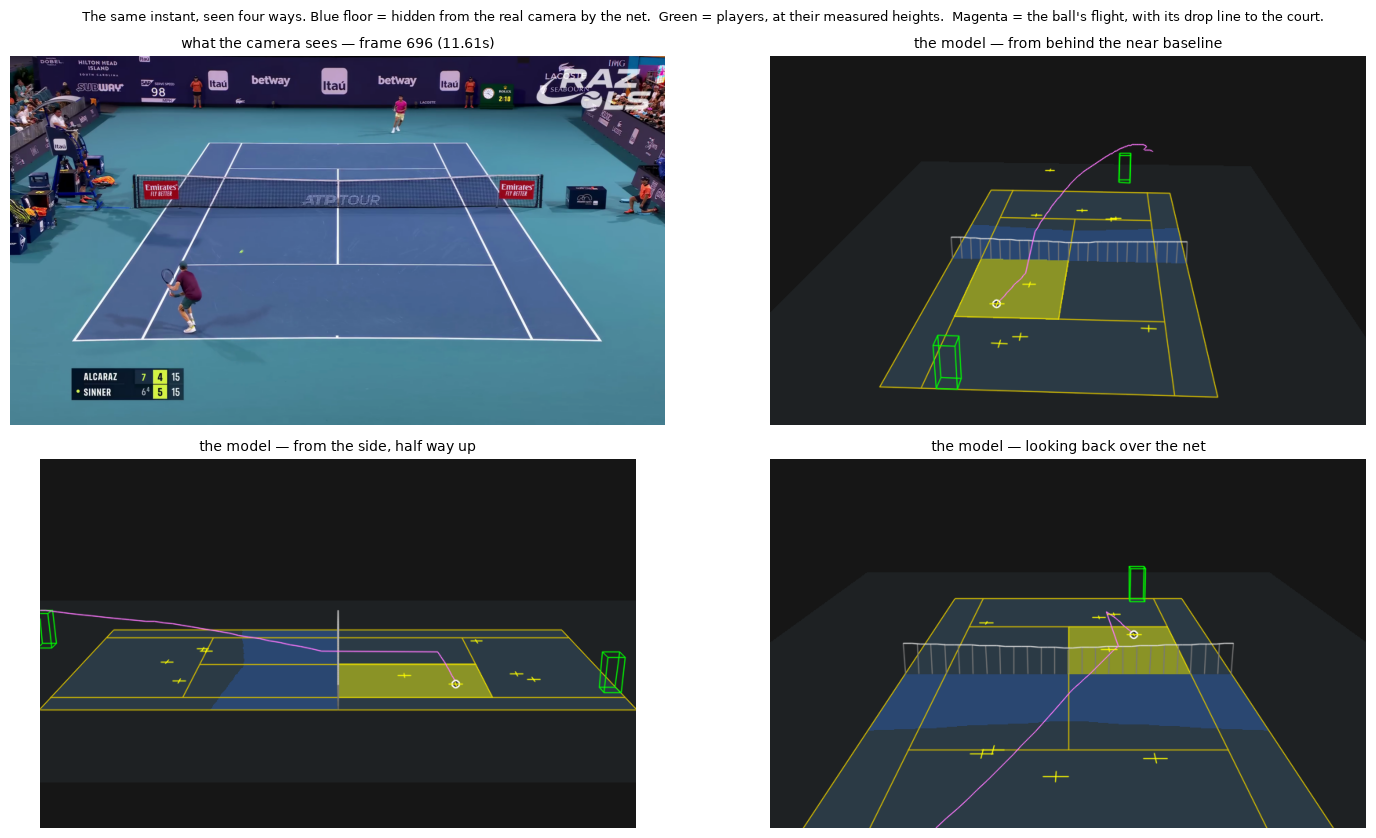

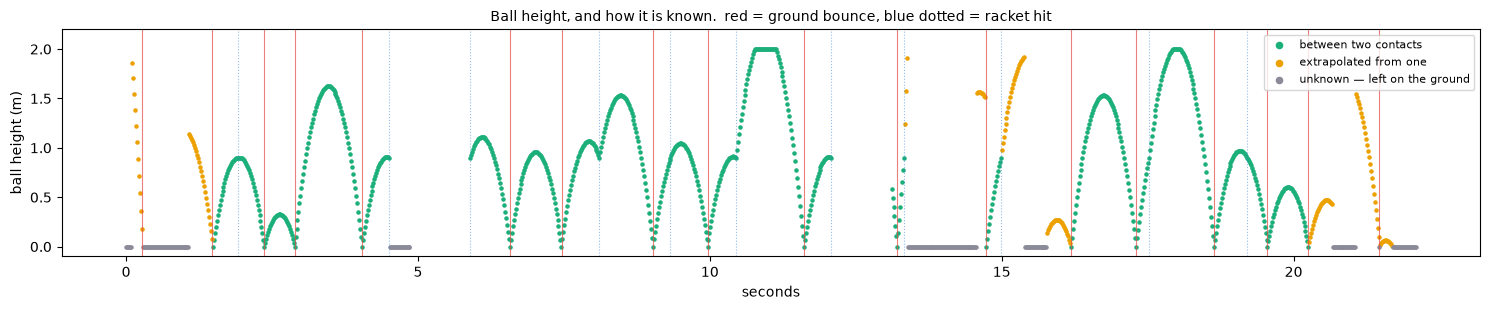

bounce-by-bounce, with the independent 3D check:
   t=  0.28s  observed  Far Backcourt           arcs agree to  0.20m, vertical speed -12.00 ->  -1.65 m/s (no reversal)
   t=  1.48s  observed  Near-Left Service Box   arcs agree to  3.96m, vertical speed  -3.03 -> +23.84 m/s (turns the ball round)
   t=  2.37s  observed  Far Backcourt           arcs agree to  0.42m, vertical speed  -6.71 -> +22.24 m/s (turns the ball round)
   t=  2.89s  observed  Out                     arcs agree to  5.35m, vertical speed -13.63 ->  +8.67 m/s (turns the ball round)
   t=  4.04s  observed  Near Backcourt          arcs agree to  0.17m, vertical speed  -6.36 ->  +7.50 m/s (turns the ball round)
   t=  6.57s  observed  Near Backcourt          arcs agree to  0.28m, vertical speed  -7.80 -> +16.14 m/s (turns the ball round)
   t=  7.46s  observed  Far Backcourt           arcs agree to  0.34m, vertical speed  -3.69 ->  -0.95 m/s (no reversal)
   t=  9.03s  observed  Near Backcourt          arcs agree to  0.4

In [16]:
# ── Looking at the 3D model ──────────────────────────────────────────────────
# The video is unchanged by any of this. What the 3D model buys is the ability to inspect
# what the pipeline believes, from viewpoints the broadcast camera does not have — most
# usefully from above and behind the far baseline, looking back over the net at the strip
# of court the real camera cannot see.
def _grab(idx):
    cap = cv2.VideoCapture(str(CLIP_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read()
    cap.release()
    return fr if ok else np.zeros((H, W, 3), np.uint8)


VIEWS = {
    "from behind the near baseline": (np.array([DW / 2 + 2.0, -22.0, 13.0]),
                                      np.array([DW / 2, DL / 2, 1.0])),
    "from the side, half way up":    (np.array([DW / 2 - 34.0, DL / 2, 12.0]),
                                      np.array([DW / 2, DL / 2, 1.0])),
    "looking back over the net":     (np.array([DW / 2, DL + 13.0, 8.0]),
                                      np.array([DW / 2, NET_Y - 2.0, 0.5])),
}

demo_frame = bounces[len(bounces) // 2]["frame"] if bounces else N_FRAMES // 2
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
axes[0, 0].imshow(cv2.cvtColor(_grab(demo_frame), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"what the camera sees — frame {demo_frame} "
                     f"({demo_frame / FPS:.2f}s)", fontsize=10)
for ax, (name, (eye, tgt)) in zip(axes.ravel()[1:], VIEWS.items()):
    ax.imshow(cv2.cvtColor(render_scene(demo_frame, eye=eye, target=tgt), cv2.COLOR_BGR2RGB))
    ax.set_title(f"the model — {name}", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("The same instant, seen four ways. Blue floor = hidden from the real camera "
             "by the net.  Green = players, at their measured heights.  "
             "Magenta = the ball's flight, with its drop line to the court.", fontsize=9)
fig.tight_layout()
plt.show()

# How well the ball's height is known, over the whole clip. The anchors are the contacts:
# between two of them gravity does the work, just past one the arc is fitted to the picture
# and run outwards, and beyond that the honest answer is that we do not know.
fig, ax = plt.subplots(figsize=(15, 3.2))
t = np.arange(N_FRAMES) / FPS
style = {"anchored": ("#1baf7a", "between two contacts"),
         "extrapolated": ("#eda100", "extrapolated from one"),
         "unknown": ("#8a8a99", "unknown — left on the ground")}
for key, (colour, label) in style.items():
    sel = np.array([m["ball_px"] is not None and m["ball_z_conf"] == key for m in frames_meta])
    ax.scatter(t[sel], np.array([m["ball_z"] for m in frames_meta])[sel], s=5, c=colour, label=label)
for b in bounces:
    ax.axvline(b["time_s"], color="#e34948", lw=0.8, alpha=0.7)
for e in events:
    if e["kind"] == "hit":
        ax.axvline(e["frame"] / FPS, color="#2a78d6", lw=0.8, alpha=0.5, ls=":")
ax.set_xlabel("seconds"); ax.set_ylabel("ball height (m)")
ax.set_title("Ball height, and how it is known.  red = ground bounce, blue dotted = racket hit",
             fontsize=10)
ax.legend(loc="upper right", fontsize=8, markerscale=2)
ax.set_ylim(-0.1, MAX_BALL_HEIGHT + 0.2)
fig.tight_layout()
plt.show()

# The independent 3D check on each flash. Two arcs are fitted, one from the frames before
# the contact and one from the frames after, both anchored at ground level on the contact
# frame. They are separate evidence: a real bounce makes them put the contact in the same
# place AND turns the ball round, coming in downwards and leaving upwards.
if bounces:
    print("bounce-by-bounce, with the independent 3D check:")
    for b in bounces:
        arc = b.get("arc")
        if not arc:
            check = "too few detections either side to fit an arc"
        else:
            check = (f"arcs agree to {arc['disagree']:5.2f}m, "
                     f"vertical speed {arc['v_in']:+6.2f} -> {arc['v_out']:+6.2f} m/s "
                     f"({'turns the ball round' if arc['reverses'] else 'no reversal'})")
        print(f"   t={b['time_s']:6.2f}s  {b['source']:8s}  {b['zone']:<22s}  {check}")


In [17]:
# ── Exporting the scene, so it can be explored outside the notebook ──────────
# The 3D model is more useful when you can turn it round yourself. This writes the whole
# rally — every frame's ball with its height and how well that height is known, both
# players, the contacts and the band of court the net hides — as a single JSON file that a
# self-contained page can render. Nothing here is new information; it is the same world
# model, in a form something else can read.
SCENE_JSON = OUTPUT_DIR / "scene3d.json"

r2 = lambda v: None if v is None else round(float(v), 2)
scene = {
    "court": {"width": DW, "length": DL, "singles_inset": SI, "service": SD,
              "net_y": NET_Y, "net_centre": NET_H_CENTRE, "net_post": NET_H_POST},
    "fps": FPS, "n_frames": N_FRAMES,
    "camera": {"x": r2(CAM_XY[0]) if CAM_XY is not None else None,
               "y": r2(CAM_XY[1]) if CAM_XY is not None else None, "z": r2(CAM_Z)},
    "zones": {k: [r2(v) for v in box] for k, box in ACTIVE_ZONES.items()},
    "occluded": [[r2(x), r2(y)] for x, y in
                 (occluded_floor_polygon(CAM_XY, CAM_Z)[:, :2]
                  if occluded_floor_polygon(CAM_XY, CAM_Z) is not None else [])],
    "bounces": [{"frame": b["frame"], "touchdown_frame_f": r2(b["touchdown_frame_f"]),
                 "decision_frame": b["decision_frame"],
                 "rally_id": b["rally_id"], "t": b["time_s"], "x": r2(b["world"][0]),
                 "y": r2(b["world"][1]), "zone": b["zone"], "source": b["source"],
                 "touchdown_quality": b.get("touchdown_quality"),
                 "track_id": b.get("track_id"), "track_confidence": r2(b.get("track_confidence")),
                 "evidence": b.get("evidence", "motion+court+player"),
                 "bounce_number": b.get("bounce_number", 1),
                 "outcome": b.get("outcome", "in_play"),
                 "sequence_p": r2(b.get("sequence_p")),
                 "impulse_score": r2(b.get("impulse_score")),
                 "rule_status": b.get("rule_status", "not_audited"),
                 "landing_confidence": r2(b.get("landing_confidence")),
                 "landing_uncertainty_px": r2(b.get("landing_uncertainty_px")),
                 "landing_support": b.get("landing_support")}
                for b in bounces],
    "hits": [{"frame": e["frame"], "t": round(e["frame"] / FPS, 2),
              "contact_confidence": r2((e.get("contact_hypothesis") or {}).get("confidence")),
              "contact_evidence": list((e.get("contact_hypothesis") or {}).get("evidence", ())) }
             for e in events if e["kind"] == "hit"],
    "frames": [{"b": ([r2(m["world"][0]), r2(m["world"][1]), r2(m["ball_z"])]
                      if m["world"] is not None else None),
                "c": {"anchored": 2, "extrapolated": 1}.get(m["ball_z_conf"], 0),
                "s": m.get("ball_state", "unacquired"),
                "k": m.get("ball_track_id"), "u": r2(m.get("ball_uncertainty_px")),
                "v": r2(m.get("ball_confidence", 0.0)),
                "r": r2(m.get("ball_search_radius_px")),
                "sp": r2(m.get("ball_estimated_speed_px_frame")),
                "sc": ([r2(x) for x in m["ball_search_centre_px"]]
                       if m.get("ball_search_centre_px") is not None else None),
                "ax": ([r2(x) for x in m["ball_search_axes_px"]]
                       if m.get("ball_search_axes_px") is not None else None),
                "mo": m.get("ball_motion_mode"),
                "e": m.get("ball_terminal_reason"),
                "q": r2(sequence_bounce_p[i]) if np.isfinite(sequence_bounce_p[i]) else None,
                "p": [[r2(p["xy"][0]), r2(p["xy"][1]),
                       r2(p["h_m"]) if np.isfinite(p["h_m"]) else 1.8]
                      for p in m.get("players_world", ())]}
               for i, m in enumerate(frames_meta)],
}
SCENE_JSON.write_text(json.dumps(scene, separators=(",", ":")))
print(f"scene exported: {SCENE_JSON}  ({SCENE_JSON.stat().st_size / 1024:.0f} KB, "
      f"{N_FRAMES} frames, {len(scene['bounces'])} bounces)")


scene exported: /Users/vahehambardzumyan/Desktop/cv_project/data/outputs/scene3d.json  (93 KB, 1325 frames, 18 bounces)


### Turn it round yourself

The 3D model, live and interactive, without leaving the notebook.


In [18]:
# ── The 3D model, live in this notebook ──────────────────────────────────────
# The same scene, turnable. Everything it needs is inline — the court, the trajectory, the
# players and the band of court the net hides are all in the JSON written just above, and
# the page carries its own renderer, so this works with no network and no libraries. It is
# also written to disk, so it can be opened on its own or sent to someone.
#
# The static figures earlier in this step are the ones that survive being printed; this is
# the one for actually looking around the point.
import html as _html
from IPython.display import display

RALLY3D_PAGE = r"""<title>还原网球的真实位置</title>
<style>
  /* ---- tokens: light is the base, both dark states redefine only these ---- */
  :root {
    --bg: #e9edf3;
    --surface: #f8fafc;
    --surface-2: #dfe6ee;
    --ink: #101820;
    --ink-2: #47596b;
    --ink-3: #74869a;
    --rule: #c6d1de;
    --court: #2e5fa3;
    --apron: #17706d;
    --flash: #b98b00;
    --flash-mark: #f0bd1a;
    --ball: #b83fb8;
    --player: #1f8b4a;
    --warn: #b4552e;
    --shadow: 0 1px 2px rgba(16, 24, 32, .06), 0 8px 24px rgba(16, 24, 32, .07);
    /* the viewport is an instrument screen: it stays dark in both themes, like a monitor */
    --view-bg: #0a1118;
    --view-court: #23456f;
    --view-apron: #12222c;
    --view-line: #d8c66a;
    --view-net: #cfd8e0;
    --view-ink: #dfe7ef;
  }
  @media (prefers-color-scheme: dark) {
    :root:not([data-theme="light"]) {
      --bg: #0b1119;
      --surface: #121b25;
      --surface-2: #1a2634;
      --ink: #e6edf4;
      --ink-2: #a3b4c5;
      --ink-3: #74869a;
      --rule: #24323f;
      --court: #5b8fd0;
      --apron: #3aa5a0;
      --flash: #f0c53c;
      --flash-mark: #f5cf4d;
      --ball: #ff8cf5;
      --player: #4fd683;
      --warn: #e0805a;
      --shadow: 0 1px 2px rgba(0, 0, 0, .4), 0 10px 30px rgba(0, 0, 0, .35);
    }
  }
  :root[data-theme="dark"] {
    --bg: #0b1119;
    --surface: #121b25;
    --surface-2: #1a2634;
    --ink: #e6edf4;
    --ink-2: #a3b4c5;
    --ink-3: #74869a;
    --rule: #24323f;
    --court: #5b8fd0;
    --apron: #3aa5a0;
    --flash: #f0c53c;
    --flash-mark: #f5cf4d;
    --ball: #ff8cf5;
    --player: #4fd683;
    --warn: #e0805a;
    --shadow: 0 1px 2px rgba(0, 0, 0, .4), 0 10px 30px rgba(0, 0, 0, .35);
  }

  * { box-sizing: border-box; }

  body {
    margin: 0;
    background: var(--bg);
    color: var(--ink);
    font: 400 16px/1.6 ui-sans-serif, system-ui, -apple-system, "Segoe UI", Roboto, sans-serif;
    -webkit-font-smoothing: antialiased;
  }

  .wrap { max-width: 1180px; margin: 0 auto; padding: clamp(28px, 5vw, 60px) clamp(16px, 4vw, 32px) 72px; }

  /* ---- header ---- */
  .eyebrow {
    font: 500 11px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .16em; text-transform: uppercase; color: var(--ink-3);
    margin: 0 0 14px;
  }
  h1 {
    font: 400 clamp(30px, 5.2vw, 50px)/1.08 "Iowan Old Style", "Palatino Linotype", Palatino, "Book Antiqua", Georgia, serif;
    letter-spacing: -.012em; margin: 0 0 14px; text-wrap: balance; color: var(--ink);
  }
  .lede { margin: 0; max-width: 62ch; color: var(--ink-2); font-size: 17px; }
  .lede strong { color: var(--ink); font-weight: 600; }

  /* ---- viewport ---- */
  .stage {
    margin-top: clamp(24px, 4vw, 40px);
    display: grid; grid-template-columns: minmax(0, 1fr) 232px; gap: 14px;
  }
  @media (max-width: 820px) { .stage { grid-template-columns: minmax(0, 1fr); } }

  .screen {
    position: relative; background: var(--view-bg); border: 1px solid var(--rule);
    border-radius: 4px; overflow: hidden; box-shadow: var(--shadow);
    aspect-ratio: 16 / 10;
  }
  @media (min-width: 700px) { .screen { min-height: 340px; } }
  #view { display: block; width: 100%; height: 100%; cursor: grab; touch-action: none; }
  #view:active { cursor: grabbing; }
  #view:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: -2px; }

  .cams {
    position: absolute; left: 10px; top: 10px; display: flex; flex-wrap: wrap; gap: 5px;
  }
  .cams button {
    font: 500 11px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .04em; color: var(--view-ink); background: rgba(10, 17, 24, .74);
    border: 1px solid rgba(223, 231, 239, .22); border-radius: 3px; padding: 6px 9px;
    cursor: pointer;
  }
  .cams button:hover { border-color: rgba(223, 231, 239, .5); }
  .cams button[aria-pressed="true"] { background: var(--flash-mark); color: #16120a; border-color: transparent; }
  .cams button:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: 2px; }

  .hint {
    position: absolute; right: 10px; bottom: 8px; pointer-events: none;
    font: 400 11px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    color: rgba(223, 231, 239, .42);
  }

  /* ---- readout ---- */
  .readout {
    background: var(--surface); border: 1px solid var(--rule); border-radius: 4px;
    padding: 14px; display: flex; flex-direction: column; gap: 12px; align-content: start;
    box-shadow: var(--shadow);
  }
  @media (max-width: 820px) { .readout { display: grid; grid-template-columns: repeat(auto-fit, minmax(150px, 1fr)); } }
  .field { display: flex; flex-direction: column; gap: 3px; }
  .field dt {
    font: 500 10px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .13em; text-transform: uppercase; color: var(--ink-3); margin: 0;
  }
  .field dd {
    margin: 0; font: 400 15px/1.35 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    font-variant-numeric: tabular-nums; color: var(--ink);
  }
  .chip {
    display: inline-block; font: 500 10px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .08em; text-transform: uppercase; padding: 4px 7px; border-radius: 3px;
    border: 1px solid currentColor;
  }
  .chip.k2 { color: var(--player); }
  .chip.k1 { color: var(--flash); }
  .chip.k0 { color: var(--ink-3); }

  .jumps { border-top: 1px solid var(--rule); padding-top: 11px; display: flex; flex-direction: column; gap: 2px; }
  .jumps h3 {
    font: 500 10px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .13em; text-transform: uppercase; color: var(--ink-3); margin: 0 0 6px;
  }
  .jumps button {
    display: flex; gap: 8px; align-items: baseline; width: 100%; text-align: left; cursor: pointer;
    background: none; border: 0; border-radius: 3px; padding: 4px 6px; color: var(--ink-2);
    font: 400 12px/1.3 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
  }
  .jumps button:hover { background: var(--surface-2); color: var(--ink); }
  .jumps button[aria-current="true"] { background: var(--surface-2); color: var(--ink); box-shadow: inset 2px 0 0 var(--flash-mark); }
  .jumps button:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: -1px; }
  .jumps .t { flex: none; font-variant-numeric: tabular-nums; color: var(--ink); }
  .jumps .z { overflow: hidden; text-overflow: ellipsis; white-space: nowrap; }

  /* ---- transport ---- */
  .transport {
    margin-top: 14px; background: var(--surface); border: 1px solid var(--rule);
    border-radius: 4px; padding: 14px 16px 10px; box-shadow: var(--shadow);
  }
  .transport-row { display: flex; align-items: center; gap: 14px; flex-wrap: wrap; }
  .play {
    flex: none; width: 42px; height: 42px; border-radius: 50%; cursor: pointer;
    border: 1px solid var(--rule); background: var(--surface-2); color: var(--ink);
    display: grid; place-items: center;
  }
  .play:hover { border-color: var(--ink-3); }
  .play:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: 2px; }
  .play svg { width: 15px; height: 15px; fill: currentColor; }

  .track { position: relative; flex: 1 1 200px; min-width: 0; }
  .ticks { position: relative; height: 22px; }
  .tick { position: absolute; bottom: 0; width: 2px; border-radius: 1px; transform: translateX(-1px); }
  .tick.bounce { height: 22px; background: var(--flash-mark); }
  .tick.hit { height: 10px; background: var(--ink-3); }
  input[type="range"] {
    -webkit-appearance: none; appearance: none; width: 100%; height: 22px;
    background: transparent; margin: 0; display: block; cursor: pointer;
  }
  input[type="range"]::-webkit-slider-runnable-track { height: 4px; background: var(--surface-2); border-radius: 2px; }
  input[type="range"]::-moz-range-track { height: 4px; background: var(--surface-2); border-radius: 2px; }
  input[type="range"]::-webkit-slider-thumb {
    -webkit-appearance: none; appearance: none; width: 14px; height: 14px; border-radius: 50%;
    background: var(--ink); border: 2px solid var(--surface); margin-top: -5px;
  }
  input[type="range"]::-moz-range-thumb {
    width: 14px; height: 14px; border-radius: 50%; background: var(--ink);
    border: 2px solid var(--surface);
  }
  input[type="range"]:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: 3px; border-radius: 3px; }
  .clock {
    flex: none; font: 400 14px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    font-variant-numeric: tabular-nums; color: var(--ink-2);
  }
  .toggles { display: flex; flex-wrap: wrap; gap: 16px; margin-top: 12px; padding-top: 10px; border-top: 1px solid var(--rule); }
  .toggles label {
    display: flex; align-items: center; gap: 7px; cursor: pointer;
    font: 400 12px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    color: var(--ink-2);
  }
  .toggles input { accent-color: var(--court); width: 14px; height: 14px; }
  .toggles input:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: 2px; }

  /* ---- legend + figures ---- */
  .grid { display: grid; gap: 12px; margin-top: 32px; grid-template-columns: repeat(auto-fit, minmax(190px, 1fr)); }
  .card {
    background: var(--surface); border: 1px solid var(--rule); border-radius: 4px; padding: 14px 16px;
  }
  .card .n {
    font: 400 26px/1.1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    font-variant-numeric: tabular-nums; color: var(--ink); display: block;
  }
  .card .k {
    font: 500 10px/1.4 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
    letter-spacing: .13em; text-transform: uppercase; color: var(--ink-3); display: block; margin-top: 6px;
  }
  .card p { margin: 8px 0 0; font-size: 13px; line-height: 1.5; color: var(--ink-2); }

  .key { display: flex; flex-wrap: wrap; gap: 8px 22px; margin-top: 24px; }
  .key span { display: flex; align-items: center; gap: 8px; font: 400 13px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace; color: var(--ink-2); }
  .sw { width: 14px; height: 14px; border-radius: 3px; flex: none; }

  h2 {
    font: 400 22px/1.25 "Iowan Old Style", "Palatino Linotype", Palatino, "Book Antiqua", Georgia, serif;
    margin: 44px 0 10px; color: var(--ink);
  }
  .prose { max-width: 68ch; color: var(--ink-2); }
  .prose p { margin: 0 0 14px; }
  .prose strong { color: var(--ink); font-weight: 600; }
  .foot { margin-top: 40px; padding-top: 18px; border-top: 1px solid var(--rule); font-size: 13px; color: var(--ink-3); }

  @media (prefers-reduced-motion: reduce) { * { animation: none !important; transition: none !important; } }
</style>

<div class="wrap">
  <p class="eyebrow">网球视觉 · 三维场景还原</p>
  <h1>还原网球的真实位置</h1>
  <p class="lede">系统通过<strong>单个固定机位</strong>，把本回合还原到真实球场坐标中。
    拖动可以旋转视角，滑动进度条可以查看回合过程。画面中的每个位置都来自同一套分析结果；
    无法可靠判断的位置，系统也会明确标出。</p>

  <div class="stage">
    <div class="screen">
      <canvas id="view" tabindex="0" aria-label="球场、球员与网球的三维视图；拖动旋转，滚轮缩放。"></canvas>
      <div class="cams" id="cams"></div>
      <p class="hint">拖动旋转 · 滚轮缩放</p>
    </div>
    <dl class="readout" id="readout">
      <div class="field"><dt>时间</dt><dd id="r-time">0.00 秒</dd></div>
      <div class="field"><dt>网球场地坐标</dt><dd id="r-ball">—</dd></div>
      <div class="field"><dt>离地高度</dt><dd id="r-height">—</dd></div>
      <div class="field"><dt>高度判断依据</dt><dd><span class="chip k0" id="r-conf">—</span></dd></div>
      <div class="field"><dt>当前高亮区域</dt><dd id="r-zone">—</dd></div>
      <div class="field"><dt>已定位球员</dt><dd id="r-players">—</dd></div>
      <div class="jumps"><h3>跳转到落点</h3><div id="jumps"></div></div>
    </dl>
  </div>

  <div class="transport">
    <div class="transport-row">
      <button class="play" id="play" aria-label="播放"><svg id="play-icon" viewBox="0 0 16 16"><path d="M3 1.5v13l11-6.5z"/></svg></button>
      <div class="track">
        <div class="ticks" id="ticks"></div>
        <input type="range" id="scrub" min="0" max="100" value="0" step="1" aria-label="查看回合进度">
      </div>
      <span class="clock" id="clock">0.00 / 0.00 秒</span>
    </div>
    <div class="toggles">
      <label><input type="checkbox" id="t-occ" checked> 球网遮挡区域</label>
      <label><input type="checkbox" id="t-trail" checked> 网球轨迹</label>
      <label><input type="checkbox" id="t-players" checked> 球员</label>
      <label><input type="checkbox" id="t-marks" checked> 落点标记</label>
    </div>
  </div>

  <div class="key">
    <span><i class="sw" style="background:var(--ball)"></i> 网球</span>
    <span><i class="sw" style="background:var(--player)"></i> 球员</span>
    <span><i class="sw" style="background:var(--flash-mark)"></i> 落地高亮区域</span>
    <span><i class="sw" style="background:var(--warn)"></i> 球网遮挡区域</span>
  </div>

  <div class="grid" id="figures"></div>

  <h2>怎样理解网球高度</h2>
  <div class="prose">
    <p>球场是平面，因此脚踩地面的球员可以准确定位。网球则不同：当球悬在空中时，
      如果直接投影到地面，得到的位置可能与真实位置相差数米，这是低机位透视造成的。</p>
    <p>单个机位不能直接测出高度，因此系统结合落地、击球和重力规律还原飞行弧线。
      当依据不足时，球会显示为空心并投影到场地；这个点只代表方向，不代表确定位置。</p>
    <p>远端球场上的阴影带表示球网遮挡区域。远端发球区较难判断主要来自视线遮挡，
      系统会结合前后轨迹作出判断，不依赖单帧猜测。</p>
  </div>

  <p class="foot">本场景由比赛分析结果生成。坐标采用标准网球场尺寸：
    横向宽度 10.97 米，纵向长度 23.77 米，原点位于近端左角。</p>
</div>

<script type="application/json" id="scene-data">__SCENE__</script>
<script>
(() => {
  "use strict";
  const S = JSON.parse(document.getElementById("scene-data").textContent);
  const C = S.court;
  const DW = C.width, DL = C.length, SI = C.singles_inset, SD = C.service, NET_Y = C.net_y;
  const SX0 = SI, SX1 = DW - SI, CX = DW / 2, NEAR_SL = NET_Y - SD, FAR_SL = NET_Y + SD;
  const N = S.n_frames, FPS = S.fps, DUR = N / FPS;
  const ZONE_NAMES = {
    "Near-Left Service Box": "近端左发球区", "Near-Right Service Box": "近端右发球区",
    "Far-Left Service Box": "远端左发球区", "Far-Right Service Box": "远端右发球区",
    "Near Backcourt": "近端后场", "Far Backcourt": "远端后场", "Out": "界外"
  };
  const zoneName = name => ZONE_NAMES[name] || name;

  const COURT_LINES = [
    [[0, 0], [DW, 0]], [[0, DL], [DW, DL]], [[0, 0], [0, DL]], [[DW, 0], [DW, DL]],
    [[SX0, 0], [SX0, DL]], [[SX1, 0], [SX1, DL]],
    [[SX0, NEAR_SL], [SX1, NEAR_SL]], [[SX0, FAR_SL], [SX1, FAR_SL]],
    [[CX, NEAR_SL], [CX, FAR_SL]],
  ];

  // ---------- small vector helpers ----------
  const sub = (a, b) => [a[0] - b[0], a[1] - b[1], a[2] - b[2]];
  const dot = (a, b) => a[0] * b[0] + a[1] * b[1] + a[2] * b[2];
  const cross = (a, b) => [a[1] * b[2] - a[2] * b[1], a[2] * b[0] - a[0] * b[2], a[0] * b[1] - a[1] * b[0]];
  const unit = a => { const m = Math.hypot(a[0], a[1], a[2]) || 1; return [a[0] / m, a[1] / m, a[2] / m]; };

  const TARGET = [DW / 2, DL / 2, 0.9];
  // azimuth 0 looks from behind the near baseline; elevation is above the court
  const PRESETS = {
    "转播视角": { az: 0, el: 0.40, r: 39 },
    "侧面视角": { az: -1.45, el: 0.30, r: 42 },
    "球网对侧": { az: Math.PI, el: 0.26, r: 30 },
    "俯视球场": { az: 0.001, el: 1.35, r: 34 },
  };
  const state = { az: PRESETS["转播视角"].az, el: PRESETS["转播视角"].el, r: PRESETS["转播视角"].r,
                  frame: 0, playing: false, preset: "转播视角" };

  function eyePoint() {
    const { az, el, r } = state;
    return [TARGET[0] + r * Math.cos(el) * Math.sin(az),
            TARGET[1] - r * Math.cos(el) * Math.cos(az),
            TARGET[2] + r * Math.sin(el)];
  }

  function projector(w, h) {
    const eye = eyePoint();
    const f = unit(sub(TARGET, eye));
    const rgt = unit(cross(f, [0, 0, 1]));
    const dn = cross(f, rgt);
    const F = (Math.min(w, h * 1.6) / 2) / Math.tan(41 * Math.PI / 360);
    const p = pt => {
      const v = sub(pt, eye);
      const z = dot(v, f);
      return [w / 2 + F * dot(v, rgt) / z, h / 2 + F * dot(v, dn) / z, z];
    };
    p.eye = eye;
    return p;
  }

  // ---------- canvas ----------
  const cv = document.getElementById("view");
  const ctx = cv.getContext("2d");
  let W = 0, H = 0;

  function resize() {
    const dpr = Math.min(window.devicePixelRatio || 1, 2);
    const rect = cv.getBoundingClientRect();
    W = Math.max(1, Math.round(rect.width));
    H = Math.max(1, Math.round(rect.height));
    cv.width = W * dpr; cv.height = H * dpr;
    ctx.setTransform(dpr, 0, 0, dpr, 0, 0);
    draw();
  }

  const NEAR = 0.08;
  function seg(p, a, b, colour, width) {
    let pa = p(a), pb = p(b);
    if (pa[2] < NEAR && pb[2] < NEAR) return;
    if (pa[2] < NEAR || pb[2] < NEAR) {
      const t = (NEAR - pa[2]) / (pb[2] - pa[2]);
      const mid = [a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]), a[2] + t * (b[2] - a[2])];
      if (pa[2] < NEAR) { a = mid; pa = p(a); } else { b = mid; pb = p(b); }
    }
    ctx.strokeStyle = colour; ctx.lineWidth = width || 1;
    ctx.beginPath(); ctx.moveTo(pa[0], pa[1]); ctx.lineTo(pb[0], pb[1]); ctx.stroke();
  }

  function facePath(p, pts) {
    let ok = true;
    ctx.beginPath();
    pts.forEach((q, i) => {
      const s = p(q);
      if (s[2] < NEAR) ok = false;
      i ? ctx.lineTo(s[0], s[1]) : ctx.moveTo(s[0], s[1]);
    });
    ctx.closePath();
    return ok;
  }

  function fill(p, pts, colour, alpha) {
    if (!facePath(p, pts)) return;
    ctx.save(); ctx.globalAlpha = alpha == null ? 1 : alpha;
    ctx.fillStyle = colour; ctx.fill(); ctx.restore();
  }

  // Hatching, not a flat colour: "no information here" should read as absence rather than
  // as another painted area of court.
  function hatch(p, pts, colour) {
    if (!facePath(p, pts)) return;
    ctx.save(); ctx.clip();
    ctx.strokeStyle = colour; ctx.lineWidth = 1; ctx.globalAlpha = 0.75;
    ctx.beginPath();
    for (let x = -H; x < W + H; x += 7) { ctx.moveTo(x, 0); ctx.lineTo(x + H, H); }
    ctx.stroke(); ctx.restore();
  }

  const css = k => getComputedStyle(document.documentElement).getPropertyValue(k).trim();

  function draw() {
    if (!W) return;
    const p = projector(W, H);
    const fr = S.frames[state.frame] || { b: null, c: 0, p: [] };
    ctx.fillStyle = css("--view-bg"); ctx.fillRect(0, 0, W, H);

    const z0 = v => [v[0], v[1], 0];
    // run-off first, so a player standing behind a baseline has ground beneath them
    fill(p, [[-7, -8, 0], [DW + 7, -8, 0], [DW + 7, DL + 8, 0], [-7, DL + 8, 0]], css("--view-apron"), 1);
    fill(p, [[0, 0, 0], [DW, 0, 0], [DW, DL, 0], [0, DL, 0]], css("--view-court"), 1);

    if (document.getElementById("t-occ").checked && S.occluded.length) {
      hatch(p, S.occluded.map(q => [q[0], q[1], 0.004]), css("--warn"));
    }

    const lit = litZone(state.frame);
    if (lit) {
      const zone = S.zones[lit.zone];
      if (zone) {
        const [x0, y0, x1, y1] = zone;
        ctx.save(); ctx.globalAlpha = 0.34 * lit.strength;
        fill(p, [[x0, y0, 0.008], [x1, y0, 0.008], [x1, y1, 0.008], [x0, y1, 0.008]], css("--flash-mark"), 1);
        ctx.restore();
      }
    }

    ctx.lineCap = "round";
    COURT_LINES.forEach(([a, b]) => seg(p, z0(a), z0(b), css("--view-line"), 1.4));

    if (document.getElementById("t-marks").checked) {
      S.bounces.forEach(b => {
        if ((b.decision_frame || b.frame) > state.frame) return;
        const c = css("--flash-mark");
        seg(p, [b.x - 0.35, b.y, 0.01], [b.x + 0.35, b.y, 0.01], c, 1.6);
        seg(p, [b.x, b.y - 0.35, 0.01], [b.x, b.y + 0.35, 0.01], c, 1.6);
      });
    }

    // the net, with its real sag — the object that hides the far court
    const netH = x => C.net_centre + (C.net_post - C.net_centre) * Math.min(1, Math.abs(x - DW / 2) / (DW / 2));
    const nc = css("--view-net");
    ctx.save(); ctx.globalAlpha = 0.42;
    for (let i = 0; i <= 26; i++) { const x = (i / 26) * DW; seg(p, [x, NET_Y, 0], [x, NET_Y, netH(x)], nc, 1); }
    ctx.restore();
    let prev = null;
    for (let i = 0; i <= 40; i++) {
      const x = (i / 40) * DW, cur = [x, NET_Y, netH(x)];
      if (prev) seg(p, prev, cur, nc, 1.4);
      prev = cur;
    }

    if (document.getElementById("t-players").checked) {
      const pc = css("--player");
      fr.p.forEach(pl => {
        const [px, py, ph] = pl, r = 0.34;
        const base = [[px - r, py - r], [px + r, py - r], [px + r, py + r], [px - r, py + r]];
        for (let i = 0; i < 4; i++) {
          const a = base[i], b = base[(i + 1) % 4];
          seg(p, [a[0], a[1], 0], [b[0], b[1], 0], pc, 1.2);
          seg(p, [a[0], a[1], ph], [b[0], b[1], ph], pc, 1.2);
          seg(p, [a[0], a[1], 0], [a[0], a[1], ph], pc, 1.2);
        }
      });
    }

    if (document.getElementById("t-trail").checked) {
      const shades = [css("--ink-3"), css("--flash"), css("--ball")];
      for (let j = Math.max(1, state.frame - 45); j <= state.frame; j++) {
        const a = S.frames[j - 1], b = S.frames[j];
        if (!a || !b || !a.b || !b.b) continue;
        ctx.save();
        ctx.globalAlpha = 0.25 + 0.75 * (j - Math.max(1, state.frame - 45)) / 45;
        seg(p, a.b, b.b, shades[a.c], a.c === 0 ? 1 : 1.6);
        ctx.restore();
      }
    }

    if (fr.b) {
      const [bx, by, bz] = fr.b;
      seg(p, [bx, by, bz], [bx, by, 0], css("--ink-3"), 1);
      const sh = p([bx, by, 0]);
      if (sh[2] > NEAR) {
        ctx.save(); ctx.globalAlpha = 0.5; ctx.fillStyle = css("--view-bg");
        ctx.beginPath(); ctx.ellipse(sh[0], sh[1], 4, 2, 0, 0, 7); ctx.fill(); ctx.restore();
      }
      const s = p([bx, by, bz]);
      if (s[2] > NEAR) {
        ctx.beginPath(); ctx.arc(s[0], s[1], 5.5, 0, 7);
        if (fr.c === 0) { ctx.strokeStyle = css("--ink-3"); ctx.lineWidth = 1.5; ctx.stroke(); }
        else { ctx.fillStyle = css("--ball"); ctx.fill(); }
      }
    }
  }

  // ---------- the flash, mirroring the video's timing ----------
  const FLASH_FRAMES = Math.round(0.88 * FPS), FLASH_HOLD = Math.round(0.28 * FPS);
  function litZone(f) {
    for (let i = S.bounces.length - 1; i >= 0; i--) {
      const b = S.bounces[i];
      const k = f - (b.decision_frame || b.frame);
      if (k < 0 || k >= FLASH_FRAMES) continue;
      const strength = k < FLASH_HOLD ? 1 : 1 - (k - FLASH_HOLD) / (FLASH_FRAMES - FLASH_HOLD);
      return { zone: b.zone, strength, bounce: b };
    }
    return null;
  }

  // ---------- readout ----------
  const CONF = ["暂不可知", "根据一次接触外推", "由两次接触确定"];
  const el = id => document.getElementById(id);
  function readout() {
    const fr = S.frames[state.frame] || { b: null, c: 0, p: [] };
    el("r-time").textContent = (state.frame / FPS).toFixed(2) + " 秒   ·   第 " + state.frame + " 帧";
    el("r-ball").textContent = fr.b ? `横向 ${fr.b[0].toFixed(2)}   纵向 ${fr.b[1].toFixed(2)}` : "未追踪到";
    el("r-height").textContent = fr.b ? fr.b[2].toFixed(2) + " 米" : "—";
    const chip = el("r-conf");
    chip.textContent = fr.b ? CONF[fr.c] : "未追踪到球";
    chip.className = "chip k" + (fr.b ? fr.c : 0);
    const lit = litZone(state.frame);
    el("r-zone").textContent = lit ? zoneName(lit.zone) : "—";
    el("r-players").textContent = fr.p.length + " 名球员";
    el("clock").textContent = (state.frame / FPS).toFixed(2) + " / " + DUR.toFixed(2) + " 秒";
    const sc = el("scrub");
    if (+sc.value !== state.frame) sc.value = state.frame;
    if (typeof markJump === "function") markJump();
  }

  function setFrame(f) {
    state.frame = Math.max(0, Math.min(N - 1, Math.round(f)));
    draw(); readout();
  }

  // ---------- controls ----------
  const cams = el("cams");
  Object.keys(PRESETS).forEach(name => {
    const b = document.createElement("button");
    b.textContent = name; b.type = "button";
    b.setAttribute("aria-pressed", String(name === state.preset));
    b.addEventListener("click", () => {
      Object.assign(state, PRESETS[name], { preset: name });
      [...cams.children].forEach(c => c.setAttribute("aria-pressed", String(c === b)));
      draw();
    });
    cams.appendChild(b);
  });

  let drag = null;
  cv.addEventListener("pointerdown", e => {
    drag = { x: e.clientX, y: e.clientY }; cv.setPointerCapture(e.pointerId);
  });
  cv.addEventListener("pointermove", e => {
    if (!drag) return;
    state.az -= (e.clientX - drag.x) * 0.006;
    state.el = Math.max(0.06, Math.min(1.5, state.el + (e.clientY - drag.y) * 0.005));
    drag = { x: e.clientX, y: e.clientY };
    [...cams.children].forEach(c => c.setAttribute("aria-pressed", "false"));
    draw();
  });
  const endDrag = () => { drag = null; };
  cv.addEventListener("pointerup", endDrag);
  cv.addEventListener("pointercancel", endDrag);
  cv.addEventListener("wheel", e => {
    e.preventDefault();
    state.r = Math.max(12, Math.min(90, state.r * (1 + Math.sign(e.deltaY) * 0.08)));
    draw();
  }, { passive: false });

  cv.addEventListener("keydown", e => {
    const step = e.shiftKey ? 10 : 1;
    if (e.key === "ArrowLeft") { setFrame(state.frame - step); e.preventDefault(); }
    else if (e.key === "ArrowRight") { setFrame(state.frame + step); e.preventDefault(); }
    else if (e.key === " ") { toggle(); e.preventDefault(); }
  });

  el("scrub").max = N - 1;
  el("scrub").addEventListener("input", e => { pause(); setFrame(+e.target.value); });
  ["t-occ", "t-trail", "t-players", "t-marks"].forEach(id => el(id).addEventListener("change", draw));

  const PLAY_ICON = "M3 1.5v13l11-6.5z", PAUSE_ICON = "M3 1.5h4v13H3zM9 1.5h4v13H9z";
  let raf = null, last = 0;
  function tick(ts) {
    if (!state.playing) return;
    if (!last) last = ts;
    const advance = Math.round((ts - last) * FPS / 1000);
    if (advance > 0) {
      last = ts;
      setFrame(state.frame + advance >= N ? 0 : state.frame + advance);
    }
    raf = requestAnimationFrame(tick);
  }
  function play() {
    state.playing = true; last = 0;
    el("play-icon").firstElementChild.setAttribute("d", PAUSE_ICON);
    el("play").setAttribute("aria-label", "暂停");
    raf = requestAnimationFrame(tick);
  }
  function pause() {
    state.playing = false;
    if (raf) cancelAnimationFrame(raf);
    el("play-icon").firstElementChild.setAttribute("d", PLAY_ICON);
    el("play").setAttribute("aria-label", "播放");
  }
  const toggle = () => (state.playing ? pause() : play());
  el("play").addEventListener("click", toggle);

  // ---------- ticks and figures, computed from the data ----------
  const ticks = el("ticks");
  S.hits.forEach(h => {
    const d = document.createElement("i");
    d.className = "tick hit"; d.style.left = (100 * h.frame / (N - 1)) + "%";
    d.title = "击球 · " + h.t.toFixed(2) + " 秒";
    ticks.appendChild(d);
  });
  S.bounces.forEach(b => {
    const d = document.createElement("i");
    d.className = "tick bounce"; d.style.left = (100 * b.frame / (N - 1)) + "%";
    d.title = zoneName(b.zone) + " · " + b.t.toFixed(2) + " 秒";
    ticks.appendChild(d);
  });

  const tracked = S.frames.filter(f => f.b).length;
  const known = S.frames.filter(f => f.b && f.c > 0).length;
  const figs = [
    [S.bounces.length, "已确认落点", "每个落点均由地面运动变化确认，并同步高亮对应区域。"],
    [Math.round(100 * tracked / N) + "%", "画面中追踪到球", `${N} 帧中有 ${tracked} 帧追踪到球；其余多数发生在球员挥拍遮挡期间。`],
    [Math.round(100 * known / tracked) + "%", "已还原飞行高度", `${known} 帧距离可靠接触点足够近，可结合重力规律还原三维高度。`],
    [S.camera.z.toFixed(1) + " 米", "摄像机高度", `由球场几何反推：位于近端底线后 ${Math.abs(S.camera.y).toFixed(1)} 米，接近中线位置。`],
  ];
  const grid = el("figures");
  figs.forEach(([n, k, note]) => {
    const c = document.createElement("div");
    c.className = "card";
    c.innerHTML = `<span class="n"></span><span class="k"></span><p></p>`;
    c.querySelector(".n").textContent = n;
    c.querySelector(".k").textContent = k;
    c.querySelector("p").textContent = note;
    grid.appendChild(c);
  });

  // every bounce, jumpable — the fastest way to check a flash against the geometry
  const jumps = el("jumps");
  const jumpBtns = S.bounces.map(b => {
    const btn = document.createElement("button");
    btn.type = "button";
    btn.innerHTML = '<span class="t"></span><span class="z"></span>';
    btn.querySelector(".t").textContent = b.t.toFixed(2) + " 秒";
    btn.querySelector(".z").textContent = zoneName(b.zone);
    btn.addEventListener("click", () => { pause(); setFrame(b.frame); });
    jumps.appendChild(btn);
    return { btn, b };
  });
  function markJump() {
    const lit = litZone(state.frame);
    jumpBtns.forEach(({ btn, b }) => btn.setAttribute("aria-current", String(!!lit && lit.bounce === b)));
  }

  new ResizeObserver(resize).observe(cv);
  window.addEventListener("resize", resize);
  resize(); readout();
  if (!window.matchMedia("(prefers-reduced-motion: reduce)").matches) play();
})();
</script>
"""

VIEWER_HTML = OUTPUT_DIR / "rally3d.html"
_page = ("<!doctype html><html><head><meta charset=\"utf-8\">"
         "<meta name=\"viewport\" content=\"width=device-width,initial-scale=1\"></head><body>"
         + RALLY3D_PAGE.replace("__SCENE__", SCENE_JSON.read_text()) + "</body></html>")
VIEWER_HTML.write_text(_page)
print(f"interactive 3D viewer -> {VIEWER_HTML}  ({VIEWER_HTML.stat().st_size / 1024:.0f} KB, "
      f"self-contained)")
print("drag to orbit · scroll to zoom · scrub or click a bounce to jump")

# An iframe rather than raw HTML: it keeps the page's stylesheet out of the notebook's own,
# and the sandbox lets its scripts run while isolating everything else. The MIME bundle is
# published directly rather than through IPython's HTML(), which inspects the markup and
# warns whenever it finds an iframe in it.
display({"text/html":
         '<iframe srcdoc="' + _html.escape(_page, quote=True) + '" '
         'style="width:100%;height:820px;border:1px solid #444;border-radius:4px" '
         'sandbox="allow-scripts"></iframe>'}, raw=True)


interactive 3D viewer -> /Users/vahehambardzumyan/Desktop/cv_project/data/outputs/rally3d.html  (123 KB, self-contained)
drag to orbit · scroll to zoom · scrub or click a bounce to jump


<iframe srcdoc="<!doctype html><html><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"></head><body><title>Where the ball actually was</title>
<style>
 /* ---- tokens: light is the base, both dark states redefine only these ---- */
 :root {
 --bg: #e9edf3;
 --surface: #f8fafc;
 --surface-2: #dfe6ee;
 --ink: #101820;
 --ink-2: #47596b;
 --ink-3: #74869a;
 --rule: #c6d1de;
 --court: #2e5fa3;
 --apron: #17706d;
 --flash: #b98b00;
 --flash-mark: #f0bd1a;
 --ball: #b83fb8;
 --player: #1f8b4a;
 --warn: #b4552e;
 --shadow: 0 1px 2px rgba(16, 24, 32, .06), 0 8px 24px rgba(16, 24, 32, .07);
 /* the viewport is an instrument screen: it stays dark in both themes, like a monitor */
 --view-bg: #0a1118;
 --view-court: #23456f;
 --view-apron: #12222c;
 --view-line: #d8c66a;
 --view-net: #cfd8e0;
 --view-ink: #dfe7ef;
 }
 @media (prefers-color-scheme: dark) {
 :root:not([data-theme="light"]) {
 --bg: #0b1119;
 --surface: #121b25;
 --surface-2: #1a2634;
 --ink: #e6edf4;
 --ink-2: #a3b4c5;
 --ink-3: #74869a;
 --rule: #24323f;
 --court: #5b8fd0;
 --apron: #3aa5a0;
 --flash: #f0c53c;
 --flash-mark: #f5cf4d;
 --ball: #ff8cf5;
 --player: #4fd683;
 --warn: #e0805a;
 --shadow: 0 1px 2px rgba(0, 0, 0, .4), 0 10px 30px rgba(0, 0, 0, .35);
 }
 }
 :root[data-theme="dark"] {
 --bg: #0b1119;
 --surface: #121b25;
 --surface-2: #1a2634;
 --ink: #e6edf4;
 --ink-2: #a3b4c5;
 --ink-3: #74869a;
 --rule: #24323f;
 --court: #5b8fd0;
 --apron: #3aa5a0;
 --flash: #f0c53c;
 --flash-mark: #f5cf4d;
 --ball: #ff8cf5;
 --player: #4fd683;
 --warn: #e0805a;
 --shadow: 0 1px 2px rgba(0, 0, 0, .4), 0 10px 30px rgba(0, 0, 0, .35);
 }

 * { box-sizing: border-box; }

 body {
 margin: 0;
 background: var(--bg);
 color: var(--ink);
 font: 400 16px/1.6 ui-sans-serif, system-ui, -apple-system, "Segoe UI", Roboto, sans-serif;
 -webkit-font-smoothing: antialiased;
 }

 .wrap { max-width: 1180px; margin: 0 auto; padding: clamp(28px, 5vw, 60px) clamp(16px, 4vw, 32px) 72px; }

 /* ---- header ---- */
 .eyebrow {
 font: 500 11px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
 letter-spacing: .16em; text-transform: uppercase; color: var(--ink-3);
 margin: 0 0 14px;
 }
 h1 {
 font: 400 clamp(30px, 5.2vw, 50px)/1.08 "Iowan Old Style", "Palatino Linotype", Palatino, "Book Antiqua", Georgia, serif;
 letter-spacing: -.012em; margin: 0 0 14px; text-wrap: balance; color: var(--ink);
 }
 .lede { margin: 0; max-width: 62ch; color: var(--ink-2); font-size: 17px; }
 .lede strong { color: var(--ink); font-weight: 600; }

 /* ---- viewport ---- */
 .stage {
 margin-top: clamp(24px, 4vw, 40px);
 display: grid; grid-template-columns: minmax(0, 1fr) 232px; gap: 14px;
 }
 @media (max-width: 820px) { .stage { grid-template-columns: minmax(0, 1fr); } }

 .screen {
 position: relative; background: var(--view-bg); border: 1px solid var(--rule);
 border-radius: 4px; overflow: hidden; box-shadow: var(--shadow);
 aspect-ratio: 16 / 10;
 }
 @media (min-width: 700px) { .screen { min-height: 340px; } }
 #view { display: block; width: 100%; height: 100%; cursor: grab; touch-action: none; }
 #view:active { cursor: grabbing; }
 #view:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: -2px; }

 .cams {
 position: absolute; left: 10px; top: 10px; display: flex; flex-wrap: wrap; gap: 5px;
 }
 .cams button {
 font: 500 11px/1 ui-monospace, SFMono-Regular, "SF Mono", Menlo, Consolas, monospace;
 letter-spacing: .04em; color: var(--view-ink); background: rgba(10, 17, 24, .74);
 border: 1px solid rgba(223, 231, 239, .22); border-radius: 3px; padding: 6px 9px;
 cursor: pointer;
 }
 .cams button:hover { border-color: rgba(223, 231, 239, .5); }
 .cams button[aria-pressed="true"] { background: var(--flash-mark); color: #16120a; border-color: transparent; }
 .cams button:focus-visible { outline: 2px solid var(--flash-mark); outline-offset: 2px; }

 .hint {
 position: absolute; right: 10px; bottom: 8px; pointer-events: none;
 font: 400 11px/1

## Step 8 — Pass B: draw the video

Reads the frames again and draws, using only what Step 7 computed. No model runs here,
so this pass is fast.

What gets drawn, on court shots only:

- **court lines** — thin white outlines of the 8 zones
- **the tap** — when the ball touches the court, that zone **lights up in its colour**
  and fades out. Nothing else: no ring, no marker, no text.
- **the ball** and a light, blended trail
- **the minimap**, bottom-right

In [19]:
def draw_crossings(layer, corners, paint_found):
    """A dot where two painted lines meet.

    The crossings are known in metres, so they need no detection of their own — but a dot
    is only drawn where the lines around it were actually found, so a crossing hidden
    behind a player or out of frame stays unmarked, exactly like the lines."""
    pts = project_world(CROSS_WORLD, corners)
    ok = bridge_gaps(paint_found, LINE_GAP_BRIDGE)
    for (x, y), lines in zip(pts, CROSS_LINES):
        if not lines or not all(ok[li][si] for li, si in lines):
            continue
        if not (0 <= x < W and 0 <= y < H):
            continue
        cv2.circle(layer, (int(round(x)), int(round(y))), CROSS_DOT_R,
                   CROSS_DOT_BGR, -1, cv2.LINE_AA)


def bridge_gaps(found, span):
    """Close gaps of at most `span` samples in the "paint is here" mask.

    Faint or scuffed paint drops the odd sample and would otherwise dash a line that is
    plainly there — measured, the near baseline registers on 93% of its samples. Bridging
    only SHORT gaps keeps the useful behaviour: a genuinely absent stretch of court, out
    of frame or occluded, is still not drawn."""
    out = found.copy()
    for line in out:
        run = 0
        for i, ok_ in enumerate(line):
            if ok_:
                if 0 < run <= span and i - run - 1 >= 0:
                    line[i - run:i] = True
                run = 0
            else:
                run += 1
    return out


def draw_detected_lines(layer, corners, paint_found):
    """Stroke the nine court lines where paint was actually FOUND under them.

    The geometry comes from this frame's own fit, so the overlay follows the camera; the
    `paint_found` mask comes from the same frame's ridge detection, so a stretch of line
    that is occluded, out of frame or simply not there is not drawn. That is the
    difference between showing a detection and painting a template over the picture."""
    pts = project_world(DRAW_WORLD, corners).reshape(len(COURT_TEMPLATE), LINE_SAMPLES, 2)
    for line_pts, found in zip(pts, bridge_gaps(paint_found, LINE_GAP_BRIDGE)):
        run = []
        for p, ok_ in zip(line_pts, found):
            if ok_:
                run.append(p)
            else:
                if len(run) >= 4:
                    cv2.polylines(layer, [np.array(run, np.int32)], False,
                                  COURT_LINE_BGR, LINE_THICK, cv2.LINE_AA)
                run = []
        if len(run) >= 4:
            cv2.polylines(layer, [np.array(run, np.int32)], False,
                          COURT_LINE_BGR, LINE_THICK, cv2.LINE_AA)


cap = cv2.VideoCapture(str(CLIP_PATH))
encoder = subprocess.Popen(
    [FFMPEG, "-y", "-f", "rawvideo", "-pix_fmt", "bgr24", "-s", f"{W}x{H}", "-r", f"{FPS}",
     "-i", "-", "-c:v", "libx264", "-preset", "medium", "-crf", "20", "-pix_fmt", "yuv420p",
     str(OUTPUT_VIDEO)],
    stdin=subprocess.PIPE, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

trail_contact_frames = {e["frame"] for e in events if e.get("kind") in ("hit", "bounce")}
trail_contact_frames.update(i for i, m in enumerate(frames_meta)
                            if m.get("ball_terminal_reason") == "net_hit")
if TRAIL_RENDER_MODE not in ("legacy", "regularized"):
    raise ValueError(f"unknown TRAIL_RENDER_MODE: {TRAIL_RENDER_MODE}")
print(f"purple trail renderer: {TRAIL_RENDER_MODE}")
t0 = time.time()
for idx, meta in enumerate(frames_meta):
    ok, frame = cap.read()
    if not ok:
        break

    if meta["is_court"]:
        # Court graphics are drawn on their own layer first, then composited only where
        # there is no player — so a player stands IN FRONT of the lines instead of
        # having them painted across them.
        layer = frame.copy()

        # THE TAP: the zone the ball landed in lights up YELLOW and fades. Nothing else.
        flash = flash_at.get(idx)
        if flash:
            polys = zone_polygons(meta["M"])
            if flash[0] in polys:
                zone, strength = flash
                lit = layer.copy()
                cv2.fillPoly(lit, [polys[zone]], FLASH_COLOR_BGR)
                a = FLASH_PEAK_ALPHA * strength
                layer = cv2.addWeighted(lit, a, layer, 1 - a, 0)

        draw_detected_lines(layer, meta["corners"], meta["paint_found"])
        draw_crossings(layer, meta["corners"], meta["paint_found"])

        person = decode_person(meta.get("person_png"))
        if person is None:
            frame = layer
        else:
            keep = (person == 0)[:, :, None]      # players keep the original pixels
            frame = np.where(keep, layer, frame)

    # the players, boxed. Thin, green, unlabelled — and drawn from the same filtered
    # records the world model uses, so the crowd behind the baseline is never boxed.
    for p in meta.get("players_world", ()):
        bx1, by1, bx2, by2 = p["box"]
        cv2.rectangle(frame, (bx1, by1), (bx2, by2), PLAYER_BOX_BGR, PLAYER_BOX_THICK)

    # Stable display trail: historical 3D points are smoothed in court coordinates,
    # then all reprojected through THIS frame's camera. Camera motion can therefore move
    # the whole trail, but can no longer bend it into a different shape every frame.
    lo = contact_bounded_start(idx, max(0, idx - TRAIL_LEN + 1), trail_contact_frames)
    run = []
    for j in range(idx, lo - 1, -1):
        uv = display_ball_to_pixel(frames_meta[j].get("display_world3d"), meta)
        if uv is None:
            break
        run.append(uv)
    run.reverse()
    if run and meta["ball_px"] is not None:
        run[-1] = meta["ball_px"]       # detector-backed current ball remains exact
    if TRAIL_RENDER_MODE == "regularized" and len(run) >= 4:
        run = stabilize_screen_trail(
            run, strength=TRAIL_CURVATURE_STRENGTH, max_shift_px=TRAIL_MAX_SHIFT)
    if len(run) > 1:
        layer = frame.copy()
        for i in range(1, len(run)):
            age = i / max(1, len(run) - 1)
            colour = (int(150 + 105 * age), int(70 + 50 * age), 255)
            cv2.line(layer, tuple(map(int, run[i - 1])), tuple(map(int, run[i])),
                     colour, TRAIL_THICK, cv2.LINE_AA)
        frame = cv2.addWeighted(layer, TRAIL_ALPHA, frame, 1 - TRAIL_ALPHA, 0)
    if meta["ball_px"]:
        cv2.circle(frame, tuple(map(int, meta["ball_px"])), BALL_RADIUS, (255, 0, 255), -1, cv2.LINE_AA)

    if meta["is_court"]:
        active_rally = next((e["rally_id"] for e in reversed(events)
                             if "rally_id" in e and e["frame"] <= idx), None)
        draw_minimap(frame, render_minimap(
            flash=flash_at.get(idx),
            landings=[(*b["world"], b["zone"] == "Out") for b in bounces
                      if b["rally_id"] == active_rally
                      and b["decision_frame"] <= idx]))

    encoder.stdin.write(frame.tobytes())

encoder.stdin.close()
encoder.wait()
cap.release()
print(f"rendered {N_FRAMES} frames in {time.time() - t0:.0f}s (no inference in this pass)")
print(f"ground bounces: {len(bounces)}, of which {len(flash_zones)} lit a zone "
      f"(the rest landed well outside the court)   ->   {OUTPUT_VIDEO}")

rendered 1325 frames in 75s (no inference in this pass)
ground bounces: 18, of which 17 lit a zone (the rest landed well outside the court)   ->   /Users/vahehambardzumyan/Desktop/cv_project/data/outputs/annotated_clip.mp4


## Result

In [20]:
from IPython.display import Video, display
display(Video(str(OUTPUT_VIDEO), embed=False, width=900))